In [1]:
from tools_functions import *
import pickle 
import matplotlib.pyplot as plt
import datetime as dt
import sys

In [2]:
sinister = 'firepoint'
output_dataset = 'bdiff_evolution'
sinister_encoding = 'occurence'

dir_output = Path('/home/caron/Bureau/Model/HexagonalScale/ST-GNN-for-wildifre-prediction/Prediction/Target/'+sinister+'/'+output_dataset + '/' + sinister_encoding)


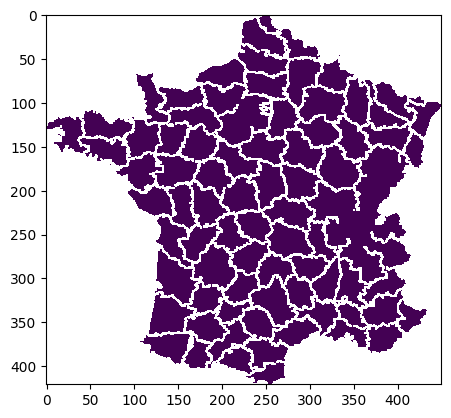

In [3]:
france = read_object('france.pkl', dir_output)
plt.imshow(france[0]) 

In [4]:
france.shape

(1, 421, 450)

In [5]:
import matplotlib.pyplot as plt

def plot_france(images, years, cmap="plasma", alpha=0.6):
    """
    Affiche les cartes raster des feux pour plusieurs années en tant qu'images brutes (sans géoréférencement).

    Parameters:
        years (list of int): Liste des années à afficher (ex: [2018, 2019])
        cmap (str): Colormap matplotlib à utiliser
        alpha (float): Transparence appliquée à chaque image superposée
    """
    plt.figure(figsize=(10, 10))

    for i, year in enumerate(years):
        try:
            # Si c'est un objet rasterio, on lit la première bande
            data = images[i]  # sinon on suppose que c'est déjà une numpy array

            plt.imshow(data, cmap=cmap, alpha=alpha)
            plt.title(f"Superposition des feux : {', '.join(map(str, years))}")
        except Exception as e:
            print(f"[!] Erreur lors du chargement de l'année {year} : {e}")

    plt.axis("off")
    plt.show()


In [6]:
images = []
years = ['2018', '2019', '2020', '2021', '2022', '2023']
for year in years:
    im = read_object(f'fire_{year}.pkl', dir_output)[0]

    images.append(im)

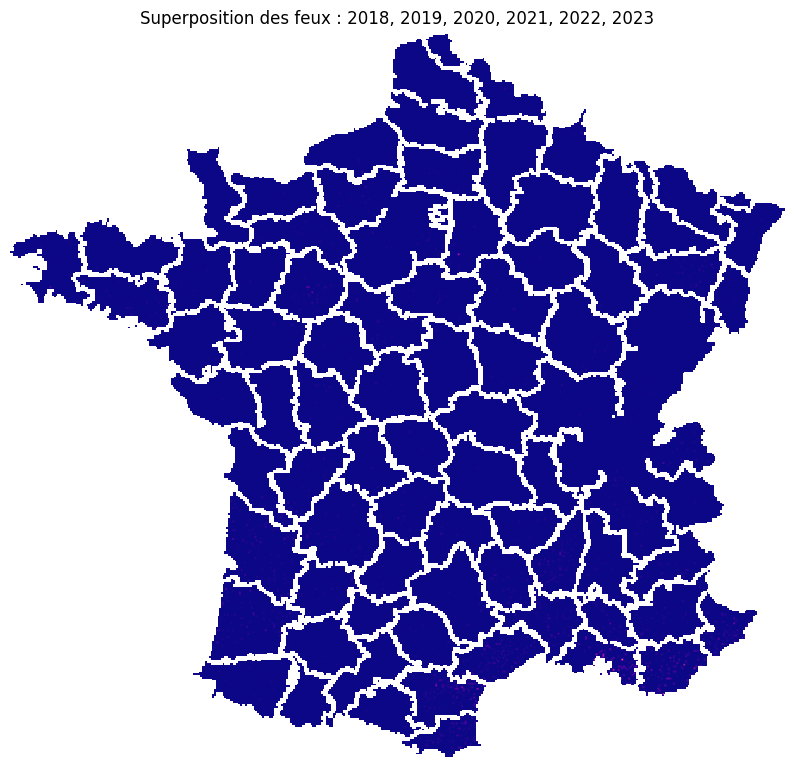

In [7]:
plot_france(images, years)

/tmp/ipykernel_8009/1749709595.py:16: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(values)


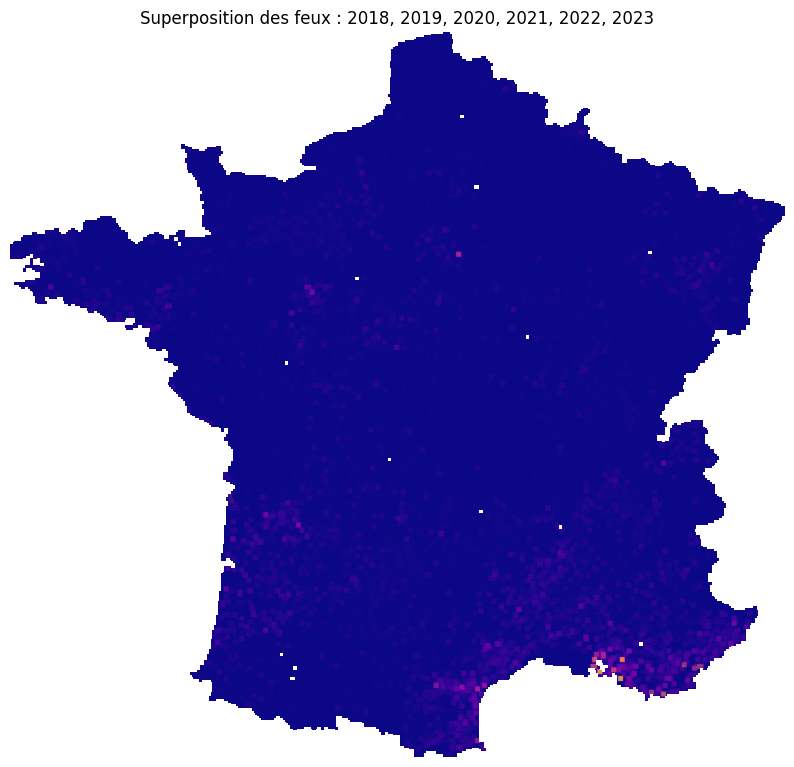

In [8]:
import numpy as np
from scipy.ndimage import generic_filter

def nanmax_pool_same_resolution(image, kernel_size=3):
    """
    Applique un max pooling sur l'image sans changer la résolution, en ignorant les NaN.
    
    Parameters:
        image (np.ndarray): Image 2D (avec potentiellement des NaN)
        kernel_size (int): Taille du noyau (doit être impair)
    
    Returns:
        np.ndarray: Image filtrée
    """
    def nanmax_func(values):
        return np.nanmax(values)

    return generic_filter(
        image,
        function=nanmax_func,
        size=kernel_size,
        mode='nearest'  # gère les bords
    )

from skimage.util import view_as_windows

def nanmax_pool_reduce(image, kernel_size=3):
    """
    Réduit la taille de l'image en appliquant un max pooling, en ignorant les NaN.
    
    Parameters:
        image (np.ndarray): Image 2D avec potentiellement des NaN.
        kernel_size (int): Taille du pooling (doit diviser image.shape exactement ou s'arrondira)
    
    Returns:
        np.ndarray: Image réduite (downsampled)
    """
    # Découpe en fenêtres
    k = kernel_size
    new_shape = (
        image.shape[0] // k,
        image.shape[1] // k
    )

    # Coupe l'image pour qu'elle soit divisible par kernel_size
    trimmed = image[:new_shape[0] * k, :new_shape[1] * k]

    # Vue glissante en blocs non chevauchants
    windows = view_as_windows(trimmed, (k, k), step=k)

    # Applique nanmax à chaque bloc
    pooled = np.nanmax(windows, axis=(2, 3))

    return pooled


images_max_3 = [nanmax_pool_same_resolution(im, kernel_size=3) for im in images]
plot_france(images_max_3, years)

In [9]:
images[0].shape, images_max_3[0].shape

((421, 450), (421, 450))

/tmp/ipykernel_8009/1749709595.py:16: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(values)


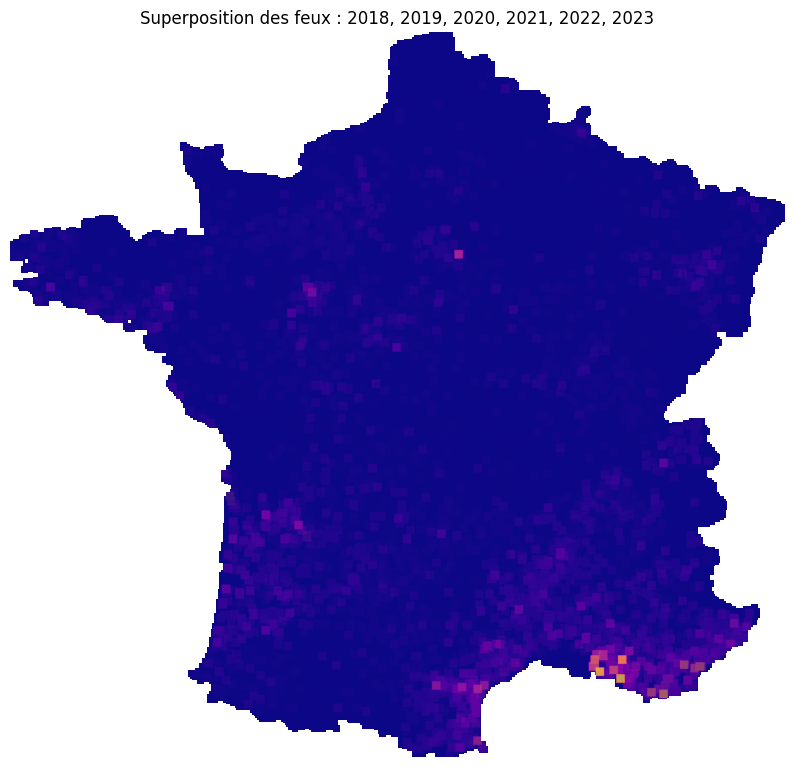

In [10]:
images_max_5 = [nanmax_pool_same_resolution(im, kernel_size=5) for im in images]
plot_france(images_max_5, years)

In [11]:
#images = [nanmax_pool_reduce(im, kernel_size=5) for im in images]
#plot_france(images, years)

In [12]:
images[0].shape, images_max_5[0].shape

((421, 450), (421, 450))

In [13]:
import matplotlib.pyplot as plt
import numpy as np

def plot_matches_on_images(image_matches_list, titles, cmap='plasma', point_color='blue', figsize=(12, 10)):
    """
    Affiche des correspondances pour une liste d'images avec une colorbar commune en dessous.
    NaN dans les images sont affichés comme transparents.

    Parameters:
        image_matches_list (list): Liste de tableaux image (np.ndarray)
        titles (list): Liste de titres pour chaque image
        point_color (str): Couleur des points (non utilisé ici)
        figsize (tuple): Taille globale de la figure
    """
    num_plots = len(image_matches_list)
    cols = int(np.ceil(np.sqrt(num_plots)))
    rows = int(np.ceil(num_plots / cols))

    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = np.array(axes).reshape(-1)

    vmin = np.nanmin([np.nanmin(img) for img in image_matches_list])
    vmax = np.nanmax([np.nanmax(img) for img in image_matches_list])

    im = None
    for idx, img in enumerate(image_matches_list):
        ax = axes[idx]
        im = ax.imshow(img, cmap=cmap, origin='upper', vmin=vmin, vmax=vmax)
        ax.set_xlim(0, img.shape[1])
        ax.set_ylim(img.shape[0], 0)
        ax.set_title(titles[idx])
        ax.set_xticks([])
        ax.set_yticks([])

    # Masquer les axes inutilisés
    for ax in axes[num_plots:]:
        ax.axis('off')

    # Ajustement du layout pour resserrer les plots
    fig.subplots_adjust(wspace=0.2, hspace=0.3, bottom=0.15)

    # Ajouter une colorbar horizontale en bas
    if im:
        cbar_ax = fig.add_axes([0.2, 0.05, 0.6, 0.02])  # [left, bottom, width, height]
        cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
        cbar.set_label("Number of fire")

    plt.show()


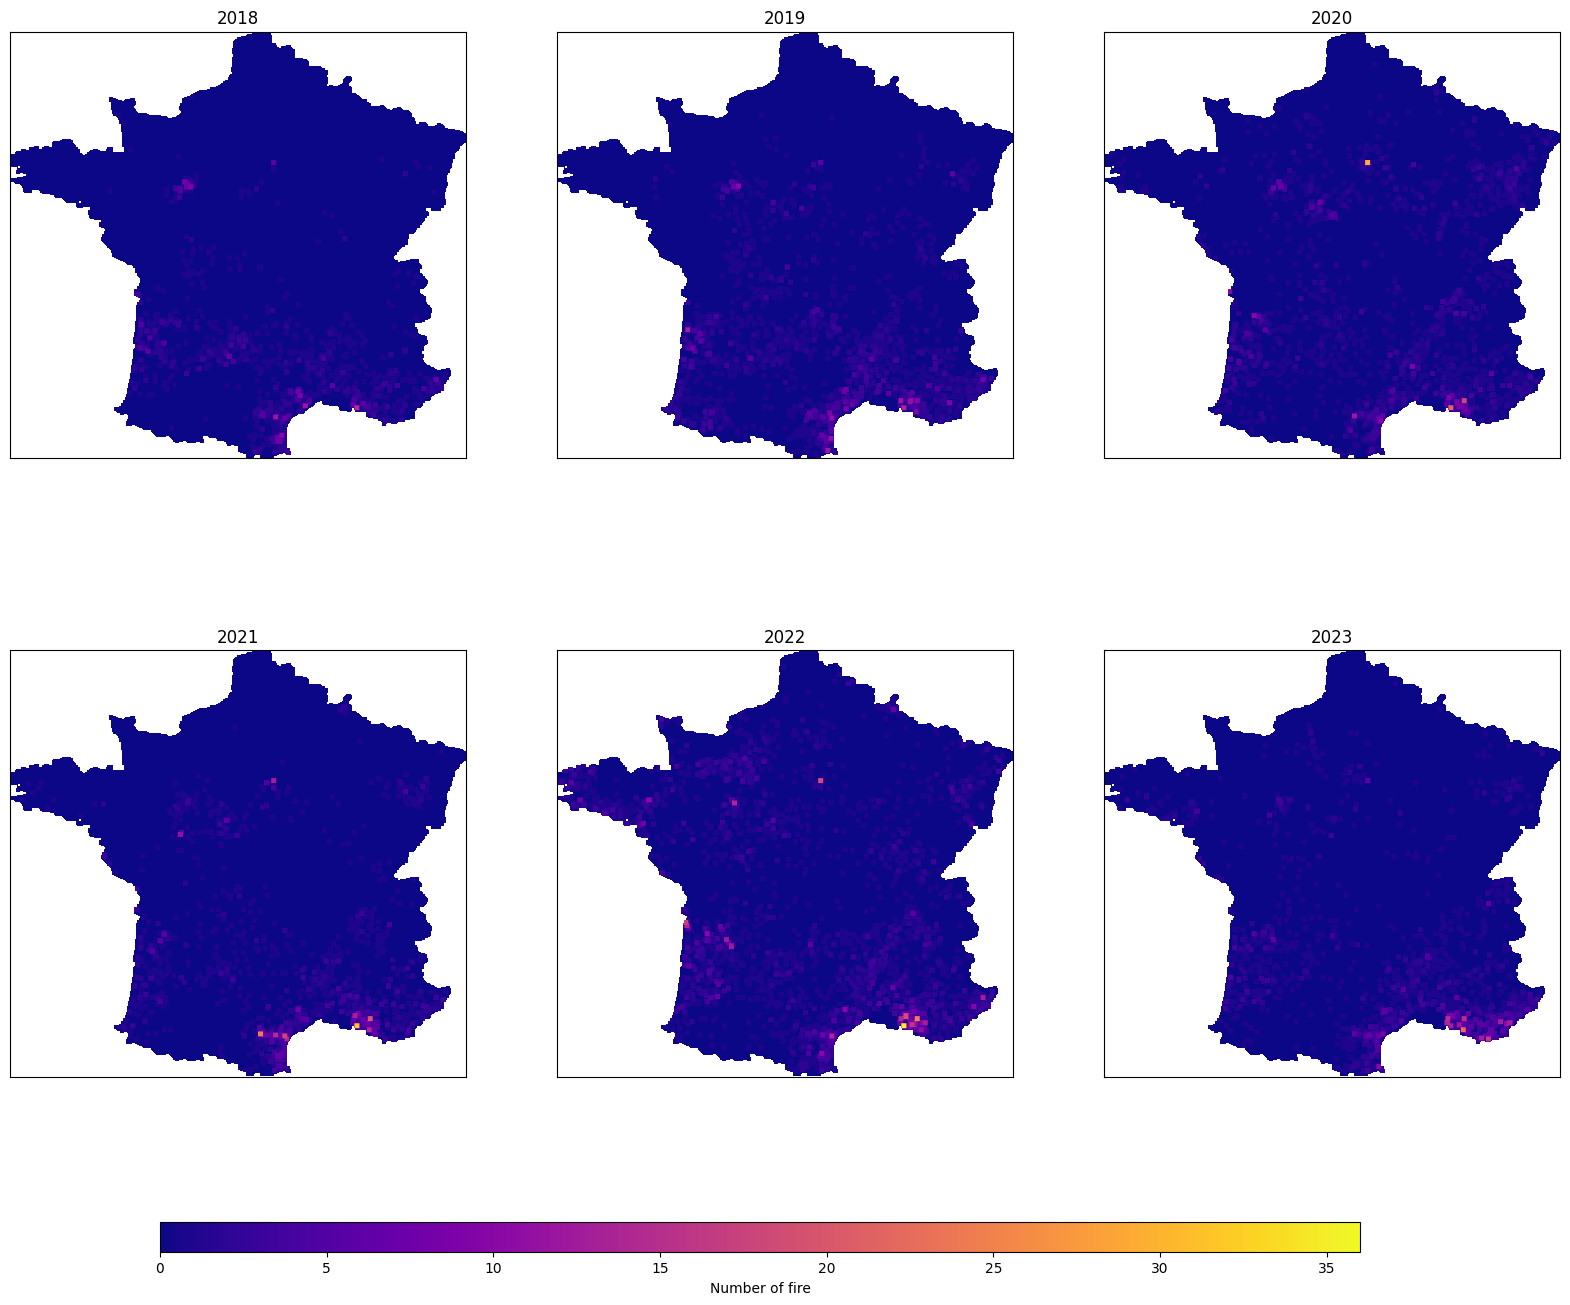

In [14]:
plot_matches_on_images(images_max_5, years, figsize=(20,15))

In [15]:
import numpy as np

def match_patch_group_max_diff(img1, img2, kernel_size=3, seuil=5):
    """
    Compare les valeurs maximales dans 8 groupes de patchs autour de chaque pixel positif de img1 avec ceux dans img2.

    Parameters:
        img1 (np.ndarray): Image source
        img2 (np.ndarray): Image de recherche
        kernel_size (int): Taille des patchs carrés (et aussi l'offset entre le centre et chaque patch)
        seuil (int): Seuil max de correspondances avant réduction par médiane

    Returns:
        list of [ (x_img1, y_img1), (x_img2, y_img2) ]
    """
    h, w = img1.shape
    matches = []
    stride = (kernel_size // 2) + 1
    offset = kernel_size
    patch_size = kernel_size

    directions = [
        (-offset, 0), (offset, 0), (0, -offset), (0, offset),
        (-offset, -offset), (-offset, offset), (offset, -offset), (offset, offset)
    ]

    for i in range(offset * 2, h - offset * 2, stride):
        for j in range(offset * 2, w - offset * 2, stride):
            if img1[i, j] <= 0:
                continue  # Ignore les pixels non positifs

            group_max_1 = []

            for di, dj in directions:
                i1 = i + di
                j1 = j + dj
                patch = img1[i1:i1 + patch_size, j1:j1 + patch_size]
                if patch.shape != (patch_size, patch_size) or np.all(patch == 0):
                    group_max_1.append(np.nan)
                else:
                    group_max_1.append(np.nanmean(patch))

            if np.isnan(group_max_1).all():
                continue

            i_min = max(i - offset, offset)
            i_max = min(i + offset + 1, h - offset)
            j_min = max(j - offset, offset)
            j_max = min(j + offset + 1, w - offset)

            candidates = []
            diffs = []

            for x in range(i_min, i_max):
                for y in range(j_min, j_max):
                    if img2[x, y] <= 0:
                        continue  # Ignore les pixels non positifs dans img2

                    group_max_2 = []
                    for di, dj in directions:
                        i2 = x + di
                        j2 = y + dj
                        patch = img2[i2:i2 + patch_size, j2:j2 + patch_size]
                        if patch.shape != (patch_size, patch_size) or np.all(patch == 0):
                            group_max_2.append(np.nan)
                        else:
                            group_max_2.append(np.nanmean(patch))

                    if np.isnan(group_max_2).all():
                        continue

                    valid = ~np.isnan(group_max_1) & ~np.isnan(group_max_2)
                    if not np.any(valid):
                        continue

                    diff = np.mean(np.abs(np.array(group_max_1)[valid] - np.array(group_max_2)[valid]))
                    diffs.append(diff)
                    candidates.append((x, y))

            if not diffs:
                continue

            min_diff = np.min(diffs)
            best_matches = [pt for k, pt in enumerate(candidates) if diffs[k] == min_diff]

            if len(best_matches) > seuil:
                xs, ys = zip(*best_matches)
                x2 = int(np.median(xs))
                y2 = int(np.median(ys))
                if i == x2 and j == y2:
                    continue
                matches.append([(i, j), (x2, y2)])
            else:
                for x2, y2 in best_matches:
                    if i == x2 and j == y2:
                        continue
                    matches.append([(i, j), (x2, y2)])

    return matches

im1 = np.copy(images_max_5[0])
im2 = np.copy(images_max_5[1])

diff_1_2 = match_patch_group_max_diff(im1, im2, kernel_size=30, seuil=3)

/tmp/ipykernel_8009/1033076784.py:41: RuntimeWarning: Mean of empty slice
  group_max_1.append(np.nanmean(patch))
/tmp/ipykernel_8009/1033076784.py:67: RuntimeWarning: Mean of empty slice
  group_max_2.append(np.nanmean(patch))


In [16]:
len(diff_1_2)

106

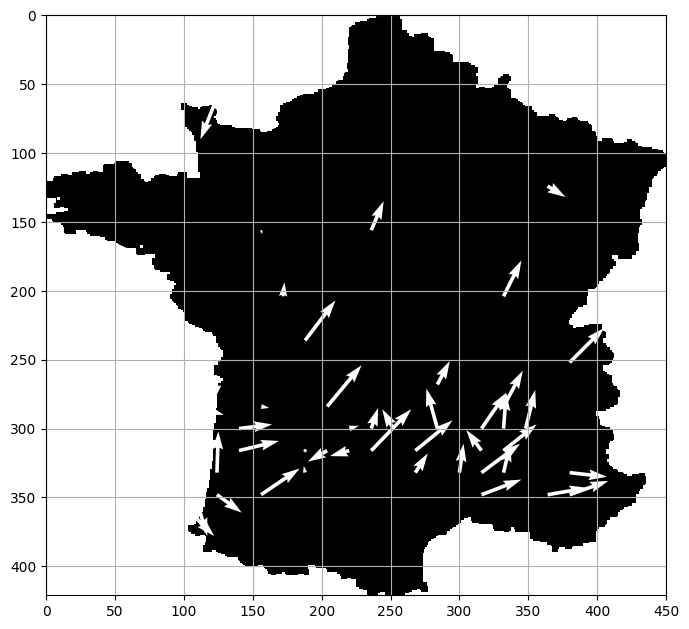

In [17]:
import matplotlib.pyplot as plt
import numpy as np

def plot_matches_with_arrows(matches, img, arrow_color='white', point_color='blue', figsize=(8, 8), title=''):
    """
    Affiche les correspondances sous forme de flèches entre pixels de deux images avec un fond noir,
    sauf aux positions NaN (affichées comme transparentes).

    Parameters:
        matches (list): Liste de paires [ (x1, y1), (x2, y2) ]
        img_shape (tuple): Shape de l’image pour dimensionner la figure (optionnel)
        arrow_color (str): Couleur des flèches
        point_color (str): Couleur des points de départ
        figsize (tuple): Taille de la figure
    """
    if not matches:
        print("Aucune correspondance à afficher.")
        return

    x1s, y1s = [], []
    dxs, dys = [], []

    for (x1, y1), (x2, y2) in matches:
        x1s.append(y1)
        y1s.append(x1)
        dxs.append(y2 - y1)
        dys.append(x2 - x1)

    plt.figure(figsize=figsize)
    img_shape = im.shape
    if img_shape:
        # Fond noir avec NaN visibles comme transparents
        background = np.zeros(img_shape)
        background[np.isnan(img)] = np.nan  # Redondant ici mais utile si background venait d'ailleurs
        plt.imshow(background, cmap='gray', origin='upper')
        plt.xlim(0, img_shape[1])
        plt.ylim(img_shape[0], 0)  # Inverser y pour affichage image

    plt.quiver(x1s, y1s, dxs, dys, angles='xy', scale_units='xy', scale=1, color=arrow_color)
    # plt.scatter(x1s, y1s, color=point_color, s=10, label='Points de départ')
    
    plt.gca().set_aspect('equal')
    plt.title(title)
    plt.grid(True)
    plt.show()

plot_matches_with_arrows(diff_1_2, im1)

In [18]:
import matplotlib.pyplot as plt
import numpy as np

def plot_nested_matches(matches_dict, img, arrow_color='white', point_color='blue', figsize=(12, 10)):
    """
    Affiche tous les ensembles de correspondances dans un dictionnaire à deux niveaux.
    Chaque combinaison (méthode, cas) est tracée sur un subplot avec fond noir sauf NaN.

    Parameters:
        matches_dict (dict): Dictionnaire {méthode: {cas: matches_list}}
        img (np.ndarray): Image de fond (NaN = transparents)
        arrow_color (str): Couleur des flèches
        point_color (str): Couleur des points de départ
        figsize (tuple): Taille globale de la figure
    """
    # Aplatir le dict en liste [(titre, matches), ...]
    flattened = []
    for method, cases in matches_dict.items():
        for case, matches in cases.items():
            title = f"{method} - {case}"
            flattened.append((title, matches))

    num_plots = len(flattened)
    cols = int(np.ceil(np.sqrt(num_plots)))
    rows = int(np.ceil(num_plots / cols))

    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = np.array(axes).reshape(-1)

    for idx, ((title, matches), ax) in enumerate(zip(flattened, axes)):
        x1s, y1s, dxs, dys = [], [], [], []

        for (x1, y1), (x2, y2) in matches:
            x1s.append(y1)
            y1s.append(x1)
            dxs.append(y2 - y1)
            dys.append(x2 - x1)

        # Fond noir avec transparence pour les NaN
        background = np.zeros(img.shape)
        background[np.isnan(img)] = np.nan
        ax.imshow(background, cmap='gray', origin='upper')

        ax.quiver(x1s, y1s, dxs, dys, angles='xy', scale_units='xy', scale=1, color=arrow_color)
        ax.set_xlim(0, img.shape[1])
        ax.set_ylim(img.shape[0], 0)
        ax.set_aspect('equal')
        ax.set_title(title)
        ax.grid(True)

    # Cacher les axes inutilisés
    for ax in axes[len(flattened):]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

In [19]:
im1.shape

(421, 450)

In [20]:
"""res = {}
import math

for i, im1 in enumerate(images_max_5):
    j = i + 1
    if i == len(images_max_5) -1:   
        break
    res[years[i]] = {}
    while j <= len(images_max_5) - 1:
        print(f'{years[i]}_{years[j]}')
        im2 = images_max_5[j]
        res[years[i]][years[j]] = match_patch_group_max_diff(im1, im2, kernel_size=15, seuil=math.inf)
        j += 1"""

"res = {}\nimport math\n\nfor i, im1 in enumerate(images_max_5):\n    j = i + 1\n    if i == len(images_max_5) -1:   \n        break\n    res[years[i]] = {}\n    while j <= len(images_max_5) - 1:\n        print(f'{years[i]}_{years[j]}')\n        im2 = images_max_5[j]\n        res[years[i]][years[j]] = match_patch_group_max_diff(im1, im2, kernel_size=15, seuil=math.inf)\n        j += 1"

In [21]:
#plot_nested_matches(res, im1, figsize=(25, 25))

## Segmentation

[0. 1. 2. 3.]


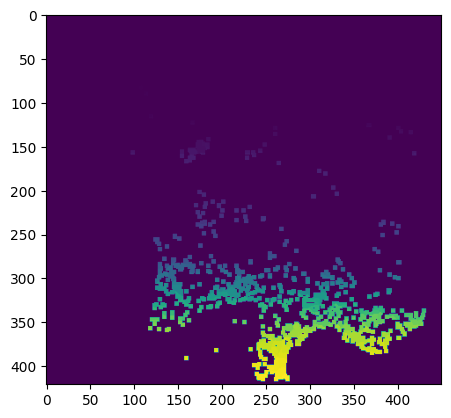

In [22]:

def my_watershed(data, valid_mask, apply_kmeans=True):

        if apply_kmeans:
                reducor = KMeans(n_clusters=4, n_init=10)
                reducor.fit(data[valid_mask].reshape(-1,1))
                data[valid_mask] = reducor.predict(data[valid_mask].reshape(-1,1))
                data[valid_mask] = order_class(reducor, data[valid_mask])
                print(np.unique(data[valid_mask]))
        data[~valid_mask] = 0

        data[valid_mask] = morphology.erosion(data, morphology.square(1))[valid_mask]

        # High Fire region
        # Détection des contours avec l'opérateur Sobel
        edges = filters.sobel(data)

        # Créer une carte de distance
        distance = np.full(data.shape, fill_value=0.0)
        distance = ndi.distance_transform_edt(edges)

        # Marquer les objets (régions connectées) dans l'image
        local_maxi = np.full(data.shape, fill_value=0)
        markers = np.full(data.shape, fill_value=0)
        local_maxi = morphology.local_maxima(distance)
        markers, _ = ndi.label(local_maxi)

        # Appliquer la segmentation Watershed
        pred = watershed(-data, markers, mask=data, connectivity=1)
        return pred

res_watershed = my_watershed(np.copy(images_max_5[0]), ~np.isnan(images_max_5[0]))
plt.imshow(res_watershed)

In [23]:
def merge_adjacent_clusters(image, nb_attempt=3, mode='size', min_cluster_size=0, max_cluster_size=math.inf, exclude_label=None, background=-1):
    """
    Fusionne les clusters adjacents dans une image en fonction de critères définis.
    
    Paramètres :
    - image : Image labellisée contenant des clusters.
    - mode : Critère de fusion ('size', 'time_series_similarity', 'time_series_similarity_fast').
    - min_cluster_size : Taille minimale d'un cluster avant fusion.
    - max_cluster_size : Taille maximale autorisée après fusion.
    - oridata : Données supplémentaires utilisées pour la fusion basée sur des séries temporelles (facultatif).
    - exclude_label : Label à exclure de la fusion.
    - background : Label représentant le fond (par défaut -1).
    """

    # Copie de l'image d'entrée pour éviter de la modifier directement
    labeled_image = np.copy(image)

    # Obtenir les propriétés des régions labellisées
    regions = measure.regionprops(labeled_image)
    # Trier les régions par taille croissante
    regions = sorted(regions, key=lambda r: r.area)

    # Masque pour stocker les labels mis à jour après fusion
    res = np.copy(labeled_image)

    # Liste des labels qui ont été modifiés
    changed_labels = []

    # Nombre d'essais pour dilater un cluster avant abandon
    nb_attempt = 3

    # Longueur initiale des régions
    len_regions = len(regions)
    i = 0

    # Boucle pour traiter chaque région
    while i < len_regions:
        region = regions[i]

        # Vérifier si le cluster est à exclure ou est un fond
        if region.label == exclude_label or region.label == background:
            # On conserve ces clusters tels quels
            res[labeled_image == region.label] = region.label
            i += 1
            continue

        label = region.label

        # Si le label a déjà été modifié, passer au suivant
        #if label in changed_labels:
        #    i += 1
        #    continue

        # Vérifier la taille du cluster actuel
        ones = np.argwhere(res == label).shape[0]
        if ones < min_cluster_size:
            # Si la taille est inférieure au minimum, essayer de fusionner avec un voisin
            nb_test = 0
            find_neighbor = False
            dilated_image = np.copy(res)
            while nb_test < nb_attempt and not find_neighbor:

                # Trouver les voisins du cluster actuel
                best_neighbor = None
                mask_label = dilated_image == label
                mask_label_ori = res == label
                neighbors = segmentation.find_boundaries(mask_label, connectivity=1, mode='outer', background=background)
                neighbor_labels = np.unique(dilated_image[neighbors])
                
                    #print(neighbor_labels)
                
                # Exclure les labels indésirables
                neighbor_labels = neighbor_labels[(neighbor_labels != exclude_label) & (neighbor_labels != background) & (neighbor_labels != label)]

                dilate = True
                changed_labels.append(label)

                if len(neighbor_labels) > 0:
                    # Trier les voisins par taille
                    #neighbors_size = np.sort([[neighbor_label, np.sum(res == neighbor_label)] for neighbor_label in neighbor_labels], axis=0)
                    #neighbors_size = np.sort([[neighbor_label, np.sum(res == neighbor_label)] for neighbor_label in neighbor_labels], axis=1)
                    
                    neighbors_size = sorted(
                        [[neighbor_label, np.sum(res == neighbor_label)] for neighbor_label in neighbor_labels],
                        key=lambda x: x[1]  # trie par la somme (ordre croissant)
                    )

                    if mode == 'size':
                        # Mode basé sur la taille des clusters
                        max_neighbor_size = -math.inf
                        for nei, neighbor in enumerate(neighbors_size):
                            
                            if neighbor[0] == label:
                                continue
                            
                            neighbor_size = neighbor[1] + np.sum(res == label)

                            # Vérifier si le voisin satisfait min_cluster_size
                            if neighbor_size > min_cluster_size:
                                # Vérifier si la taille reste sous max_cluster_size
                                if neighbor_size < max_cluster_size:
                                    dilate = False
                                    res[mask_label_ori] = neighbor[0]
                                    dilated_image[dilated_image == label] = neighbor[0]
                                    print(f'Use neighbord label {label} -> {neighbor[0]}')
                                    label = neighbor[0]
                                    find_neighbor = True
                                    break
                                
                                best_neighbor = neighbor[0]
                                max_neighbor_size = neighbor_size
                                break

                            # Enregistrer le plus grand voisin si min_cluster_size n'est pas atteint
                            if neighbor_size > max_neighbor_size:
                                best_neighbor = neighbor[0]
                                max_neighbor_size = neighbor_size

                        # Si aucun voisin ne satisfait les critères, utiliser le plus grand
                        if not find_neighbor and best_neighbor is not None:
                            if max_neighbor_size < max_cluster_size:
                                res[mask_label] = best_neighbor
                                dilated_image[dilated_image == label] = best_neighbor
                                dilate = False
                                print(f'Use biggest neighbord label {label} -> {best_neighbor}')
                                label = best_neighbor
                                find_neighbor = True
                                
                                # Si la taille après fusion dépasse la taille maximal, appliquer l'érosion (peut être ne pas fusionner)
                                """if max_neighbor_size < max_cluster_size:
                                    mask_label = dilated_image == label
                                    ones = np.argwhere(mask_label == 1).shape[0]
                                    while ones > max_cluster_size:
                                        mask_label = morphology.erosion(mask_label, morphology.disk(3))
                                        ones = np.argwhere(mask_label == 1).shape[0]"""
                                break

                # Si aucun voisin trouvé, dilater la région
                if dilate:
                    mask_label = morphology.dilation(mask_label, morphology.square(3))
                    dilated_image[dilated_image == label] = label
                    nb_test += 1

                if not dilate:
                    break
                
            # Si aucun voisin trouvé après nb_attempt, supprimer ou conserver la région
            if not find_neighbor:
                if ones < min_cluster_size:
                    mask_label = dilated_image == label
                    ones = np.argwhere(mask_label == 1).shape[0] 
                    # Si l'objet dilaté ne vérifie pas la condition minimum
                    if ones < min_cluster_size:
                        res[mask_label] = 0
                        print(f'Remove label {region.label}')
                    else:
                        # Si l'objet dilaté ne vérifie pas la condition maximum
                        while ones > max_cluster_size:
                            mask_label = morphology.erosion(mask_label, morphology.square(3))
                            ones = np.argwhere(mask_label == 1).shape[0]
                        
                        res[mask_label] = region.label
                        print(f'Keep label dilated {region.label}')

            # Mettre à jour les régions pour tenir compte des changements
            regions = measure.regionprops(res)
            #if label == 7 or label == 11:
            #    print(np.unique(res))
            regions = sorted(regions, key=lambda r: r.area)
            len_regions = len(regions)
            i = 0
            continue
        else:
            mask_label = res == region.label
            mask_before_erosion = np.copy(mask_label)
            while ones > max_cluster_size:
                mask_label = morphology.erosion(mask_label, morphology.square(3))
                ones = np.argwhere(mask_label == 1).shape[0]

            res[mask_before_erosion & ~mask_label] = background

            # Si le cluster est assez grand, on le conserve tel quel
            print(f'Keep label {region.label}')
            
        i += 1
        
    return res

In [24]:
scale = 4

nb_attempt = 3
min_cluster_size = 1 + scale * 3 * (scale + 1)
max_cluster_size = 2.5 * min_cluster_size
exclude_label = [0]
background = -1

def image_process(image, mask, **args):
    valid_mask = ~np.isnan(image)
    res_watershed = my_watershed(image, valid_mask)

    merge_region = merge_adjacent_clusters(res_watershed, **args)

    valid_cluster = find_clusters(merge_region, min_cluster_size, 0, -1)

    valid_cluster = [val + 1 for val in valid_cluster]
    merge_region[valid_mask] += 1
    merge_region = split_large_clusters(merge_region, max_cluster_size, min_cluster_size, valid_cluster)
    valid_cluster = [val - 1 for val in valid_cluster]
    merge_region[valid_mask] -= 1
    
    valid_mask = ~mask
    merge_region = merge_region.astype(np.float32)
    merge_region[mask] = np.nan
    return merge_region

merge_region = image_process(images_max_5[0],  np.isnan(images[0]), nb_attempt=nb_attempt, mode='size', min_cluster_size=min_cluster_size, max_cluster_size=max_cluster_size, exclude_label=exclude_label, background=background)

[0. 1. 2. 3.]
Use neighbord label 485 -> 484
Remove label 990
Use neighbord label 1075 -> 1055
Use biggest neighbord label 1084 -> 1080
Use neighbord label 1156 -> 1159
Use neighbord label 1171 -> 1159
Use biggest neighbord label 1185 -> 1191
Use neighbord label 56 -> 50
Use neighbord label 59 -> 50
Use neighbord label 87 -> 74
Use biggest neighbord label 125 -> 121
Use neighbord label 557 -> 527
Use neighbord label 619 -> 608
Use neighbord label 639 -> 608
Remove label 658
Remove label 708
Use neighbord label 986 -> 946
Use neighbord label 1057 -> 1055
Use neighbord label 1095 -> 1086
Use biggest neighbord label 1163 -> 1157
Use neighbord label 1167 -> 1154
Use biggest neighbord label 103 -> 97
Use neighbord label 356 -> 355
Use neighbord label 376 -> 355
Remove label 580
Use biggest neighbord label 669 -> 656
Remove label 699
Use biggest neighbord label 784 -> 741
Use biggest neighbord label 1028 -> 1017
Use biggest neighbord label 1102 -> 1092
Use biggest neighbord label 1134 -> 113

In [25]:
image_cluster = [image_process(im, np.isnan(images[0]), nb_attempt=nb_attempt, min_cluster_size=min_cluster_size, max_cluster_size=max_cluster_size, exclude_label=exclude_label, background=background) for im in images_max_5]

[0. 1. 2. 3.]
Use neighbord label 485 -> 484
Remove label 990
Use neighbord label 1075 -> 1055
Use biggest neighbord label 1084 -> 1080
Use neighbord label 1156 -> 1159
Use neighbord label 1171 -> 1159
Use biggest neighbord label 1185 -> 1191
Use neighbord label 56 -> 50
Use neighbord label 59 -> 50
Use neighbord label 87 -> 74
Use biggest neighbord label 125 -> 121
Use neighbord label 557 -> 527
Use neighbord label 619 -> 608
Use neighbord label 639 -> 608
Remove label 658
Remove label 708
Use neighbord label 986 -> 946
Use neighbord label 1057 -> 1055
Use neighbord label 1095 -> 1086
Use biggest neighbord label 1163 -> 1157
Use neighbord label 1167 -> 1154
Use biggest neighbord label 103 -> 97
Use neighbord label 356 -> 355
Use neighbord label 376 -> 355
Remove label 580
Use biggest neighbord label 669 -> 656
Remove label 699
Use biggest neighbord label 784 -> 741
Use biggest neighbord label 1028 -> 1017
Use biggest neighbord label 1102 -> 1092
Use biggest neighbord label 1134 -> 113

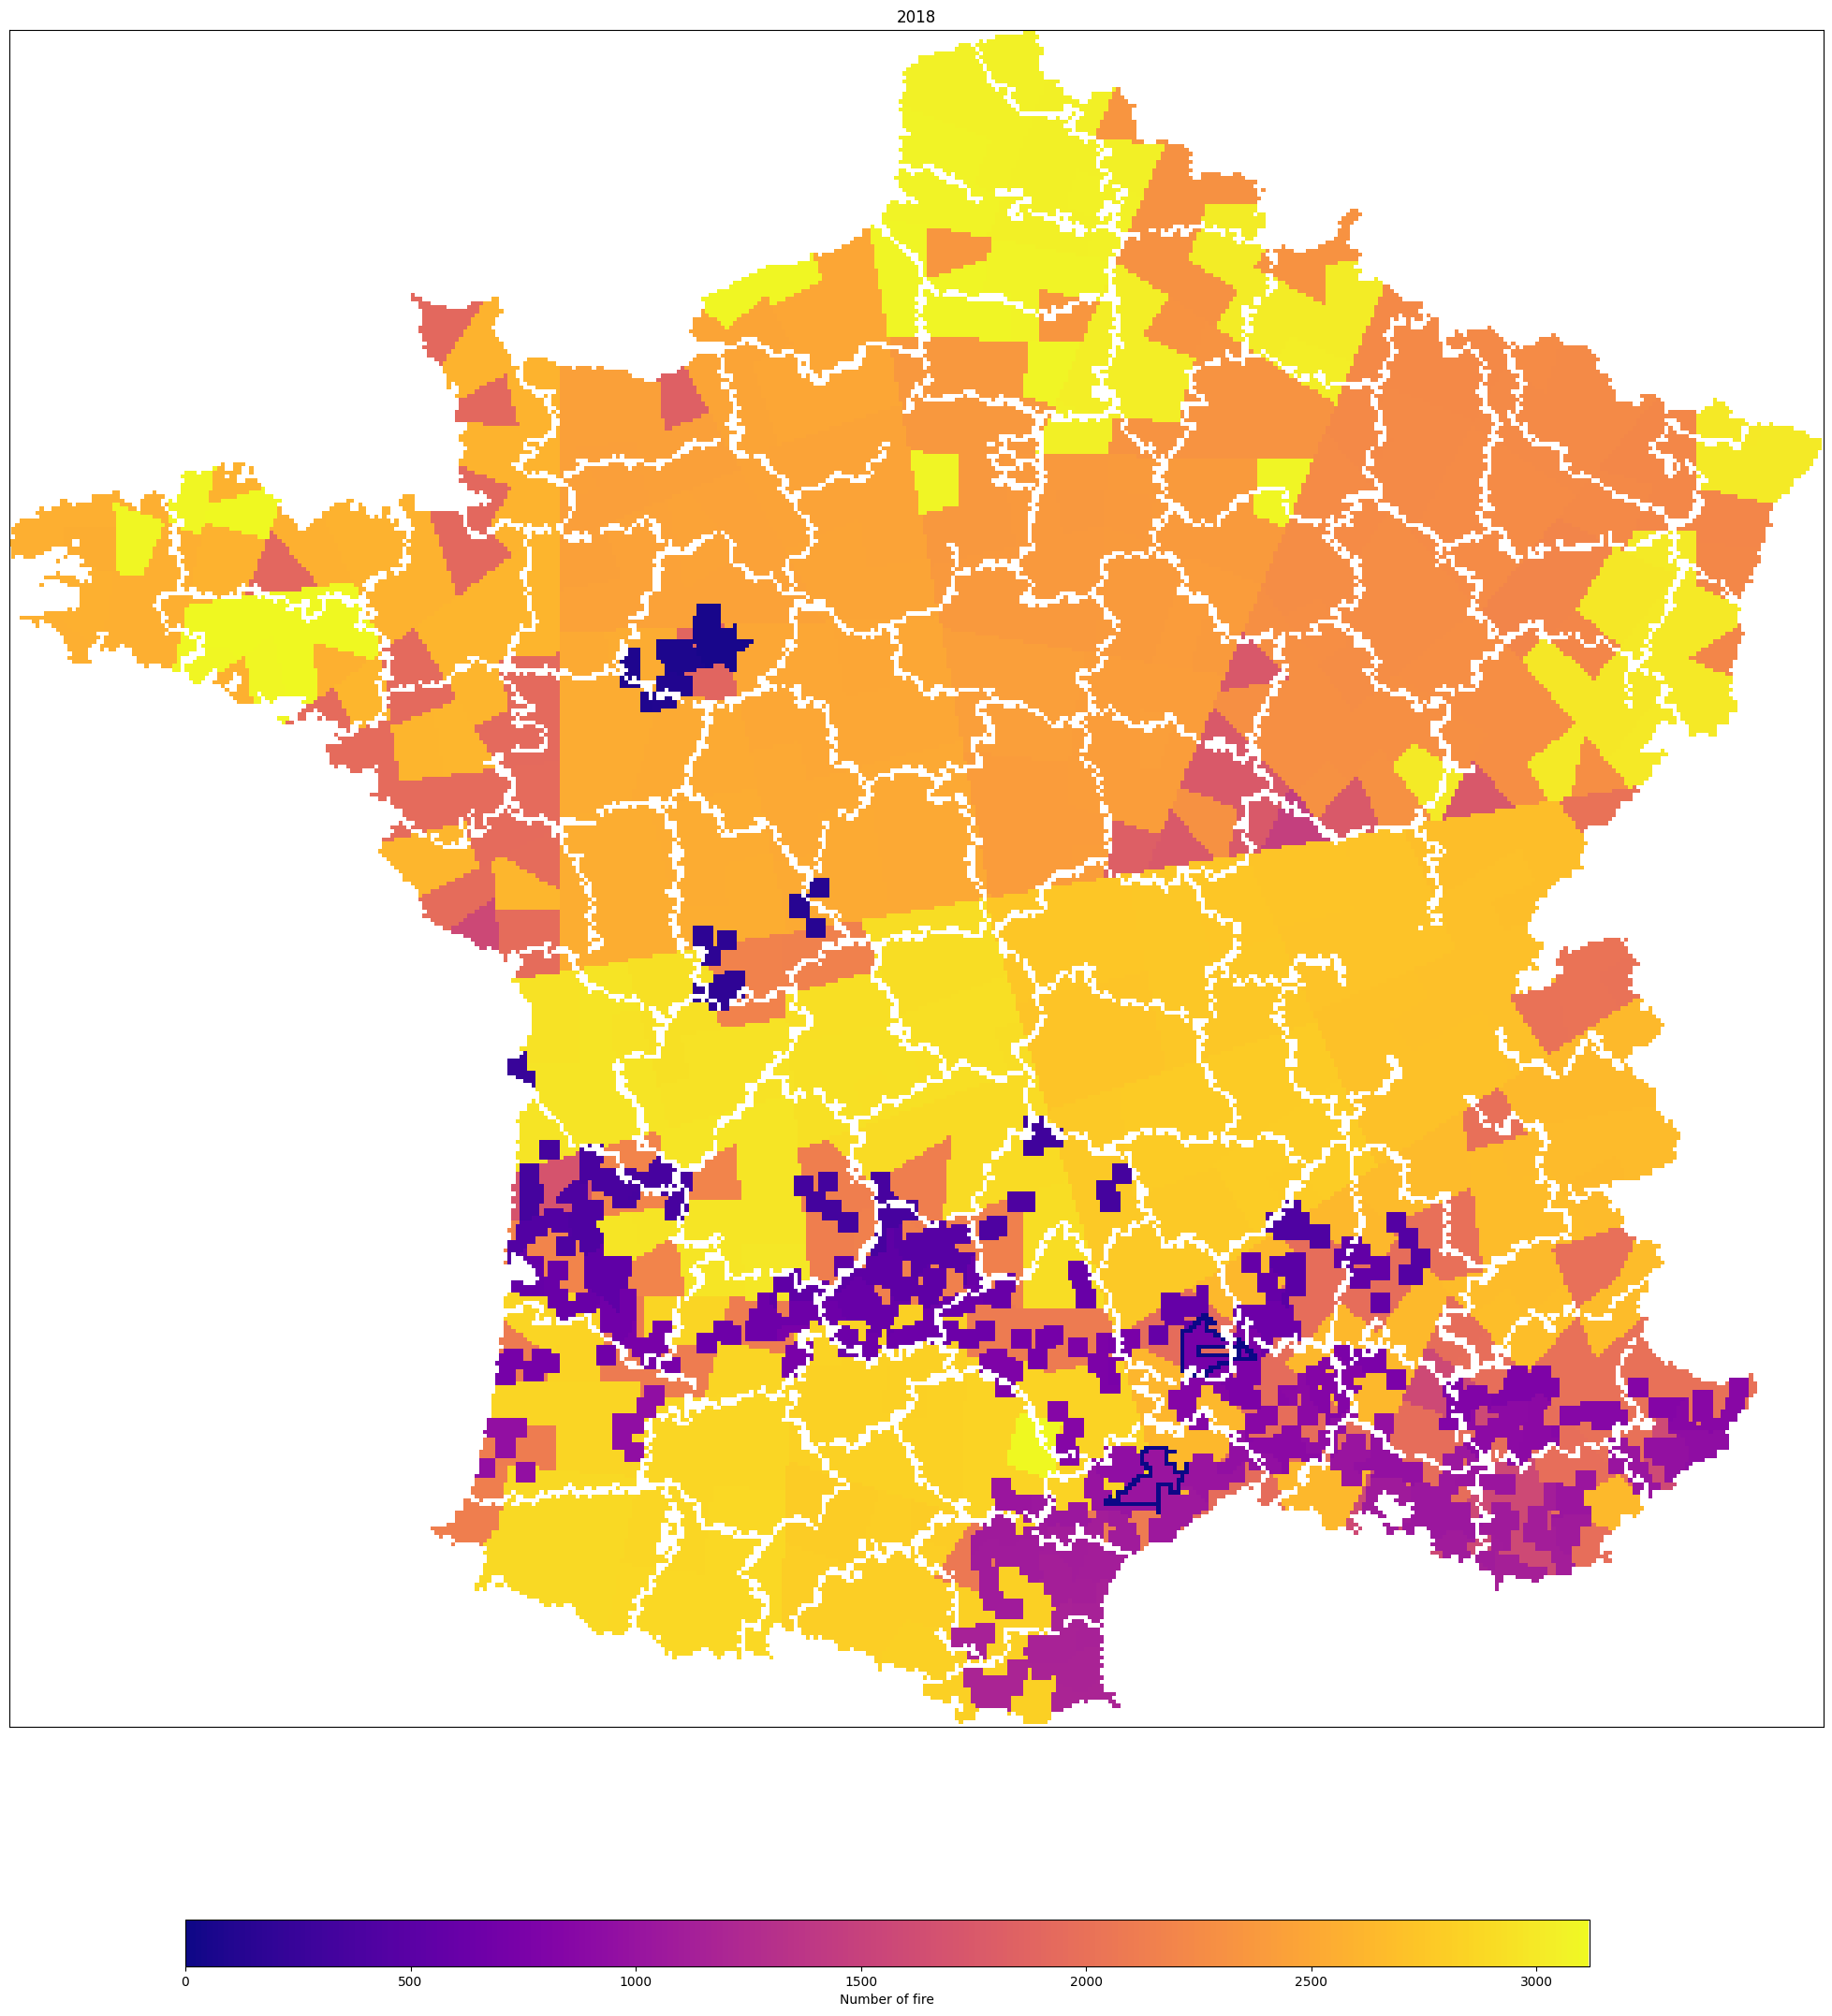

In [26]:
plot_matches_on_images([merge_region], years, figsize=(25,25), cmap='plasma')

In [27]:
new_burned_area = np.zeros(image_cluster[0].shape)
old_burned_area = np.zeros(image_cluster[0].shape)

for i, img1 in enumerate(image_cluster):
    if i == len(image_cluster) - 1:
        break
    j = i + 1
    img2 = image_cluster[j]
    diff = (img2 > 0).astype(int) - (img1 > 0).astype(int)
    new_burned_area[diff == 1] = 1
    old_burned_area[diff == -1] = 1

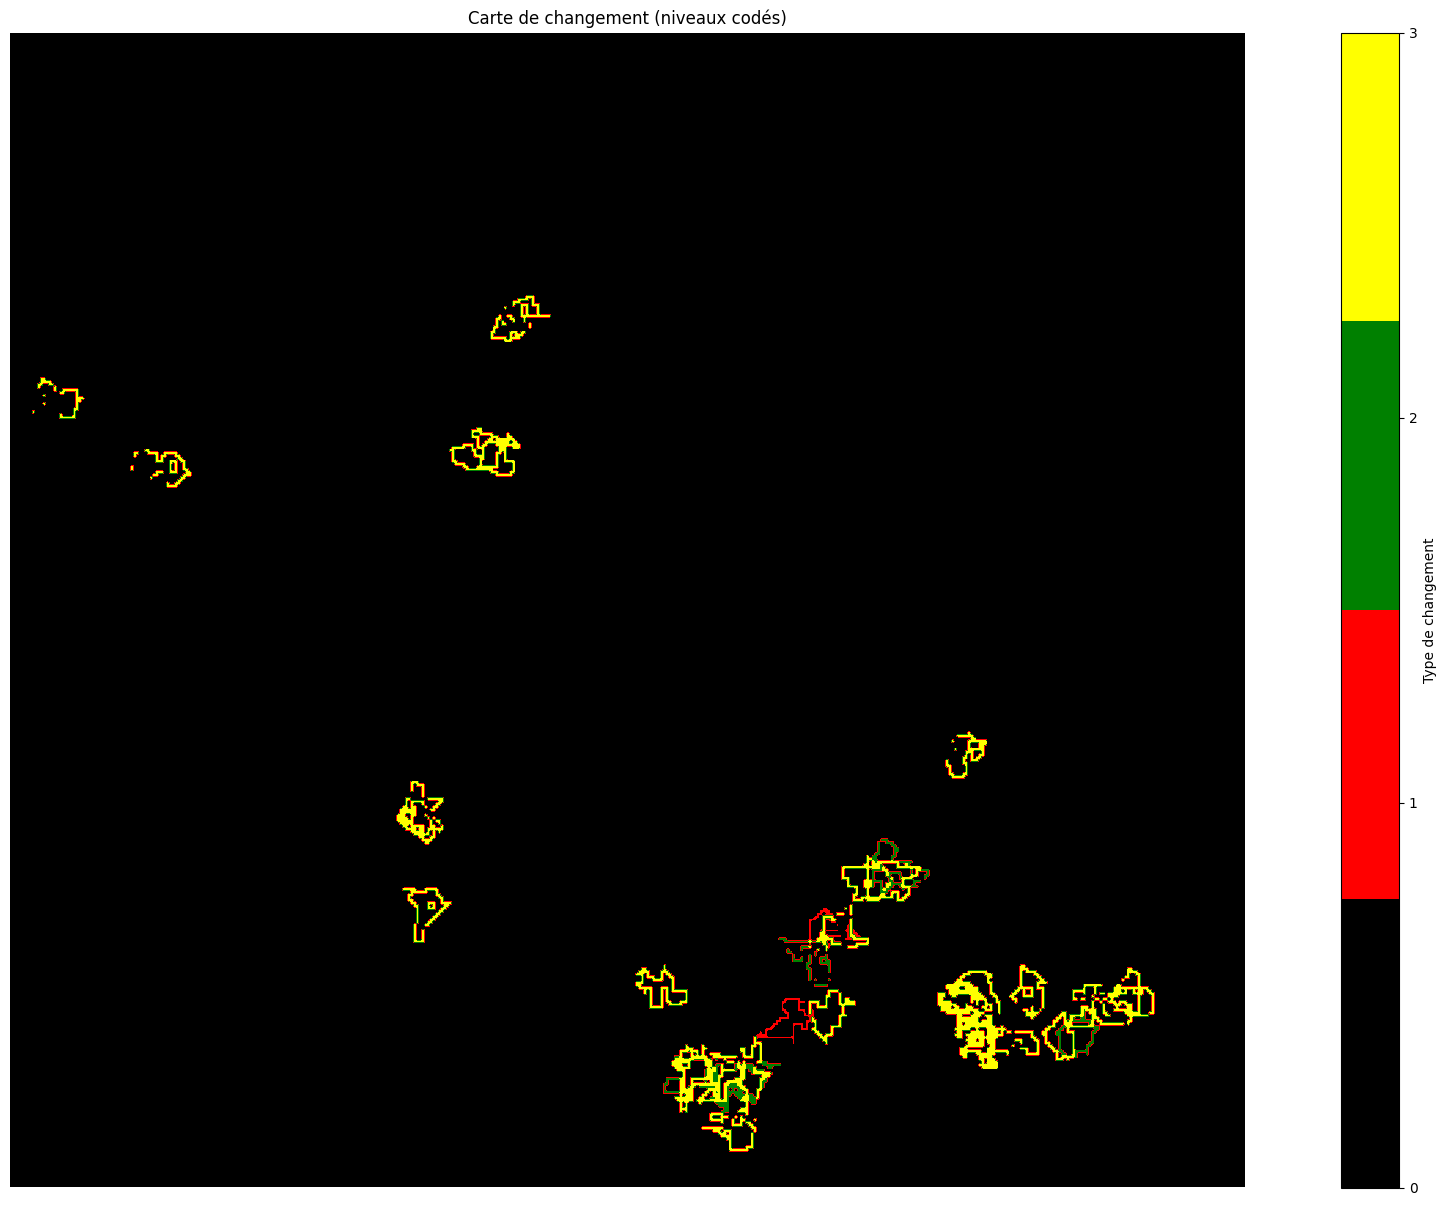

In [28]:
# Image codée en niveaux de gris avec classes
change_map = np.zeros(new_burned_area.shape, dtype=np.float64)

# Masques
both = (new_burned_area == 1) & (old_burned_area == 1)
only_new = (new_burned_area == 1) & (~both)
only_old = (old_burned_area == 1) & (~both)

# Assignation des classes
change_map[only_new] = 1     # brûlé
change_map[only_old] = 2     # récupéré
change_map[both] = 3         # les deux
change_map[np.isnan(images_max_5[0])] = np.nan

# Affichage avec une colormap personnalisée
from matplotlib.colors import ListedColormap

# Couleurs : noir, rouge, vert, jaune
cmap = ListedColormap([
    "black",   # 0 = aucun changement
    "red",     # 1 = brûlé
    "green",   # 2 = récupéré
    "yellow"   # 3 = les deux
])

plt.figure(figsize=(25, 15))
plt.imshow(change_map, cmap=cmap)
plt.title("Carte de changement (niveaux codés)")
plt.axis('off')
plt.colorbar(ticks=[0,1,2,3], label="Type de changement")
plt.clim(0, 3)
plt.show()

In [29]:
import numpy as np
import matplotlib.pyplot as plt

def count_burns_from_index(image_cluster, j=0, stop=None, show=True):
    """
    Compte le nombre de fois qu'un pixel passe de non-brûlé à brûlé,
    à partir de l'index j, en considérant un état initial vide.

    Paramètres :
        image_cluster (list of np.ndarray): Liste d'images 2D (même taille).
        j (int): Index de départ pour le comptage.
        show (bool): Si True, affiche la carte de brûlures.

    Retourne :
        burn_count (np.ndarray): Carte du nombre de brûlures par pixel.
    """
    if stop is None:
        stop = len(image_cluster) - 1

    # Ajouter une image initiale à 0 en tête
    initial_shape = image_cluster[0].shape
    extended_cluster = [np.zeros(initial_shape, dtype=image_cluster[0].dtype)] + image_cluster
    stop += 1

    if j >= len(extended_cluster) - 1:
        raise ValueError("L'index j doit être entre 0 et len(image_cluster)-1")

    burn_count = np.zeros(initial_shape, dtype=int)

    for i in range(j, stop):
        img1 = extended_cluster[i]
        img2 = extended_cluster[i + 1]
        newly_burned = ((img1 == 0) & (img2 > 0))
        burn_count[newly_burned] += 1

    if show:
        plt.figure(figsize=(10, 10))
        plt.imshow(burn_count, cmap='hot')
        plt.title(f"Nombre de brûlures par pixel (à partir de j = {j - 1})")
        plt.colorbar(label="Nb de brûlures")
        plt.axis('off')
        plt.show()

    return burn_count

def count_burns_all_pairs(image_cluster, j=0, stop=None, show=True):
    """
    Compte le nombre de fois qu’un pixel passe de 0 à 1 entre toutes
    les paires d’images i < k dans l’intervalle [j, stop].

    Paramètres :
        image_cluster (list of np.ndarray): Liste d'images 2D.
        j (int): Index de départ.
        stop (int): Index de fin (inclus). Si None, prend la fin.
        show (bool): Affiche la carte des brûlures si True.

    Retourne :
        burn_count (np.ndarray): Carte du nombre de transitions 0 → 1.
    """
    if stop is None:
        stop = len(image_cluster) - 1

    # Ajouter une image vide au début
    initial_shape = image_cluster[0].shape
    extended_cluster = [np.zeros(initial_shape, dtype=image_cluster[0].dtype)] + image_cluster
    j += 1
    stop += 1

    if j >= len(extended_cluster):
        raise ValueError("L'index j est hors limites")

    burn_count = np.zeros(initial_shape, dtype=int)

    for i in range(j, stop):
        img_i = (extended_cluster[i] > 0).astype(int)
        for k in range(i + 1, stop + 1):
            img_k = (extended_cluster[k] > 0).astype(int)
            # Détecte les pixels qui étaient 0 à i et deviennent 1 à k
            newly_burned = (img_i == 0) & (img_k == 1)
            burn_count[newly_burned] += 1

    if show:
        plt.figure(figsize=(10, 10))
        plt.imshow(burn_count, cmap='hot')
        plt.title(f"Transitions 0 → 1 entre toutes paires i < k (j = {j - 1})")
        plt.colorbar(label="Nb de brûlures")
        plt.axis('off')
        plt.show()

    return burn_count


def count_recoveries_all_pairs(image_cluster, j=0, stop=None, show=True):
    """
    Compte le nombre de fois qu’un pixel passe de 1 à 0 entre toutes
    les paires d’images i < k dans l’intervalle [j, stop], en partant d’un
    état initial entièrement brûlé (1 partout).

    Paramètres :
        image_cluster (list of np.ndarray): Liste d'images 2D.
        j (int): Index de départ.
        stop (int): Index de fin (inclus). Si None, prend la fin.
        show (bool): Affiche la carte des récupérations si True.

    Retourne :
        recovery_count (np.ndarray): Carte du nombre de transitions 1 → 0.
    """
    if stop is None:
        stop = len(image_cluster) - 1

    initial_shape = image_cluster[0].shape
    # Image initiale à 1 (entièrement brûlée)
    extended_cluster = [np.ones(initial_shape, dtype=image_cluster[0].dtype)] + image_cluster
    j += 1
    stop += 1

    if j >= len(extended_cluster):
        raise ValueError("L'index j est hors limites")

    recovery_count = np.zeros(initial_shape, dtype=int)

    for i in range(j, stop):
        img_i = (extended_cluster[i] > 0).astype(int)
        for k in range(i + 1, stop + 1):
            img_k = (extended_cluster[k] > 0).astype(int)
            recovered = (img_i == 1) & (img_k == 0)
            recovery_count[recovered] += 1

    if show:
        plt.figure(figsize=(10, 10))
        plt.imshow(recovery_count, cmap='Greens')
        plt.title(f"Transitions 1 → 0 entre toutes paires i < k (j = {j - 1})")
        plt.colorbar(label="Nb de récupérations")
        plt.axis('off')
        plt.show()

    return recovery_count


def count_always_burned_pixels(image_cluster, j=0, stop=None, show=True):
    """
    Identifie les pixels constamment brûlés (toujours 1) entre j et stop.

    Retourne une carte binaire : 1 = toujours brûlé, 0 = sinon.
    """
    if stop is None:
        stop = len(image_cluster) - 1

    subset = image_cluster[j:stop + 1]
    pixel_stack = np.stack([(img > 0).astype(int) for img in subset], axis=0)

    always_burned = np.all(pixel_stack == 1, axis=0).astype(int)

    if show:
        plt.figure(figsize=(10, 10))
        plt.imshow(always_burned, cmap='Reds')
        plt.title(f"Pixels constamment brûlés de j={j} à stop={stop}")
        plt.axis('off')
        plt.show()

    return always_burned

def count_never_burned_pixels(image_cluster, j=0, stop=None, show=True):
    """
    Identifie les pixels qui n’ont jamais brûlé (toujours 0) entre j et stop.

    Retourne une carte binaire : 1 = jamais brûlé, 0 = sinon.
    """
    if stop is None:
        stop = len(image_cluster) - 1

    subset = image_cluster[j:stop + 1]
    pixel_stack = np.stack([(img > 0).astype(int) for img in subset], axis=0)

    never_burned = np.all(pixel_stack == 0, axis=0).astype(int)

    if show:
        plt.figure(figsize=(10, 10))
        plt.imshow(never_burned, cmap='Greys')
        plt.title(f"Pixels jamais brûlés de j={j} à stop={stop}")
        plt.axis('off')
        plt.show()

    return never_burned

def generate_fire_dynamics_series(image_cluster, years):
    """
    Calcule plusieurs cartes d'évolution de feu entre les années fournies.

    Paramètres :
        image_cluster (list of np.ndarray): Liste d'images temporelles (binaire feu).
        years (list): Liste des années correspondant aux images.

    Retourne :
        dict contenant :
            - 'burns': cartes de nouveaux feux
            - 'recoveries': cartes de récupérations
            - 'always_burned': pixels toujours brûlés
            - 'never_burned': pixels jamais brûlés
            - 'titles': titres associés aux années (ex: '2000_2005')
    """
    all_burn_counts = []
    all_recovery_counts = []
    all_fire_counts = []
    all_non_counts = []
    titles = []

    for j in range(len(image_cluster) - 1):
        print(f"\n🔄 Calcul pour l’intervalle {years[0]} → {years[j + 1]}")

        burn_count = count_burns_all_pairs(image_cluster, j=0, stop=j + 1, show=False)
        recovery = count_recoveries_all_pairs(image_cluster, j=0, stop=j + 1, show=False)
        always = count_always_burned_pixels(image_cluster, j=0, stop=j + 1, show=False)
        never = count_never_burned_pixels(image_cluster, j=0, stop=j + 1, show=False)

        all_burn_counts.append(burn_count)
        all_recovery_counts.append(recovery)
        all_fire_counts.append(always)
        all_non_counts.append(never)
        titles.append(f'{years[0]}_{years[j + 1]}')

    return {
        'burns': all_burn_counts,
        'recoveries': all_recovery_counts,
        'always_burned': all_fire_counts,
        'never_burned': all_non_counts,
        'titles': titles
    }


🔄 Calcul pour l’intervalle 2018 → 2019

🔄 Calcul pour l’intervalle 2018 → 2020

🔄 Calcul pour l’intervalle 2018 → 2021

🔄 Calcul pour l’intervalle 2018 → 2022

🔄 Calcul pour l’intervalle 2018 → 2023


/home/caron/Bureau/.conda/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Casting input data from float128 to float64 for imshow.
  fig.canvas.print_figure(bytes_io, **kw)


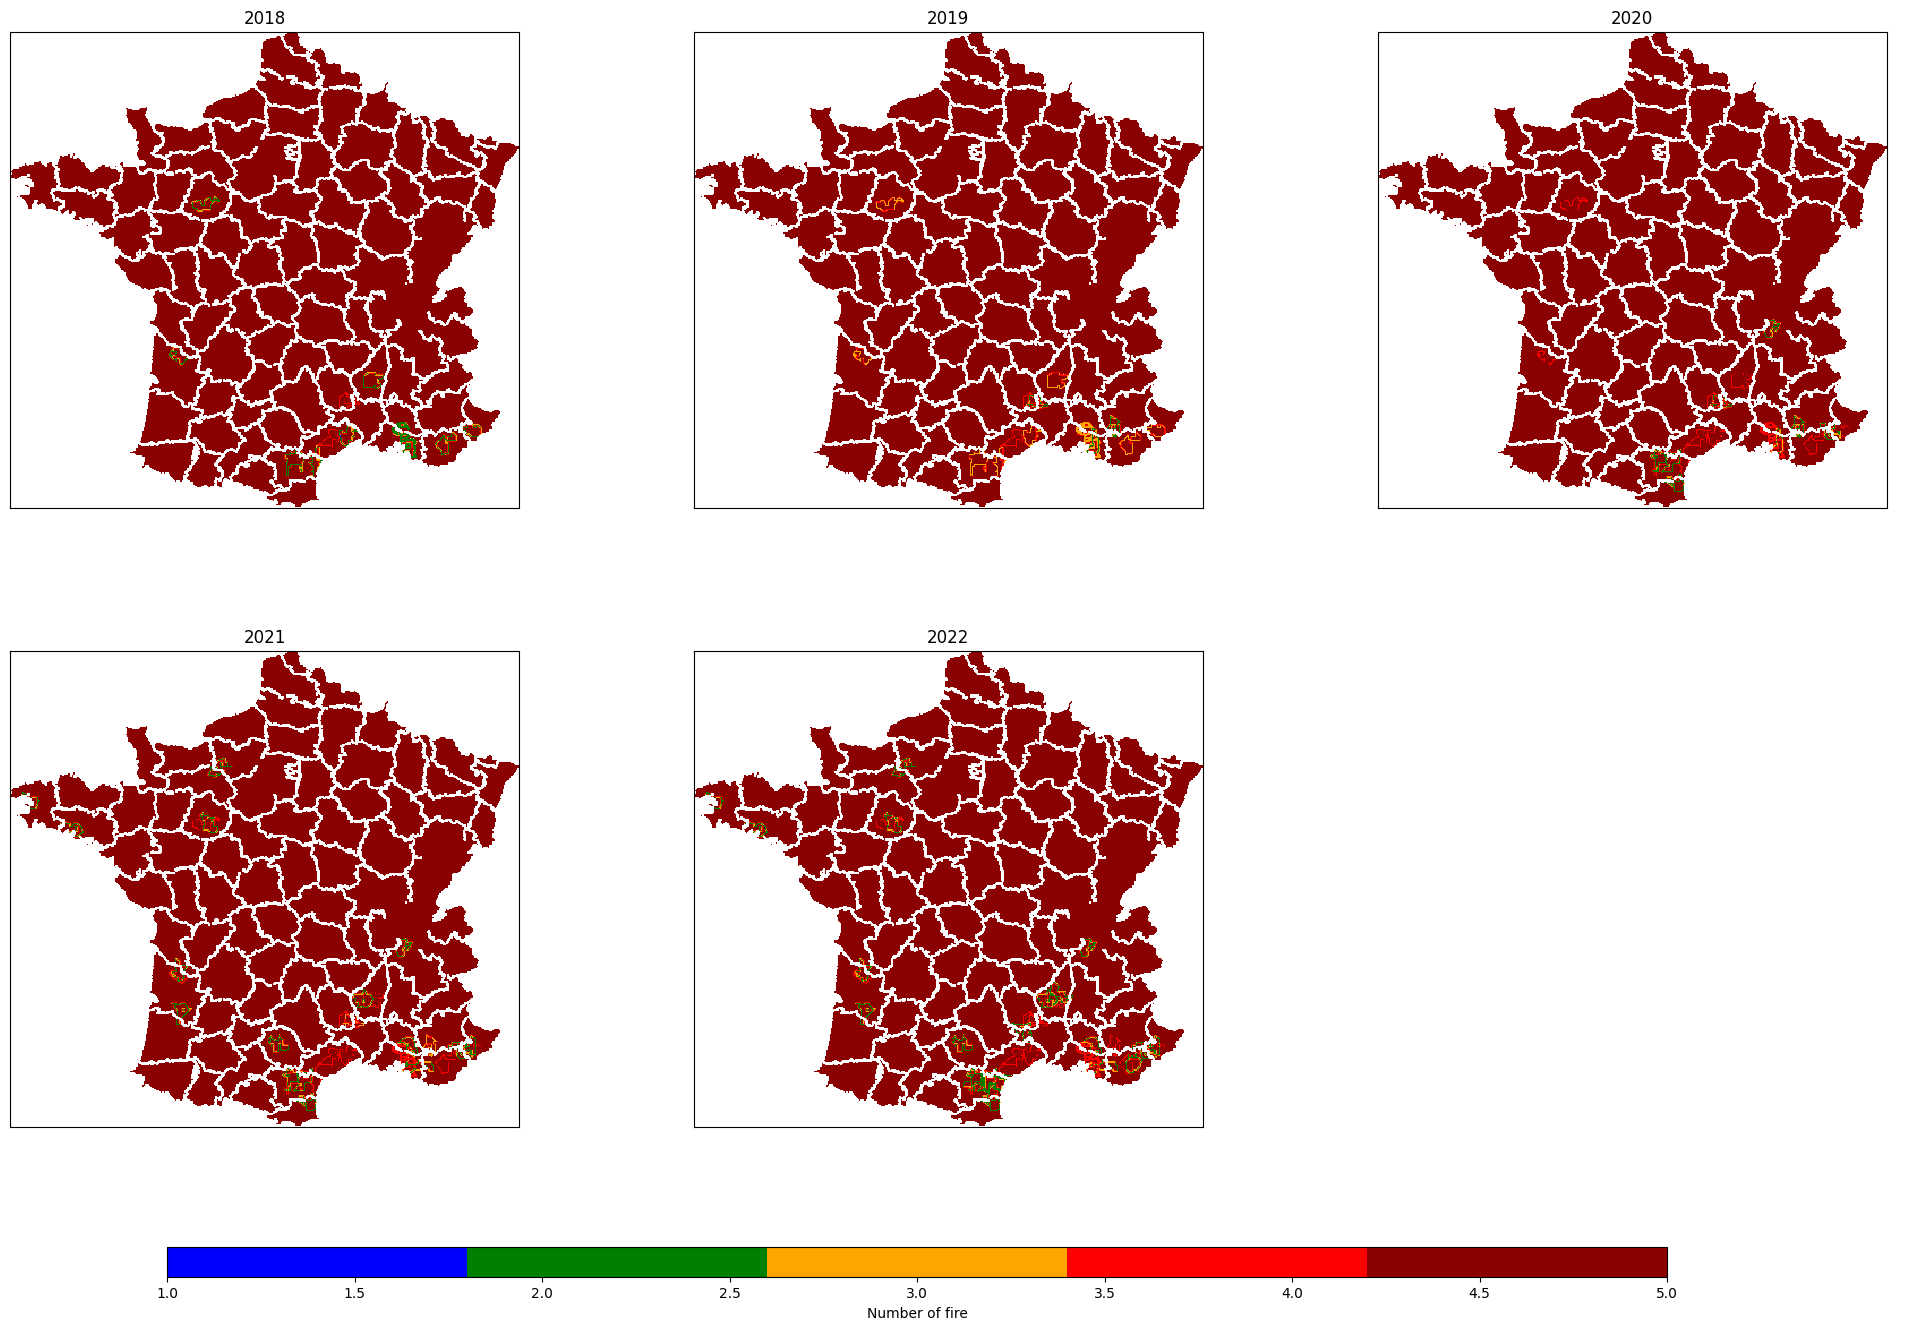

In [30]:
def fuse_burn_recovery_maps(burn_count, recovery_count):
    """
    Fusionne deux cartes de transitions en une seule carte codée :
        0 = aucun changement
        1 = brûlé uniquement
        2 = récupéré uniquement
        3 = les deux
    """
    fused_map = np.zeros(burn_count.shape, dtype=np.uint8)

    only_burn = (burn_count > 0) & (recovery_count == 0)
    only_recovery = (burn_count == 0) & (recovery_count > 0)
    both = (burn_count > 0) & (recovery_count > 0)

    fused_map[only_burn] = 1
    fused_map[only_recovery] = 2
    fused_map[both] = 3

    return fused_map

def fuse_by_dominance(burn_count, recovery_count, mask, all_fire=None, never_fire=None):
    """
    Fusionne burn_count, recovery_count, all_fire et never_fire en une carte catégorielle
    selon la transition dominante.

    Valeurs :
        0 : pixel instable (au moins un changement mais aucun cas dominant)
        1 : majoritairement brûlé
        2 : majoritairement récupéré
        3 : autant brûlé que récupéré (égalité non nulle)
        4 : toujours brûlé (all_fire)
        5 : jamais brûlé (never_fire)
    """
    fused_map = np.zeros(burn_count.shape, dtype=np.float128)

    # Brûlures dominantes
    fused_map[burn_count > recovery_count] = 4

    # Récupérations dominantes
    fused_map[recovery_count > burn_count] = 2

    # Égalité non nulle
    fused_map[(burn_count == recovery_count) & (burn_count > 0)] = 3

    # Toujours brûlé
    if all_fire is not None:
        fused_map[all_fire == 1] = 5

    # Jamais brûlé
    if never_fire is not None:
        fused_map[never_fire == 1] = 1

    fused_map[mask] = np.nan
    return fused_map


from turtle import color, title
from matplotlib.colors import ListedColormap

cmap = ListedColormap([
    "blue",     # 1: jamais brûlé
    "green",    # 2: dominé par récupération
    "orange",   # 3: égalité
    "red",      # 4: dominé par brûlure
    "darkred",  # 5: toujours brûlé
])


evolution = generate_fire_dynamics_series(image_cluster, years) 

fused = [fuse_by_dominance(evolution['burns'][i], evolution['recoveries'][i], np.isnan(image_cluster[0]), evolution['always_burned'][i], evolution['never_burned'][i]) for i in range(len(image_cluster) - 1)]

title = years

plot_matches_on_images(fused, title, figsize=(25,15), cmap=cmap)


🔄 Calcul pour l’intervalle 2018 → 2019

🔄 Calcul pour l’intervalle 2018 → 2020

🔄 Calcul pour l’intervalle 2018 → 2021

🔄 Calcul pour l’intervalle 2018 → 2023


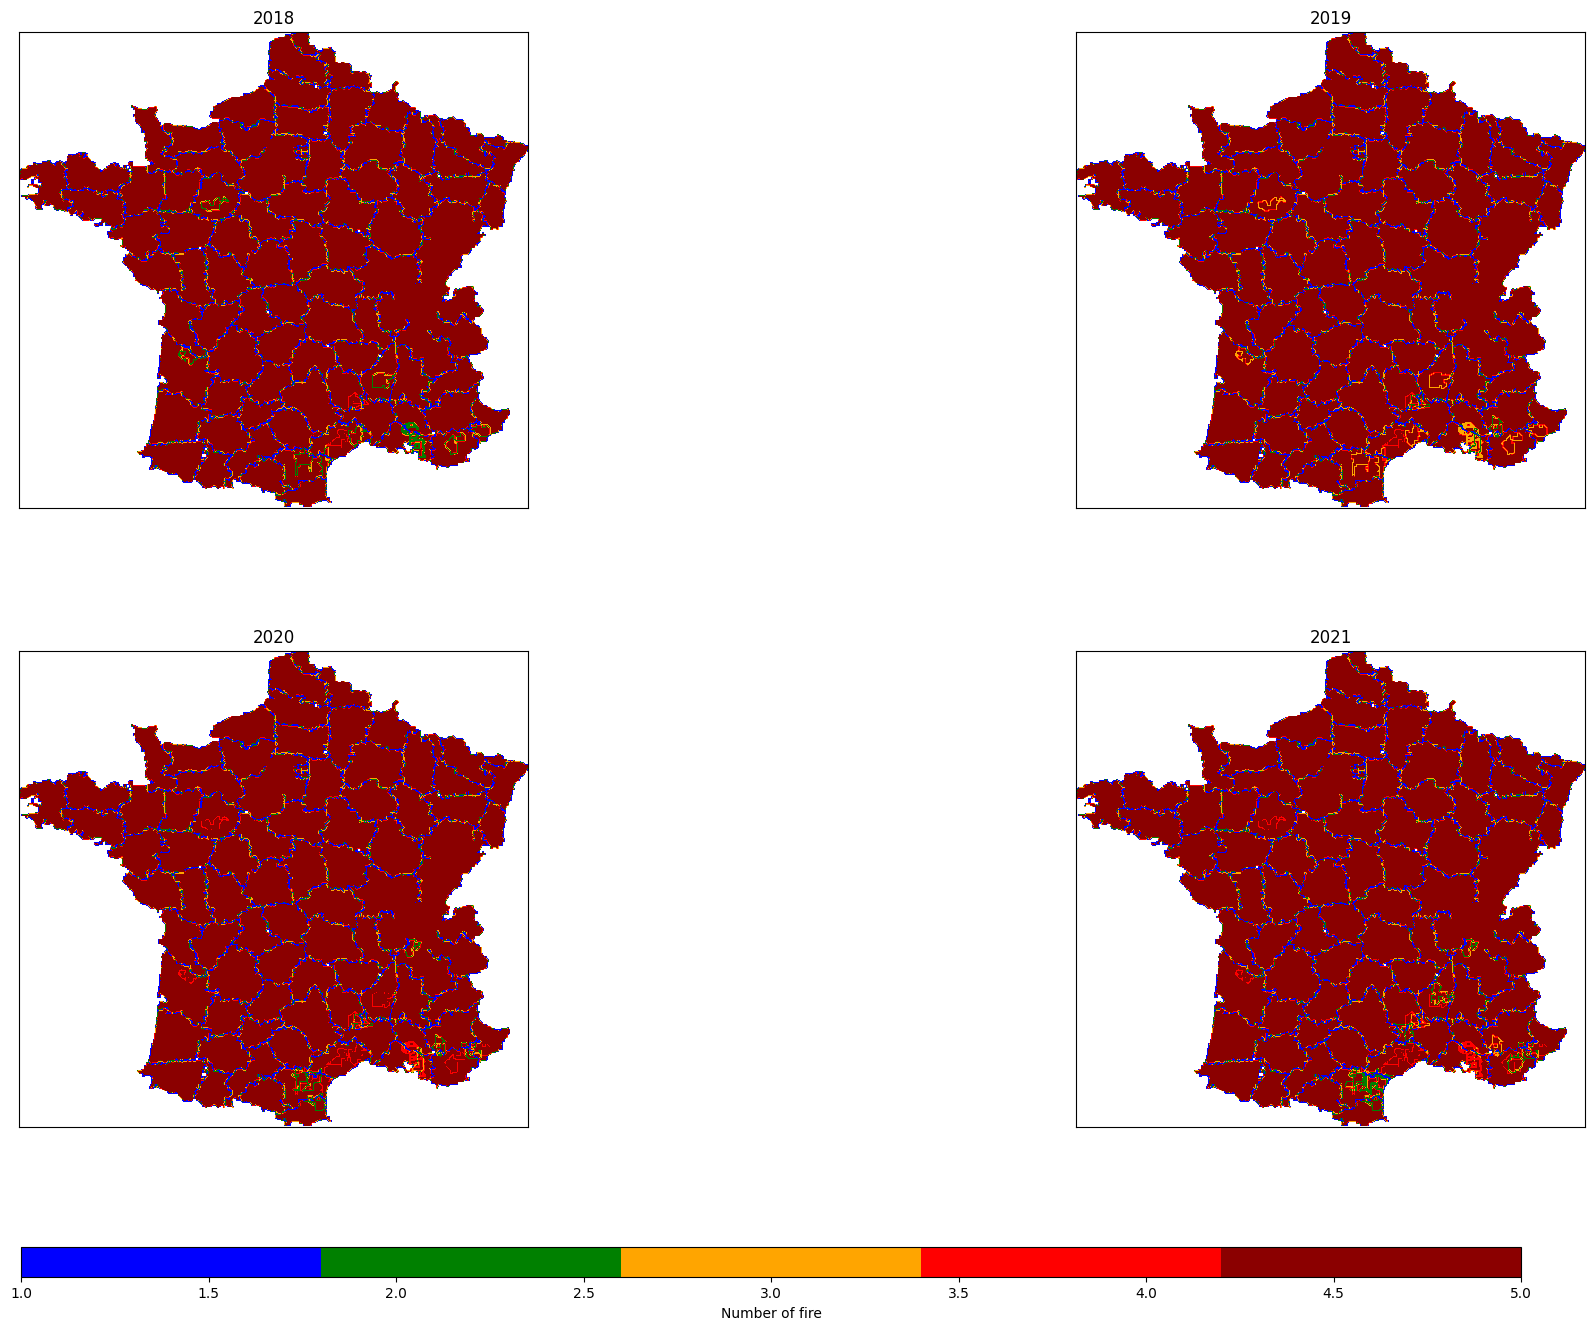

In [31]:
image_cluster_2 = []
years_2 = []

for i, year in enumerate(years):
    if year != '2022':
        image_cluster_2.append(image_cluster[i])
        years_2.append(year)


evolution_no_2022 = generate_fire_dynamics_series(image_cluster_2, years_2)

fused_no_2022 = [fuse_by_dominance(evolution_no_2022['burns'][i], evolution_no_2022['recoveries'][i], np.isnan(images_max_3[0]), evolution_no_2022['always_burned'][i], evolution_no_2022['never_burned'][i]) for i in range(len(image_cluster_2) - 1)]

title = years_2

plot_matches_on_images(fused_no_2022, title, figsize=(25,15), cmap=cmap)


🔄 Calcul pour l’intervalle 2018 → 2019

🔄 Calcul pour l’intervalle 2018 → 2020

🔄 Calcul pour l’intervalle 2018 → 2021

🔄 Calcul pour l’intervalle 2018 → 2022

🔄 Calcul pour l’intervalle 2018 → 2023


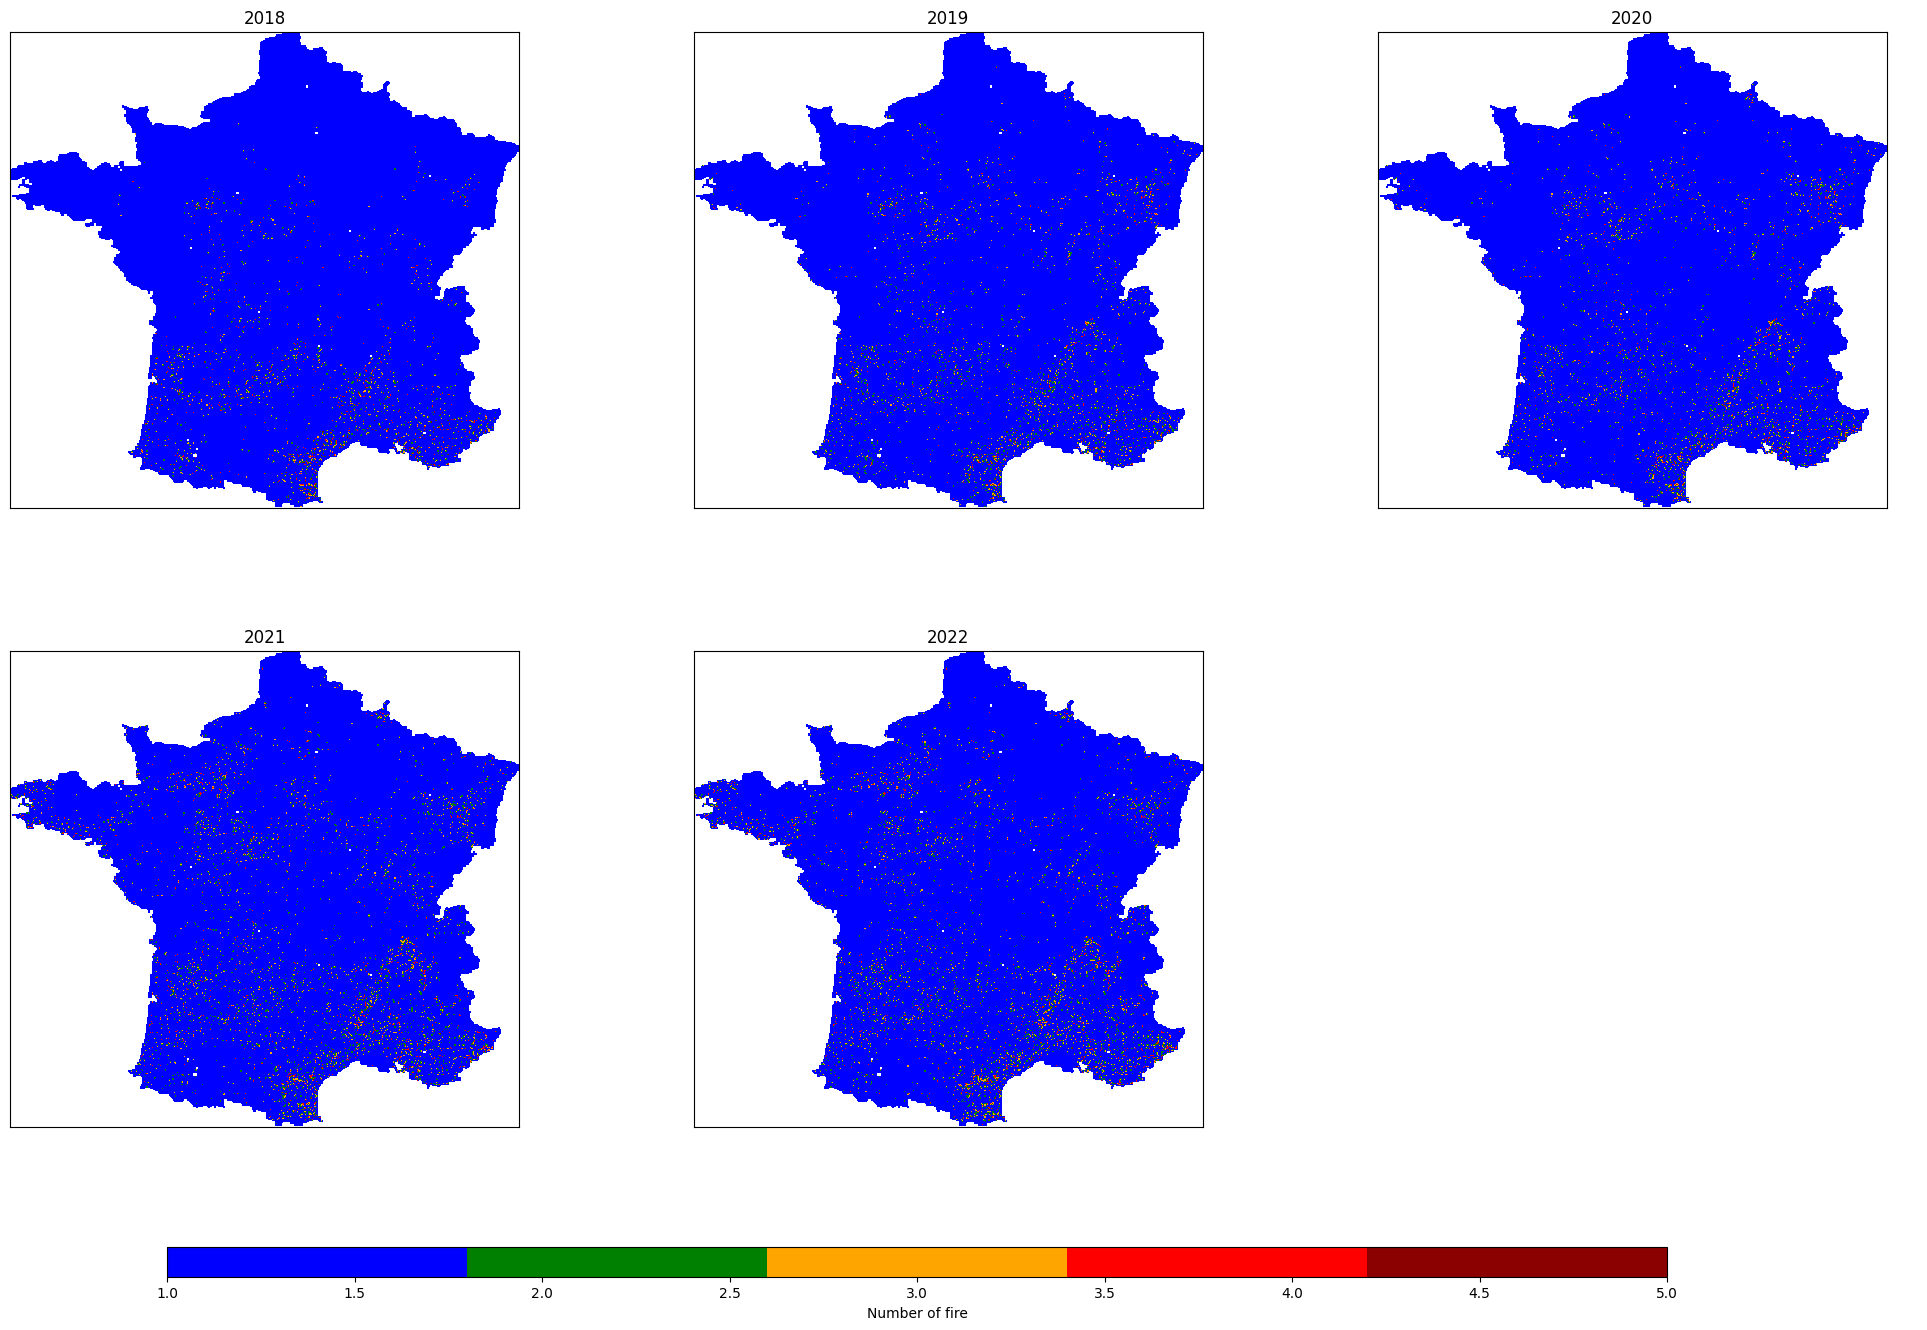

In [32]:
evolution_raw = generate_fire_dynamics_series(images, years)

fused_raw = [fuse_by_dominance(evolution_raw['burns'][i], evolution_raw['recoveries'][i], np.isnan(images_max_3[0]), evolution_raw['always_burned'][i], evolution_raw['never_burned'][i]) for i in range(len(images) - 1)]

title = years

plot_matches_on_images(fused_raw, title, figsize=(25,15), cmap=cmap)


🔄 Calcul pour l’intervalle 2018 → 2019

🔄 Calcul pour l’intervalle 2018 → 2020

🔄 Calcul pour l’intervalle 2018 → 2021

🔄 Calcul pour l’intervalle 2018 → 2022

🔄 Calcul pour l’intervalle 2018 → 2023


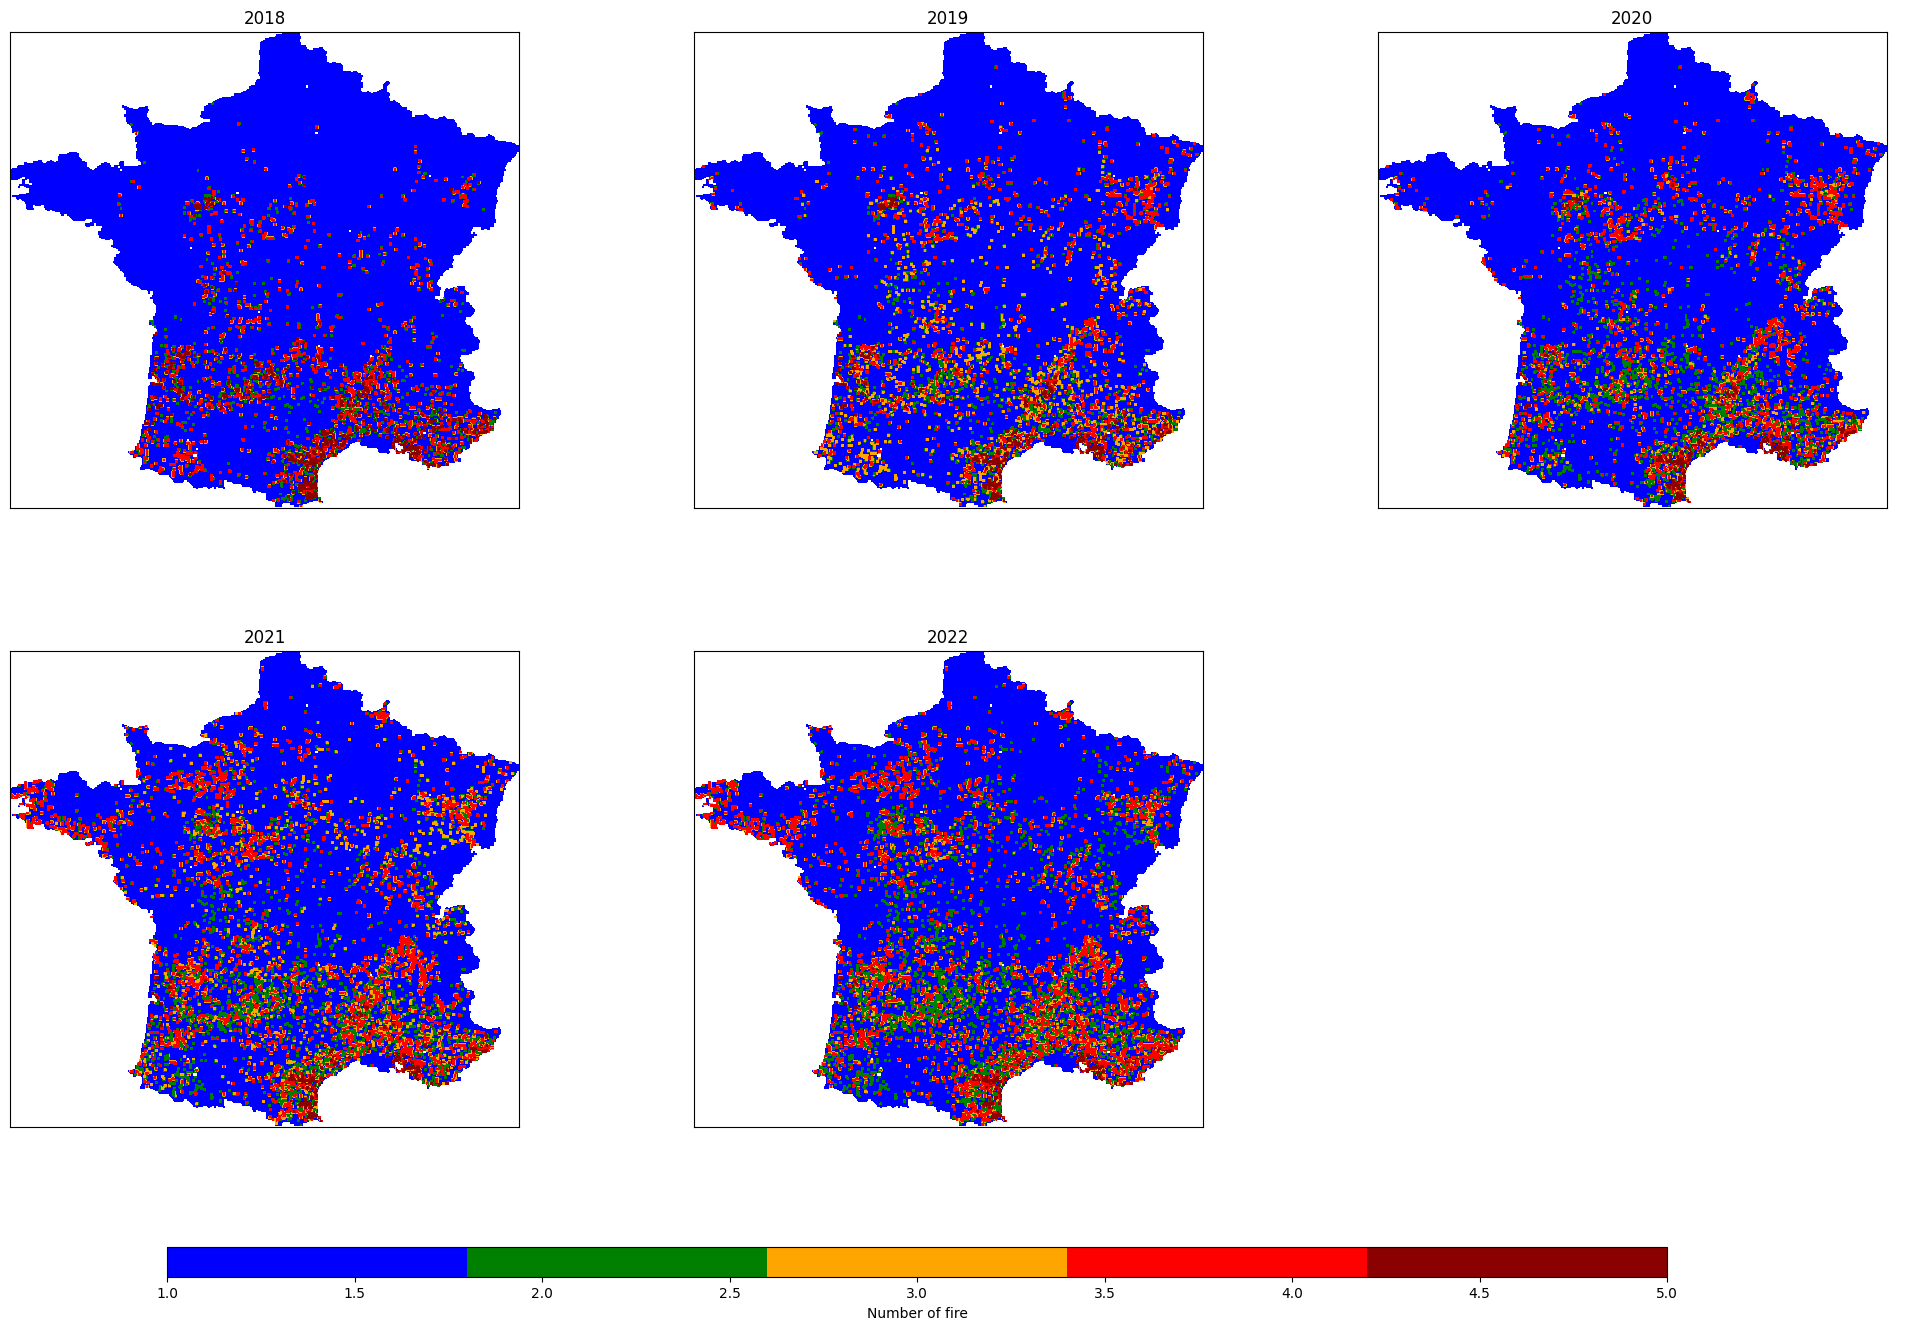

In [33]:
evolution_max_3 = generate_fire_dynamics_series(images_max_3, years)

fused_max_3 = [fuse_by_dominance(evolution_max_3['burns'][i], evolution_max_3['recoveries'][i], np.isnan(images_max_3[0]), evolution_max_3['always_burned'][i], evolution_max_3['never_burned'][i]) for i in range(len(images_max_3) - 1)]

title = years

plot_matches_on_images(fused_max_3, title, figsize=(25,15), cmap=cmap)


🔄 Calcul pour l’intervalle 2018 → 2019

🔄 Calcul pour l’intervalle 2018 → 2020

🔄 Calcul pour l’intervalle 2018 → 2021

🔄 Calcul pour l’intervalle 2018 → 2022

🔄 Calcul pour l’intervalle 2018 → 2023


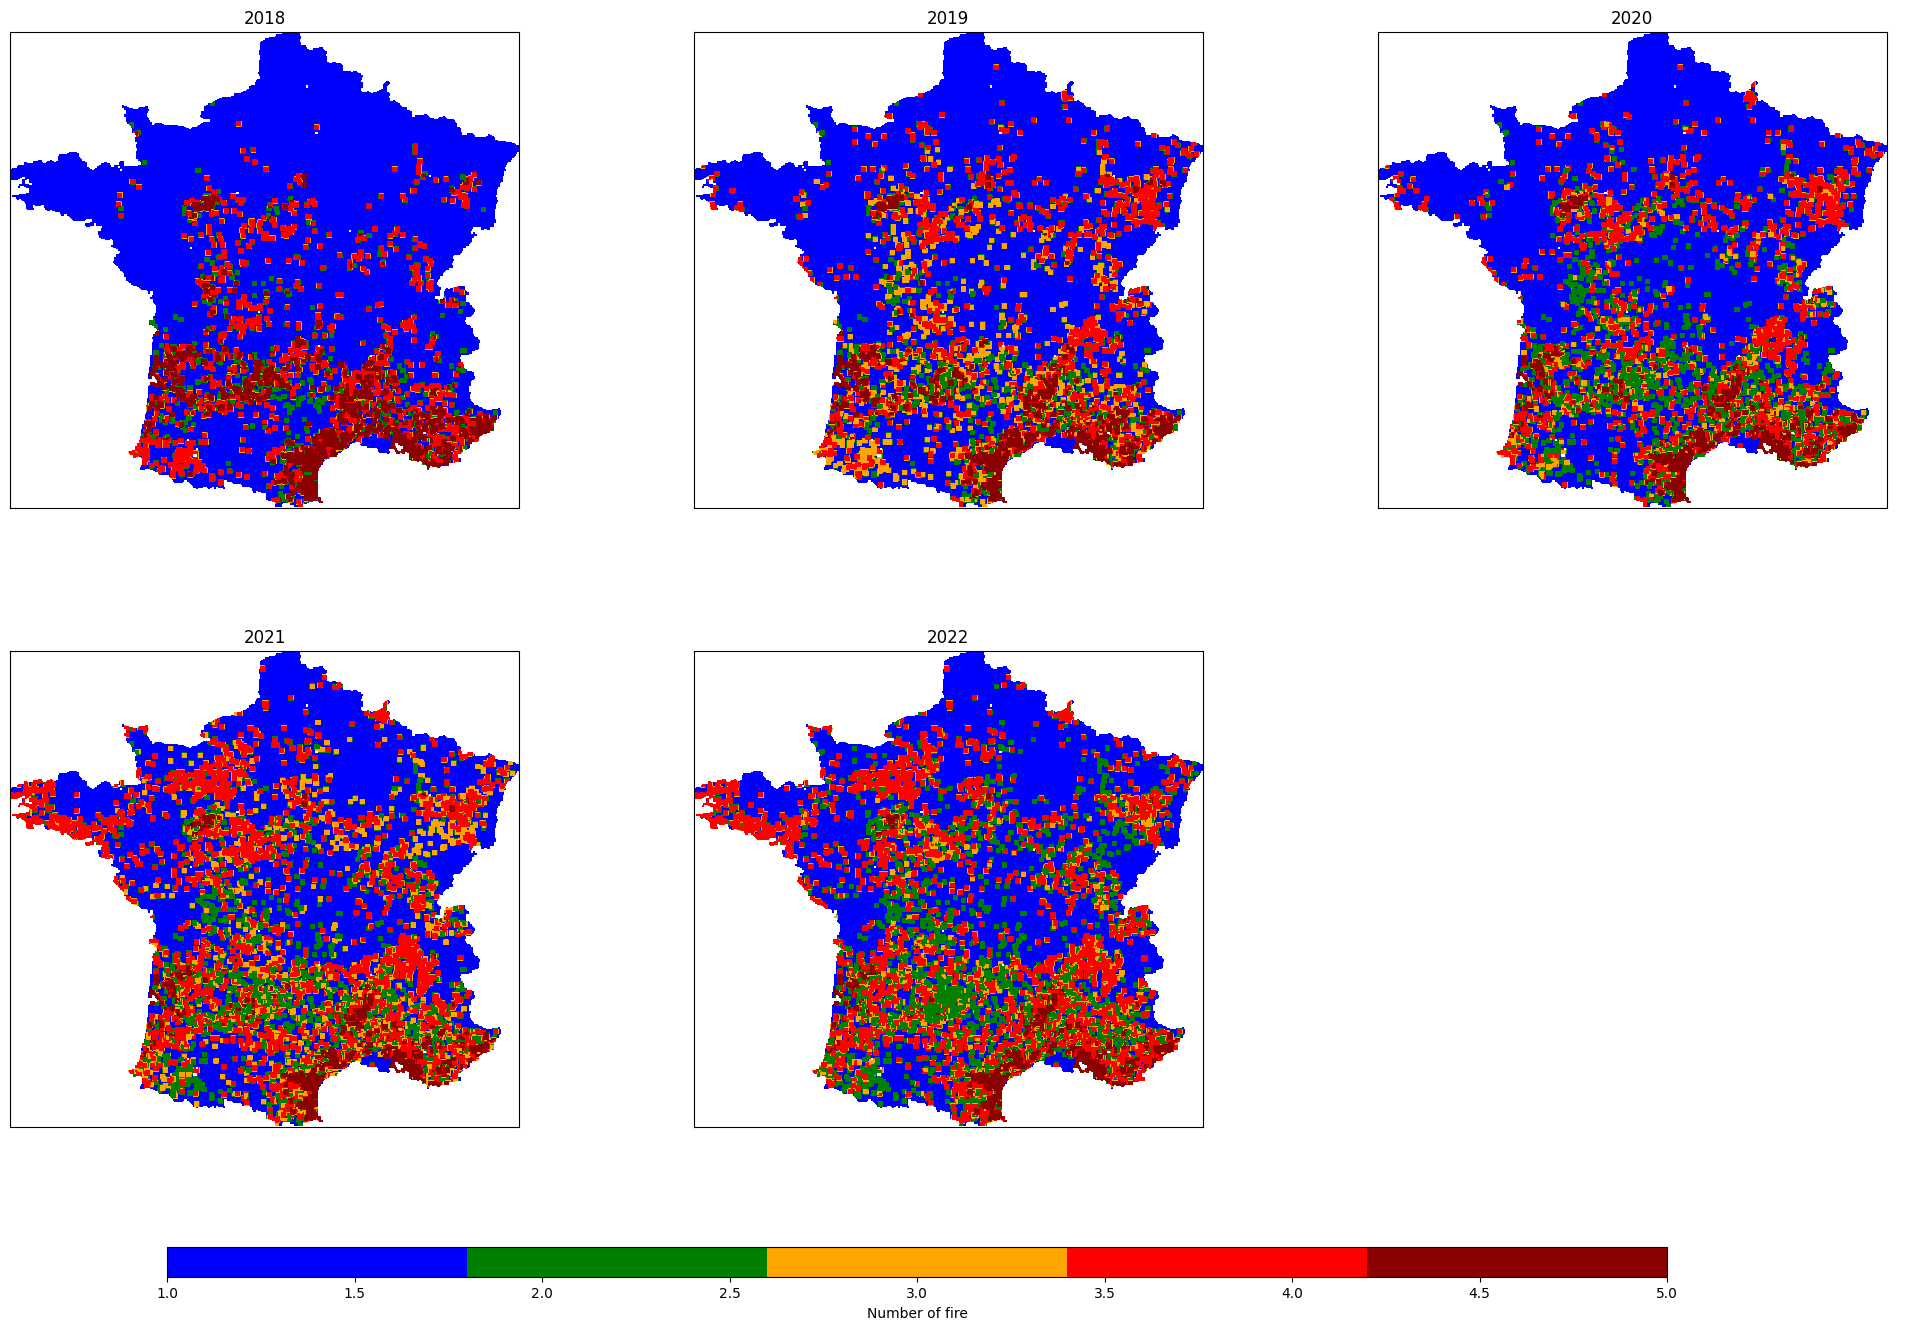

In [34]:
evolution_max_5 = generate_fire_dynamics_series(images_max_5, years)

fused_max_5 = [fuse_by_dominance(evolution_max_5['burns'][i], evolution_max_5['recoveries'][i], np.isnan(images_max_3[0]), evolution_max_5['always_burned'][i], evolution_max_5['never_burned'][i]) for i in range(len(images_max_5) - 1)]

title = years

plot_matches_on_images(fused_max_5, title, figsize=(25,15), cmap=cmap)

## With features

In [35]:
features = [
                #'temp', 'dwpt', 'rhum', 'prcp', 'wdir', 'wspd', 'prec24h',
                #'dc', 'ffmc', 'dmc', 'nesterov', 'munger', 'kbdi',
                #'isi', 'angstroem', 'bui', 'fwi', 'dailySeverityRating',
                #'temp16', 'dwpt16', 'rhum16', 'prcp16', 'wdir16', 'wspd16', 'prec24h16',
                #'days_since_rain', 'sum_consecutive_rainfall',
                #'sum_rain_last_7_days',
                #'sum_snow_last_7_days', 'snow24h', 'snow24h16',
                #'precipitationIndexN3', 'precipitationIndexN5', 'precipitationIndexN7',
                'elevation',
                'population',
                'foret',
                'osmnx',
                'cosia',
                ]

elevation_dict = {
    'elevation' : 0,
}

population_dict = {
    'population' : 1,
}

valeurs_foret_attribut = {
    'PasDeForet' : 0,
    "Châtaignier": 1,
    "Décidus": 2,
    "Sempervirents": 3,
    "Conifères": 4,
    "Douglas": 5,
    "Feuillus": 6,
    "Hêtre": 7,
    "Mélèze": 8,
    "Mixte": 9,
    "NC": 10,
    "NR": 11,
    "Crochets, Cembro": 12,
    "Pin autre": 13,
    "Pin d'Alep": 14,
    "Pin laricio, pin noir": 15,
    "Pin maritime": 16,
    "Pin sylvestre": 17,
    "Pins mélangés": 18,
    "Peuplier": 19,
    "Robinier": 20,
    "Sapin, épicéa": 21
}

osmnxstr2int = {
    'PasDeRoute': 0,
    'motorway': 1,
    'primary': 2,
    'secondary': 3,
    'tertiary': 4,
    'path': 5
}

valeurs_cosia_couverture = {
    'Other' : 0,
    'Building': 1,
    'Bare soil': 2,
    'Water surface': 3,
    'Conifer': 4,
    'Deciduous': 5,
    'Shrubland': 6,
    'Lawn': 7,
    'Crop': 8,
}

# Tous tes dictionnaires sources
dictionaries = {
    "elevation": elevation_dict,
    "population": population_dict,
    "foret": valeurs_foret_attribut,
    "routes": osmnxstr2int,
    "couverture": valeurs_cosia_couverture
}

# Ordre voulu
ordered_sources = [
    ("elevation", elevation_dict),
    ("population", population_dict),
    ("foret", valeurs_foret_attribut),
    ("routes", osmnxstr2int),
    ("couverture", valeurs_cosia_couverture),
]

# Fusion avec indexation respectant l'ordre
final_dict = {}
index = 0

for prefix, d in ordered_sources:
    for key in d:
        final_dict[f"{key}"] = index
        index += 1
    
final_dict

{'elevation': 0,
 'population': 1,
 'PasDeForet': 2,
 'Châtaignier': 3,
 'Décidus': 4,
 'Sempervirents': 5,
 'Conifères': 6,
 'Douglas': 7,
 'Feuillus': 8,
 'Hêtre': 9,
 'Mélèze': 10,
 'Mixte': 11,
 'NC': 12,
 'NR': 13,
 'Crochets, Cembro': 14,
 'Pin autre': 15,
 "Pin d'Alep": 16,
 'Pin laricio, pin noir': 17,
 'Pin maritime': 18,
 'Pin sylvestre': 19,
 'Pins mélangés': 20,
 'Peuplier': 21,
 'Robinier': 22,
 'Sapin, épicéa': 23,
 'PasDeRoute': 24,
 'motorway': 25,
 'primary': 26,
 'secondary': 27,
 'tertiary': 28,
 'path': 29,
 'Other': 30,
 'Building': 31,
 'Bare soil': 32,
 'Water surface': 33,
 'Conifer': 34,
 'Deciduous': 35,
 'Shrubland': 36,
 'Lawn': 37,
 'Crop': 38}

[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18.
 19. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 33. 34. 35. 36. 37.
 38. 39. 40. 41. 42. 43. 44. 45. 46. 47. 48. 49. 50. 51. 52. 53. 54. 55.
 56. 57. 58. 59. 60. 61. 62. 63. 64. 65. 66. 67. 68. 69. 70. 71. 72. 73.
 74. 75. 76. 77. 78. 79. 80. 81. 82. 83. 84. 85. 86. 87. 88. 89. 90. 91.
 92. 93. 94. 95. nan]


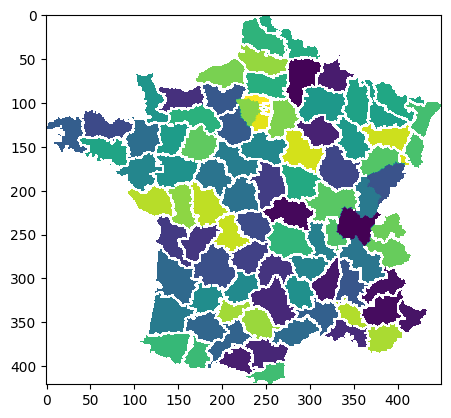

In [36]:
departement_mask = read_object('departement.pkl', dir_output)[0]
print(np.unique(departement_mask))
plt.imshow(departement_mask)

In [37]:
import numpy as np
from scipy.stats import pearsonr

from scipy.stats import pearsonr, spearmanr
import numpy as np

def pearson_spearman_correlation_with_map(channels_array, target_map):
    """
    Calcule les corrélations de Pearson et Spearman entre chaque bande et une carte cible.

    Paramètres :
        channels_array (np.ndarray): Array de shape (channels, H, W)
        target_map (np.ndarray): Array de shape (H, W)

    Retourne :
        pearson_corr (np.ndarray): Corrélations de Pearson, shape (channels,)
        spearman_corr (np.ndarray): Corrélations de Spearman, shape (channels,)
    """
    C, H, W = channels_array.shape
    flat_target = target_map.flatten()
    pearson_corr = []
    spearman_corr = []

    for i in range(C):
        flat_channel = channels_array[i].flatten()

        # Masque pour éviter les NaN
        mask = ~np.isnan(flat_channel) & ~np.isnan(flat_target)

        if np.sum(mask) > 0:
            p, _ = pearsonr(flat_channel[mask], flat_target[mask])
            s, _ = spearmanr(flat_channel[mask], flat_target[mask])
        else:
            p = np.nan
            s = np.nan

        pearson_corr.append(p)
        spearman_corr.append(s)

    return np.array(pearson_corr), np.array(spearman_corr)

import matplotlib.pyplot as plt
import numpy as np
import math

def plot_correlation_grid(
    corr_vector_list,
    feature_band_dict,
    targets,
    colors,
    title="Corrélations de Pearson par target",
    figsize=(15, 10),
    n_cols=3
):
    """
    Affiche une grille de barplots de corrélation (1 subplot par target),
    et log les 3 features les plus corrélées (positives ou négatives).

    Paramètres :
        corr_vector_list (list of np.ndarray): Liste des vecteurs de corrélations (un par target)
        feature_band_dict (dict): {nom_feature: index_bande}
        targets (list of str): noms des targets (même ordre que les vecteurs)
        colors (list of str): couleurs des barres pour chaque target
        title (str): Titre général
        figsize (tuple): Taille de la figure
        n_cols (int): Nombre de colonnes dans la grille
    """
    feature_names = list(feature_band_dict.keys())
    feature_indices = list(feature_band_dict.values())
    n_targets = len(targets)
    n_features = len(feature_names)

    n_rows = math.ceil(n_targets / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, squeeze=False)
    axes = axes.flatten()

    for i, (corr_vector, target, color) in enumerate(zip(corr_vector_list, targets, colors)):
        ax = axes[i]
        corrs = []

        for band_name in feature_names:
            band_idx = feature_band_dict[band_name]
            val = corr_vector[band_idx] if band_idx < len(corr_vector) else np.nan
            corrs.append(val)

         # Convertir et filtrer les NaN
        corrs_np = np.array(corrs)
        valid_indices = np.where(~np.isnan(corrs_np))[0]

        if len(valid_indices) == 0:
            print(f"\n📊 Target '{target}': aucune corrélation valide.")
        else:
            sorted_valid = valid_indices[np.argsort((corrs_np[valid_indices]))[::-1]]
            top_indices = sorted_valid[:3]

            print(f"\n📊 Top 3 corrélations pour target '{target}':")
            for rank, idx in enumerate(top_indices, 1):
                feature = feature_names[idx]
                value = corrs_np[idx]
                print(f"   {rank}. {feature:20s} → corr = {value:.3f}")

        # Affichage du plot
        ax.bar(feature_names, corrs, color=color, edgecolor='black')
        ax.set_title(target)
        ax.axhline(0, color='black', linewidth=0.8)
        ax.set_xticks(range(n_features))
        ax.set_xticklabels(feature_names, rotation=85, ha='right')
        ax.grid(True, linestyle='--', alpha=0.5)

    # Supprimer les subplots inutilisés
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(title, fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

In [38]:
from skimage.transform import resize
import numpy as np

def resize_multiband_array(array, new_shape, preserve_dtype=True, interpolation_order=1):
    """
    Redimensionne un tableau numpy multi-bandes (H, W, C) vers une nouvelle taille, en ignorant les NaN.

    Paramètres :
        array (np.ndarray): Array d'entrée de forme (H, W, C) ou (H, W).
        new_shape (tuple): Nouvelle taille (new_height, new_width).
        preserve_dtype (bool): Si True, conserve le type original.
        interpolation_order (int): 0=nearest, 1=bilinear, etc.

    Retourne :
        np.ndarray: Array redimensionné à shape (new_height, new_width[, C]).
    """
    original_dtype = array.dtype
    new_height, new_width = new_shape

    def resize_ignore_nan(band):
        nan_mask = np.isnan(band)
        filled = np.copy(band)
        filled[nan_mask] = 0  # ou band[~nan_mask].mean() si tu veux interpoler sur moyenne

        resized_band = resize(filled, (new_height, new_width), order=interpolation_order,
                              preserve_range=True, anti_aliasing=False)

        # Resize du masque (valeurs entre 0 et 1)
        resized_mask = resize(~nan_mask, (new_height, new_width), order=0,
                              preserve_range=True, anti_aliasing=False)

        # Remettre les NaN là où le masque est nul
        resized_band[resized_mask < 0.5] = np.nan
        return resized_band

    if array.ndim == 2:
        resized = resize_ignore_nan(array)
    elif array.ndim == 3:
        bands = [resize_ignore_nan(array[:, :, i]) for i in range(array.shape[2])]
        resized = np.stack(bands, axis=2)
    else:
        raise ValueError("L'array doit être en 2D ou 3D (H, W, C)")

    if preserve_dtype:
        resized = resized.astype(original_dtype)

    resized[np.isnan(resized)] = 0
    return resized

In [39]:
from dico_departements import *
from skimage.transform import resize
import numpy as np
from pathlib import Path

def load_features(departement_mask, features):
    res = []
    H, W = departement_mask.shape
    unique_departements = np.unique(departement_mask[~np.isnan(departement_mask)])

    root_data_disk = Path('/media/caron/X9 Pro/travaille/Thèse/csv')

    for feature in features:
        france_feature = None

        for departement in unique_departements:
            dir_raster = root_data_disk / int2name[int(departement)] / 'raster' / '2x2'
            data_features = read_object(f'{feature}.pkl', dir_raster)

            # S'assurer que les données ont la forme (bands, h, w)
            if data_features.ndim == 2:
                data_features = data_features[np.newaxis, ...]  # (1, h, w)

            n_bands = data_features.shape[0]

            if france_feature is None:
                france_feature = np.full((n_bands, H, W), fill_value=np.nan)

            # Créer un masque binaire pour ce département
            mask = (departement_mask == departement)

            # Redimensionner chaque bande vers la taille du mask national
            for i in range(n_bands):
                band = data_features[i]
                resized_band = resize_multiband_array(band, (H, W))
                france_feature[i][mask] = resized_band[mask]

        res.append(france_feature)

    return np.concatenate(res, axis=0).astype(np.float32)  # Shape: (total_bands, H, W)

features_array = load_features(departement_mask, features)

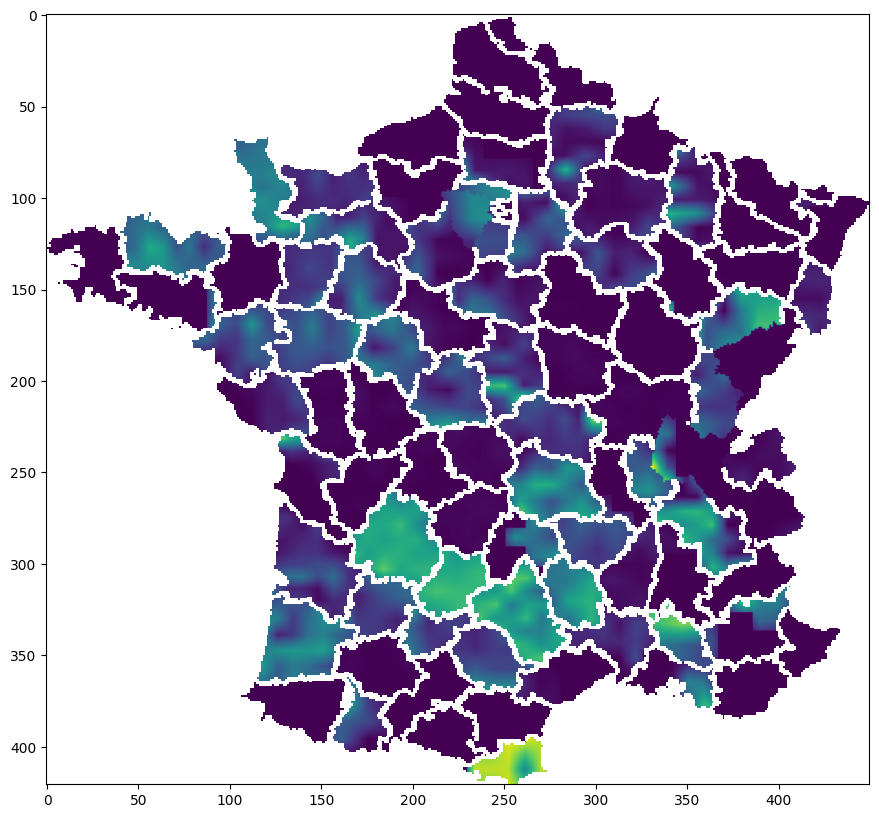

In [40]:
plt.figure(figsize=(15,10))
plt.imshow(features_array[35])

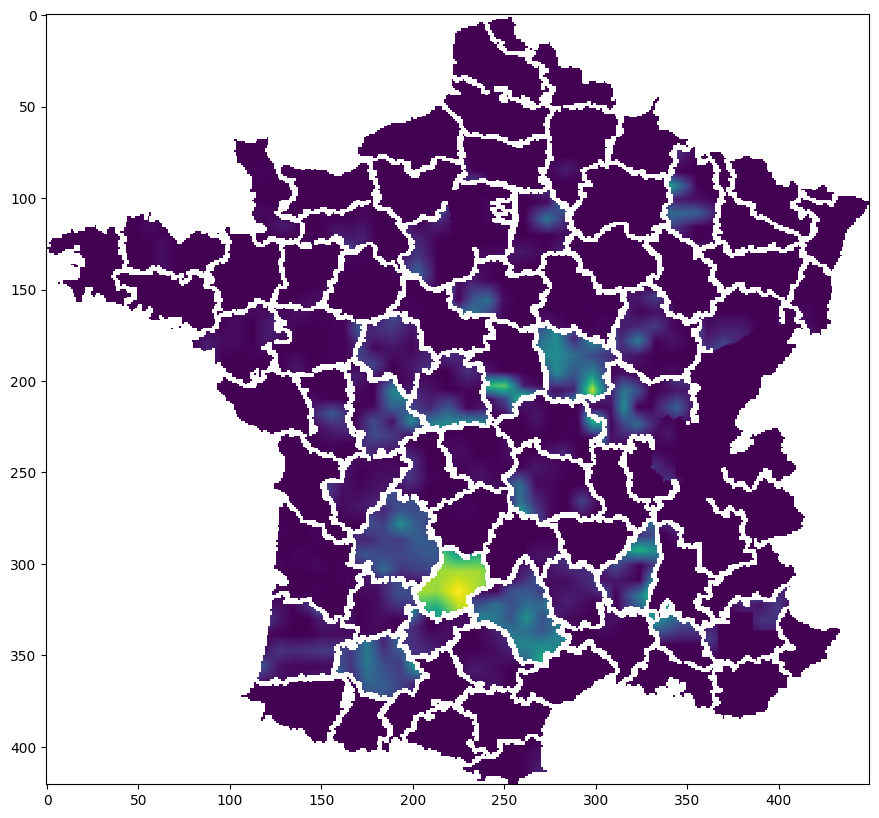

In [41]:
plt.figure(figsize=(15,10))
plt.imshow(features_array[4])

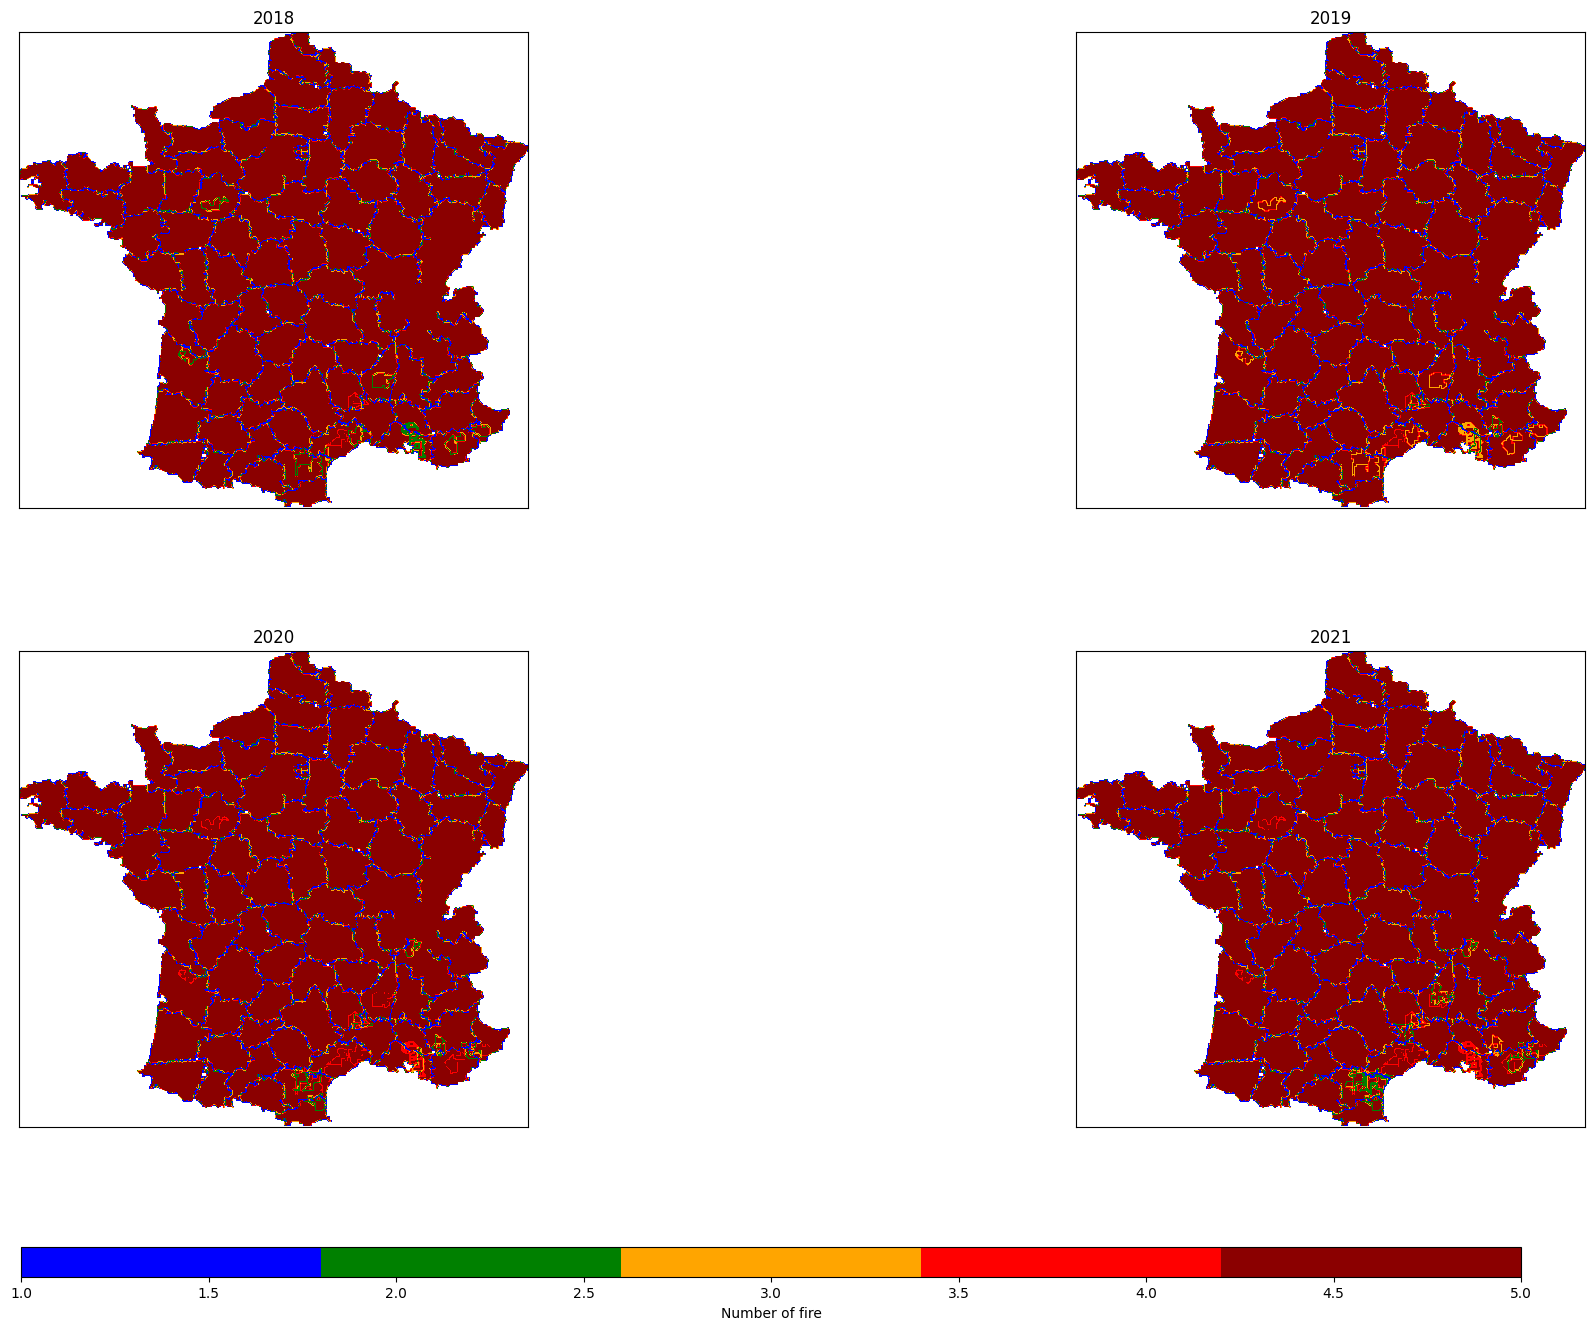

In [42]:
fused_test = fused_no_2022
plot_matches_on_images(fused_test, title, figsize=(25,15), cmap=cmap)

## Correlation

In [43]:
fused_test = fused_max_5
targets = fused_test[-1] - 1

/tmp/ipykernel_8009/368538109.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  p, _ = pearsonr(flat_channel[mask], flat_target[mask])
/tmp/ipykernel_8009/368538109.py:32: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  s, _ = spearmanr(flat_channel[mask], flat_target[mask])



📊 Top 3 corrélations pour target '1':
   1. Décidus              → corr = 0.173
   2. Deciduous            → corr = 0.111
   3. Feuillus             → corr = 0.070

📊 Top 3 corrélations pour target '2':
   1. Mixte                → corr = 0.059
   2. Conifer              → corr = 0.054
   3. Sapin, épicéa        → corr = 0.053

📊 Top 3 corrélations pour target '3':
   1. Sapin, épicéa        → corr = 0.053
   2. path                 → corr = 0.052
   3. Conifer              → corr = 0.052

📊 Top 3 corrélations pour target '4':
   1. Châtaignier          → corr = 0.163
   2. Pin d'Alep           → corr = 0.120
   3. Pin maritime         → corr = 0.113

📊 Target '5': aucune corrélation valide.


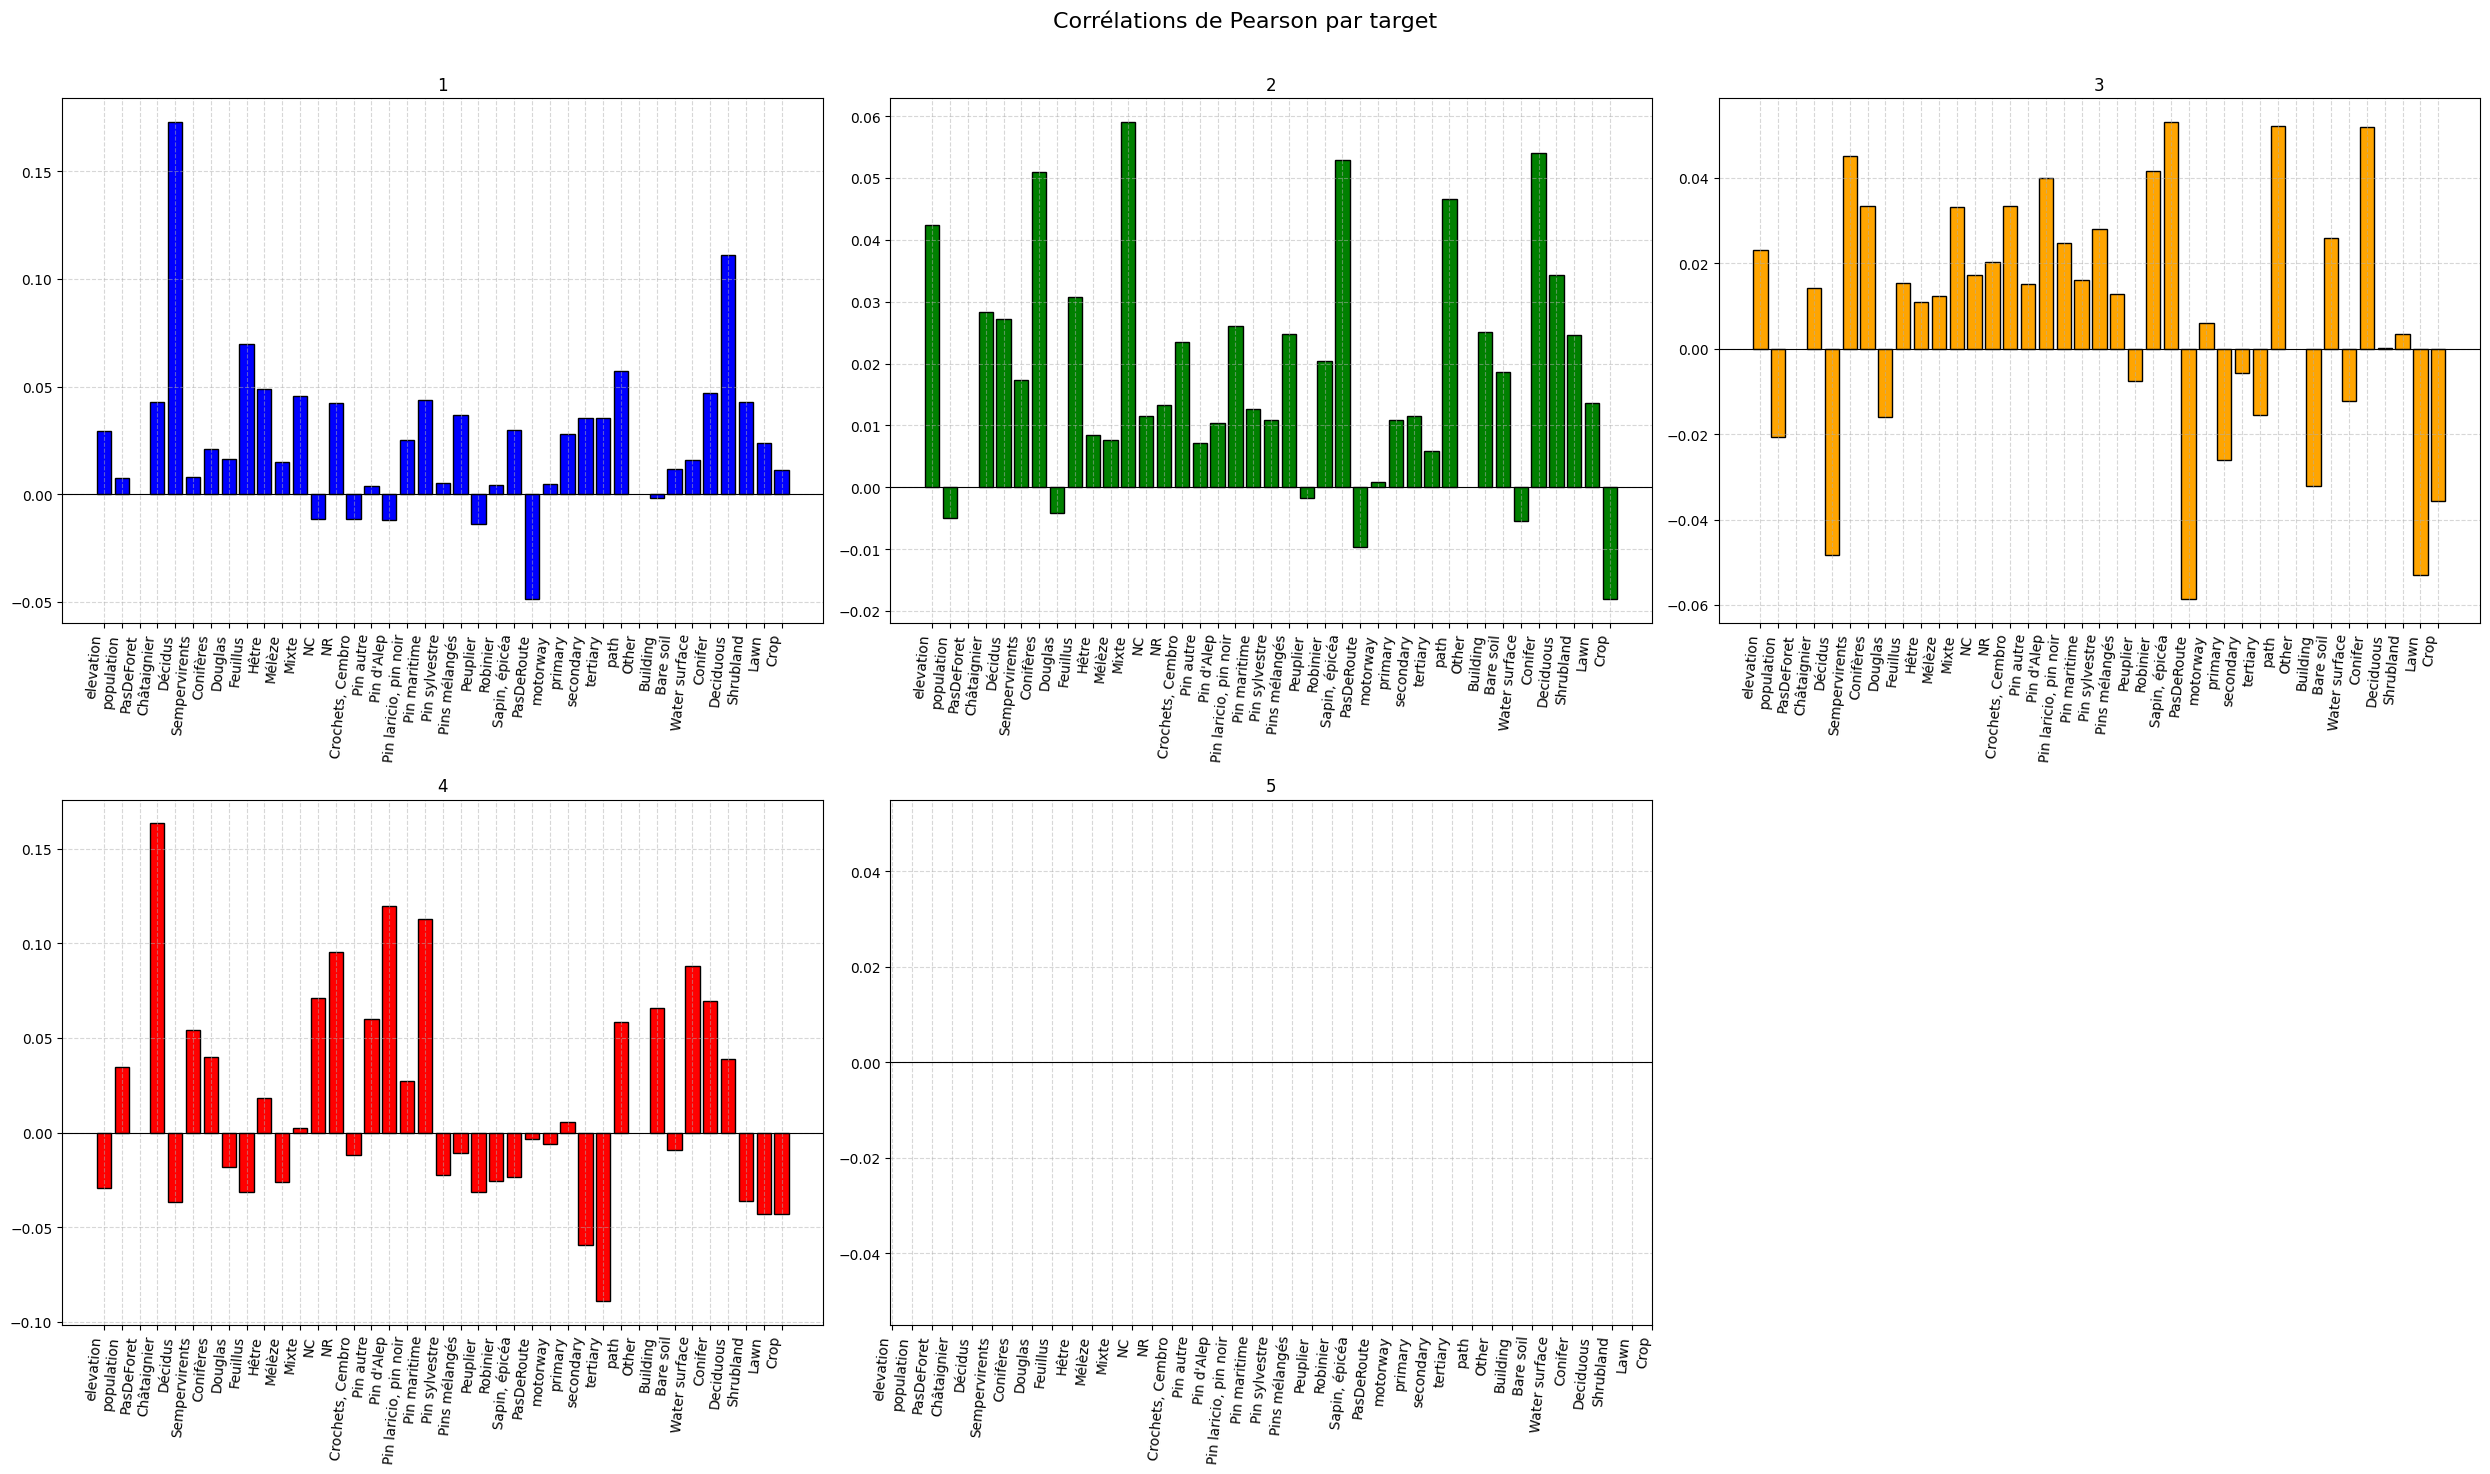

In [44]:
correlations_list = np.asarray([pearson_spearman_correlation_with_map(features_array, targets == i) for i in range(1, 6)])
plot_correlation_grid(correlations_list[:, 0], final_dict, [1, 2, 3, 4, 5], ['blue', 'green', 'orange', 'red', 'darkred'], figsize=(25, 15))


📊 Top 3 corrélations pour target '1':
   1. Décidus              → corr = 0.141
   2. Conifer              → corr = 0.125
   3. Mixte                → corr = 0.121

📊 Top 3 corrélations pour target '2':
   1. Mixte                → corr = 0.084
   2. Conifer              → corr = 0.084
   3. elevation            → corr = 0.062

📊 Top 3 corrélations pour target '3':
   1. Robinier             → corr = 0.064
   2. Sempervirents        → corr = 0.062
   3. NC                   → corr = 0.061

📊 Top 3 corrélations pour target '4':
   1. Pin d'Alep           → corr = 0.246
   2. Pin autre            → corr = 0.114
   3. Sempervirents        → corr = 0.090

📊 Target '5': aucune corrélation valide.


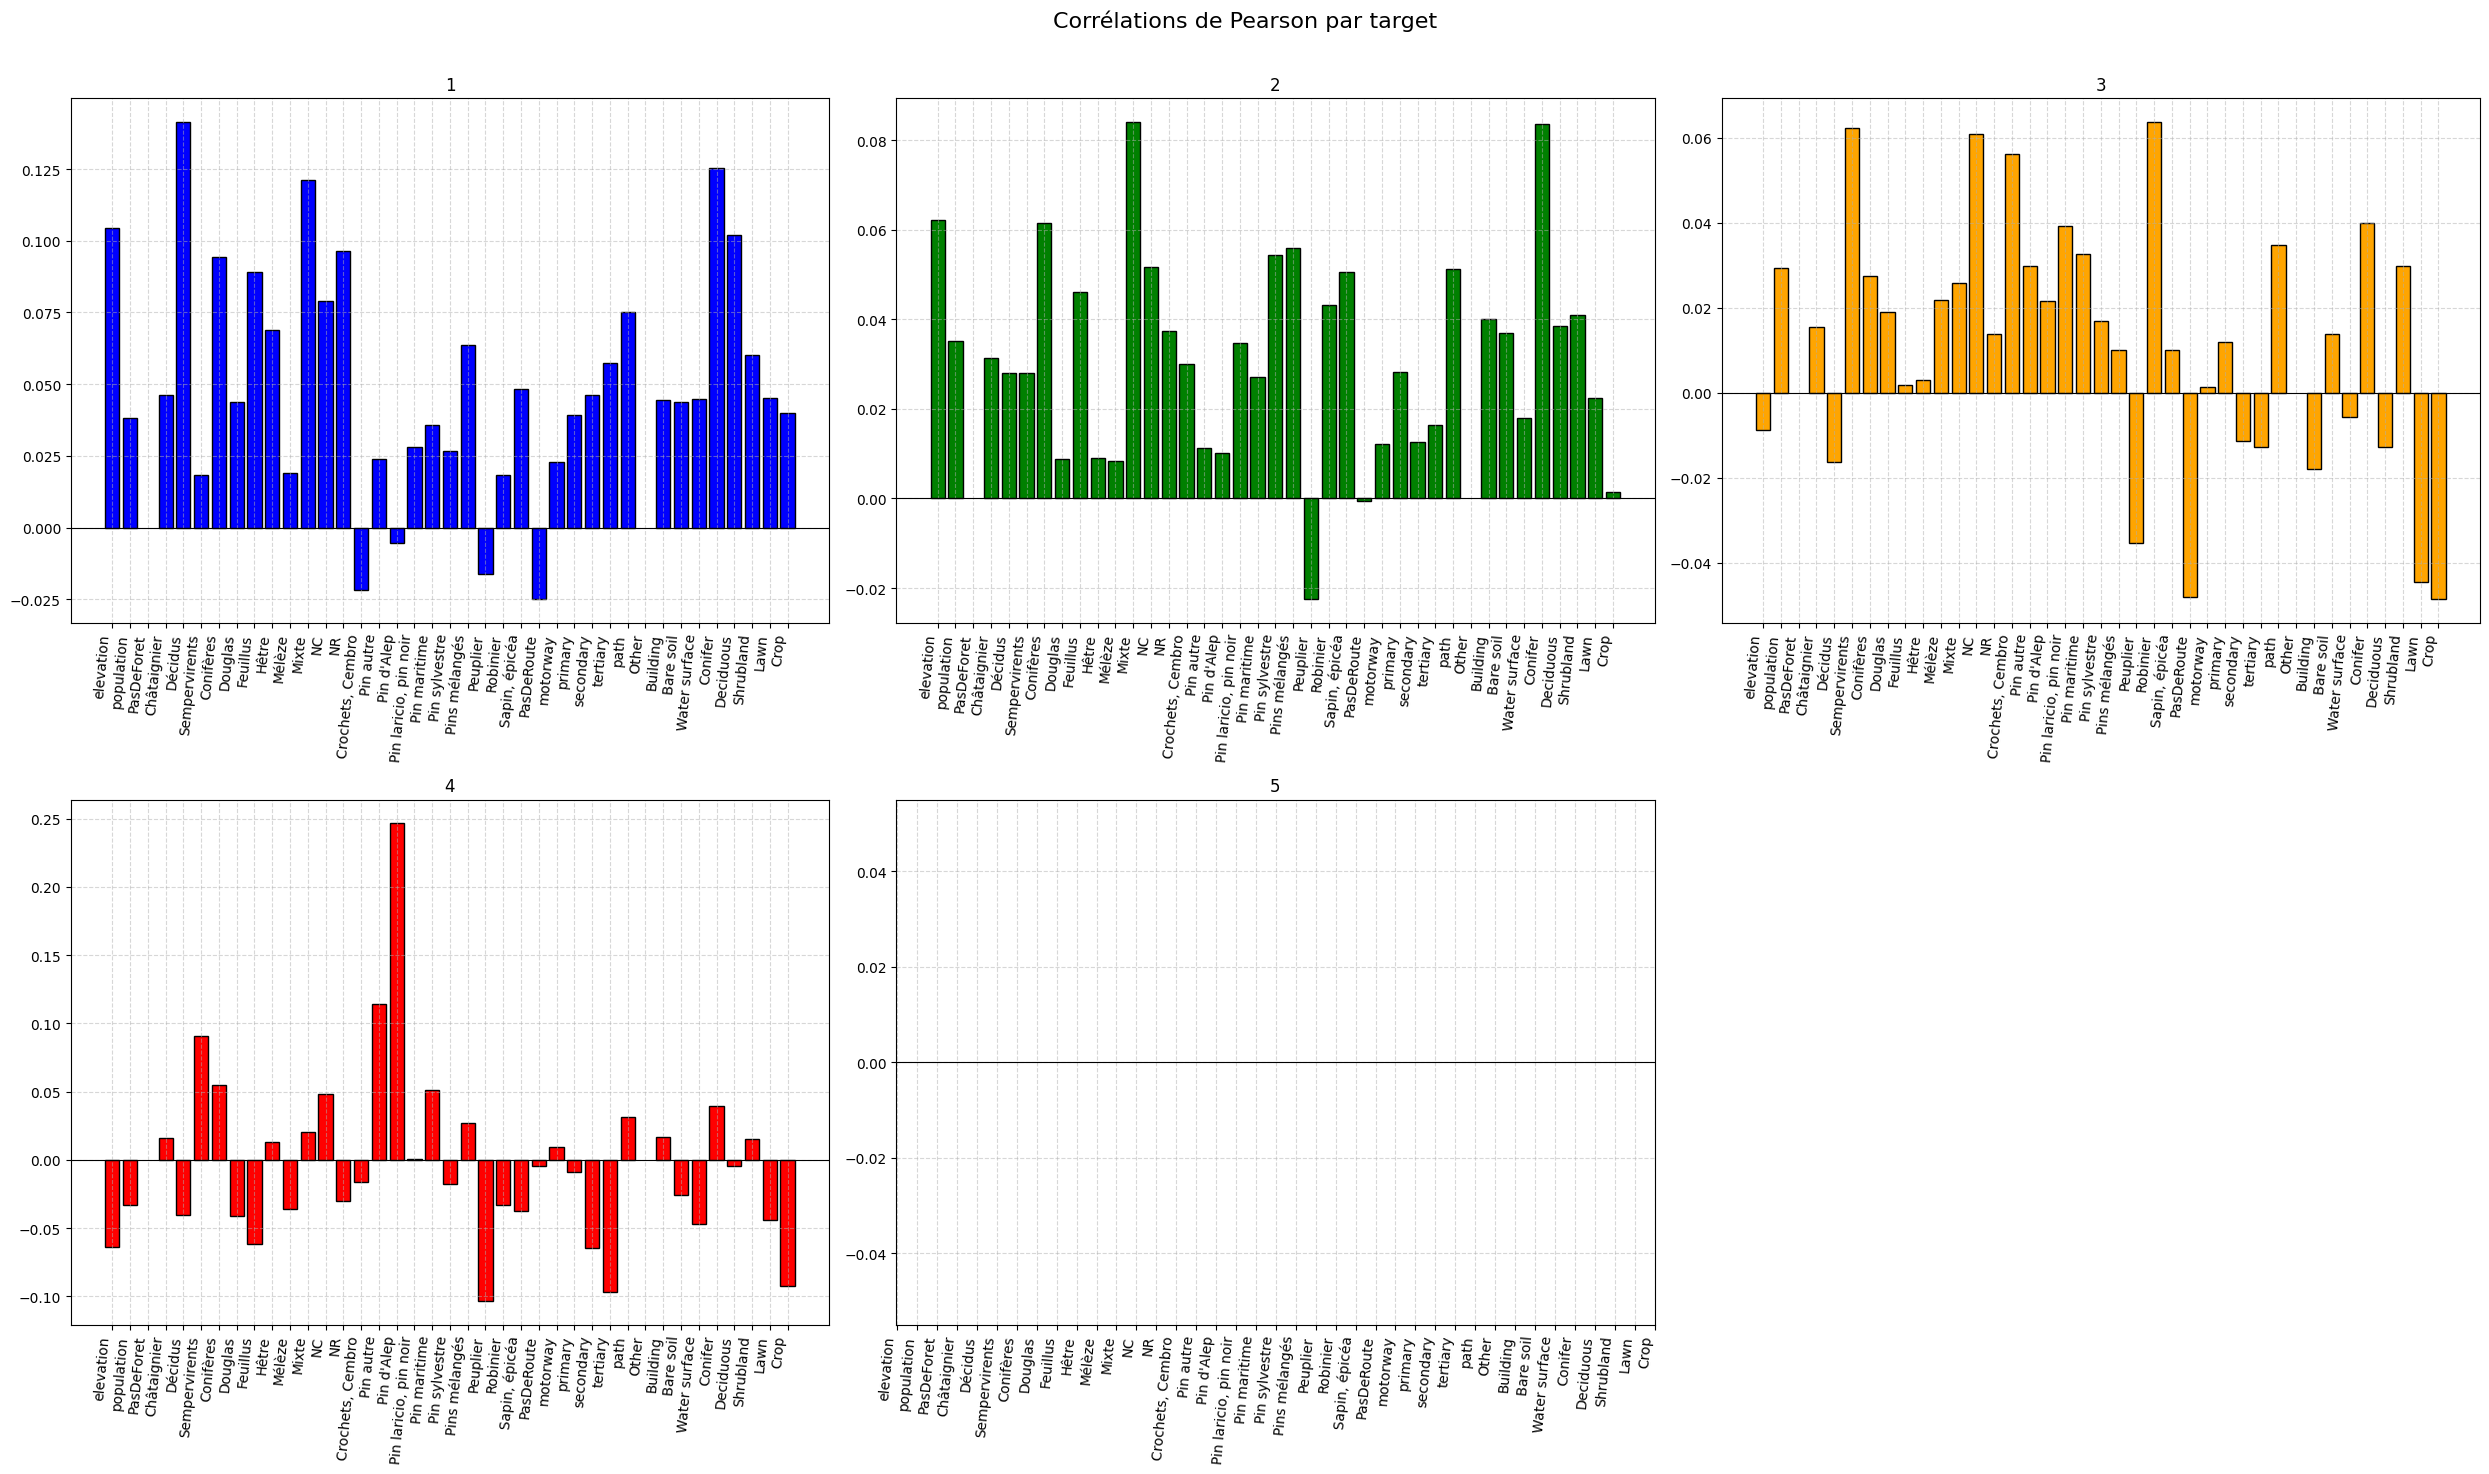

In [45]:
plot_correlation_grid(correlations_list[:, 1], final_dict, [1, 2, 3, 4, 5], ['blue', 'green', 'orange', 'red', 'darkred'], figsize=(25, 15))

## Train a model

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import xgboost as xgb
import shap

from imblearn.over_sampling import SMOTE
from collections import Counter

from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

from sklearn.metrics import balanced_accuracy_score

def undersample_majority(X_train, y_train, ratio=1.0):
    """
    Réduit la taille de la classe majoritaire selon un ratio par rapport à la classe minoritaire.
    
    ratio = 1.0 → équilibre parfait
    ratio = 0.5 → la majorité sera 50% plus grande que la minoritaire
    """
    counter = Counter(y_train)
    print("Avant under-sampling :", counter)

    # Trouve la classe minoritaire
    min_class = min(counter, key=counter.get)
    min_count = counter[min_class]

    # Définir combien garder dans la majorité
    sampling_strategy = {
        k: min_count if k != min_class else min_count
        for k in counter.keys()
    }
    sampling_strategy[max(counter, key=counter.get)] = int(min_count * ratio)

    rus = RandomUnderSampler(sampling_strategy=sampling_strategy, random_state=42)
    X_resampled, y_resampled = rus.fit_resample(X_train.reshape(len(X_train), -1), y_train)
    X_resampled = X_resampled.reshape(-1, *X_train.shape[1:])

    print("Après under-sampling :", Counter(y_resampled))
    return X_resampled, y_resampled


def apply_smote(X_train, y_train, random_state=42, k_neighbors=5):
    """
    Applique SMOTE pour équilibrer les classes dans le jeu d'entraînement.

    Paramètres :
        X_train (np.ndarray ou pd.DataFrame): Features d'entraînement
        y_train (np.ndarray ou pd.Series): Labels d'entraînement
        random_state (int): Pour reproductibilité
        k_neighbors (int): Nombre de voisins pour SMOTE

    Retourne :
        X_res, y_res : features et labels équilibrés
    """
    print(f"📊 Répartition avant SMOTE : {dict(Counter(y_train))}")
    
    sm = SMOTE(random_state=random_state, k_neighbors=k_neighbors)
    X_res, y_res = sm.fit_resample(X_train, y_train)
    
    print(f"✅ Répartition après SMOTE : {dict(Counter(y_res))}")
    
    return X_res, y_res

def remove_nan_pixels(features, target):
    """
    Supprime les pixels contenant au moins un NaN dans features
    et aligne la target en conséquence.

    Paramètres :
        features (np.ndarray): Array de shape (channels, H, W)
        target (np.ndarray): Array de shape (H, W)

    Retourne :
        X_clean (np.ndarray): Features aplaties sans NaN (n_samples, n_features)
        y_clean (np.ndarray): Cibles correspondantes (n_samples,)
        mask (np.ndarray): Masque booléen des pixels conservés (H * W,)
    """
    C, H, W = features.shape

    # Mise à plat
    X = features.reshape(C, -1).T  # shape: (H*W, C)
    y = target.flatten()

    # Détection des NaN
    nan_mask = np.any(np.isnan(X), axis=1)

    # Inversion → pixels valides
    valid_mask = ~nan_mask

    # Nettoyage
    X_clean = X[valid_mask]
    y_clean = y[valid_mask]

    return X_clean, y_clean, valid_mask

def train_evaluate_xgboost_from_images(
    features,
    target,
    test_size=0.2,
    val_size=0.1,
    random_state=42,
    class_colors=['blue', 'green', 'orange', 'red', 'darkred'],
    departement_mask=None,
    mode_train='classic',
    do_apply_smote=True,
    under_sampling=1.0
):
    """
    Entraîne un XGBoost Classifier à partir d'une image de features (C, H, W) et d'une carte cible (H, W).
    Supporte le split classique ou par département (via departement_mask).

    Retourne :
        model, X_train, y_train, X_test, y_test, y_pred, nb_features
    """
    from sklearn.model_selection import train_test_split
    from collections import Counter

    C, H, W = features.shape

    # Nettoyage des NaN + flatten
    X, y, valid_mask = remove_nan_pixels(features, target)

    # Masque département nettoyé
    if departement_mask is not None:
        departement_mask_flat = departement_mask.flatten()[valid_mask]
    else:
        departement_mask_flat = np.full(len(y), fill_value=np.nan)

    if mode_train == "classic":
        full_indices = np.arange(H * W)[valid_mask]

        # Split classique
        X_train_val, X_test, y_train_val, y_test, idx_train_val, idx_test = train_test_split(
            X, y, full_indices, test_size=test_size, random_state=random_state, stratify=y
        )
        X_train, X_val, y_train, y_val = train_test_split(
            X_train_val, y_train_val, test_size=val_size, random_state=random_state, stratify=y_train_val
        )

    elif mode_train == "departement":
        assert departement_mask is not None, "departement_mask est requis en mode 'departement'"
        
        unique_deps = np.unique(departement_mask_flat[~np.isnan(departement_mask_flat)])
        unique_deps = np.random.permutation(unique_deps)

        n_total = len(unique_deps)
        n_train = int(n_total * (1 - test_size - val_size))
        n_val = int(n_total * val_size)
        deps_train = unique_deps[:n_train]
        deps_val = unique_deps[n_train:n_train + n_val]
        deps_test = unique_deps[n_train + n_val:]

        print(deps_train.shape, deps_val.shape, deps_test.shape)

        mask_train = np.isin(departement_mask_flat, deps_train)
        mask_val = np.isin(departement_mask_flat, deps_val)
        mask_test = np.isin(departement_mask_flat, deps_test)

        X_train, y_train = X[mask_train], y[mask_train]
        X_val, y_val = X[mask_val], y[mask_val]
        X_test, y_test = X[mask_test], y[mask_test]
        idx_test = np.arange(H * W)[valid_mask][mask_test]

        # Affichage des masques
        full_mask_flat = np.full(H * W, np.nan)
        full_mask_flat[valid_mask] = 0  # init

        # On récupère les index "réels" dans l'image 1D
        valid_indices = np.where(valid_mask)[0]

        # Application des splits (modification en place)
        full_mask_flat[valid_indices[mask_train]] = 1
        full_mask_flat[valid_indices[mask_val]] = 2
        full_mask_flat[valid_indices[mask_test]] = 3

        print(np.unique(mask_val))

        mask_img = full_mask_flat.reshape(H, W)

        plt.figure(figsize=(10, 5))
        plt.imshow(mask_img, cmap=plt.cm.get_cmap('tab10', 4), vmin=0, vmax=3)
        plt.title("Masques Train (1), Val (2), Test (3) par département")
        plt.colorbar(ticks=[1, 2, 3], label='Split')
        plt.axis('off')
        plt.tight_layout()
        plt.show()

    else:
        raise ValueError(f"mode_train '{mode_train}' non reconnu. Utilise 'classic' ou 'departement'.")
    
    if under_sampling > 1.0:
        X_train, y_train = undersample_majority(X_train, y_train, ratio=under_sampling)

    if do_apply_smote:
        # SMOTE
        X_train, y_train = apply_smote(X_train, y_train)

    # Modèle
    num_classes = len(np.unique(y))
    objective = "multi:softprob" if num_classes > 2 else "binary:logistic"
    model = xgb.XGBClassifier(
        objective=objective,
        n_estimators=10000,
        eval_metric="mlogloss",
        use_label_encoder=False,
        random_state=random_state
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        early_stopping_rounds=15,
        verbose=False
    )

    # Évaluation test
    print("📊 Classification Report (test):")
    y_pred = model.predict(X_test)
    print(classification_report(y_test, y_pred))
    print("🧩 Confusion Matrix (test):\n", confusion_matrix(y_test, y_pred))

    bca = balanced_accuracy_score(y_test, y_pred)
    print(f"🎯 Balanced Accuracy Score (test): {bca:.3f}")

    # Évaluation globale (sur tous les pixels valides)
    y_pred_full = model.predict(X)
    print("\n📈 Évaluation complète (image entière):")
    print(classification_report(y, y_pred_full))
    print("🧩 Confusion Matrix globale :\n", confusion_matrix(y, y_pred_full))

    # Reconstruction image
    y_full_pred = np.full(H * W, np.nan)
    y_full_pred[valid_mask] = y_pred_full
    pred_img = y_full_pred.reshape(H, W)

    y_true_img = np.full(H * W, np.nan)
    y_true_img[valid_mask] = y
    y_true_img = y_true_img.reshape(H, W)
    
    error_img = np.full(H * W, np.nan)
    error_img[idx_test] = y_pred != y_test
    error_img = error_img.reshape(H, W)

    # Affichage
    cmap = plt.cm.colors.ListedColormap(class_colors[:num_classes])
    fig, axs = plt.subplots(1, 3, figsize=(18, 6))
    axs[0].imshow(y_true_img, cmap=cmap, vmin=0, vmax=num_classes - 1)
    axs[0].set_title("Vérité terrain (test only)")
    axs[1].imshow(pred_img, cmap=cmap, vmin=0, vmax=num_classes - 1)
    axs[1].set_title("Prédiction (full image)")
    axs[2].imshow(error_img, cmap='Reds')
    axs[2].set_title("Erreur (test only)")
    for ax in axs:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

    return model, X_train, y_train, X_test, y_test, y_pred, C

def shapley_additive_explanation(df_set, model):
    """
    Visualisation des valeurs SHAP pour expliquer les prédictions.
    :param df_set: DataFrame des caractéristiques d'entrée.
    :param outname: Nom de sortie pour le fichier d'image.
    :param dir_output: Répertoire où enregistrer les résultats.
    :param mode: Mode de visualisation ('bar' ou 'beeswarm').
    :param figsize: Taille de la figure.
    :param samples: Échantillons spécifiques à analyser.
    :param samples_name: Noms des échantillons à afficher.
    """
    # Calcul des valeurs SHAP
    explainer = shap.TreeExplainer(model)
    shap_values = explainer(df_set)

    """df = pd.DataFrame({
        "mean_abs_shap": np.mean(np.abs(shap_values), axis=0), 
        "stdev_abs_shap": np.std(np.abs(shap_values), axis=0), 
        "name": df.columns
    })
    df.sort_values("mean_abs_shap", ascending=False)"""
    
    return shap_values

def plot_shap_grid(shap_values, class_range, dir_output, outname, feature_names, figsize=(8, 6), mode='beeswarm'):
    """
    Affiche un plot SHAP (beeswarm ou bar) pour chaque classe, dans une figure séparée.

    Paramètres :
        shap_values (shap.Explanation): Output de shap.Explainer(X)
        class_range (list): Liste des indices de classes à afficher
        dir_output (Path): Dossier où sauvegarder l'image
        outname (str): Nom du fichier (sans extension)
        feature_names (list): Liste des noms de features
        figsize (tuple): Taille de chaque figure
        mode (str): 'beeswarm' ou 'bar'
    """
    check_and_create_path(dir_output)

    for class_index in class_range:
        # Extraire les SHAP values pour une classe
        class_shap = shap.Explanation(
            values=shap_values.values[:, :, class_index],
            base_values=shap_values.base_values[:, class_index],
            data=shap_values.data,
            feature_names=feature_names
        )

        plt.figure(figsize=figsize)
        if mode == 'bar':
            shap.plots.bar(class_shap, show=False)
        else:
            shap.plots.beeswarm(class_shap, show=False)
        plt.title(f"Classe {class_index}", fontsize=14)

        save_path = Path(dir_output) / f"{outname}_class{class_index}_{mode}.png"
        plt.savefig(save_path, dpi=300)
        print(f"✅ SHAP plot sauvegardé pour classe {class_index} : {save_path}")
        plt.show()
        plt.close()

def plot_xgboost_feature_importance(model, feature_names=None, importance_type='gain', top_n=20, figsize=(10, 6), title=None):
    """
    Affiche un barplot des importances des features dans un modèle XGBoost.

    Paramètres :
        model : modèle XGBoost entraîné (XGBClassifier ou Booster)
        feature_names (list): noms des features (par défaut: f0, f1, ...)
        importance_type (str): 'weight', 'gain', 'cover', 'total_gain', 'total_cover'
        top_n (int): nombre de features à afficher
        figsize (tuple): taille du plot
        title (str): titre personnalisé
    """
    # Récupérer les importances
    booster = model.get_booster() if hasattr(model, "get_booster") else model
    importances = booster.get_score(importance_type=importance_type)

    # Si noms non fournis, générer f0, f1, ...
    if feature_names is None:
        max_idx = max([int(k[1:]) for k in importances.keys()])
        feature_names = [f"f{i}" for i in range(max_idx + 1)]

    # Convertir en array trié
    items = sorted(importances.items(), key=lambda x: x[1], reverse=True)
    items = items[:top_n]
    labels, scores = zip(*items)
    labels = [feature_names[int(f[1:])] if f.startswith("f") else f for f in labels]

    # Plot
    plt.figure(figsize=figsize)
    plt.barh(labels[::-1], scores[::-1], color='skyblue')
    plt.xlabel(f"Importance ({importance_type})")
    plt.title(title or f"XGBoost Feature Importance ({importance_type})")
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

/home/caron/Bureau/.conda/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/home/caron/Bureau/.conda/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Casting input data from float128 to float64 for imshow.
  fig.canvas.print_figure(bytes_io, **kw)


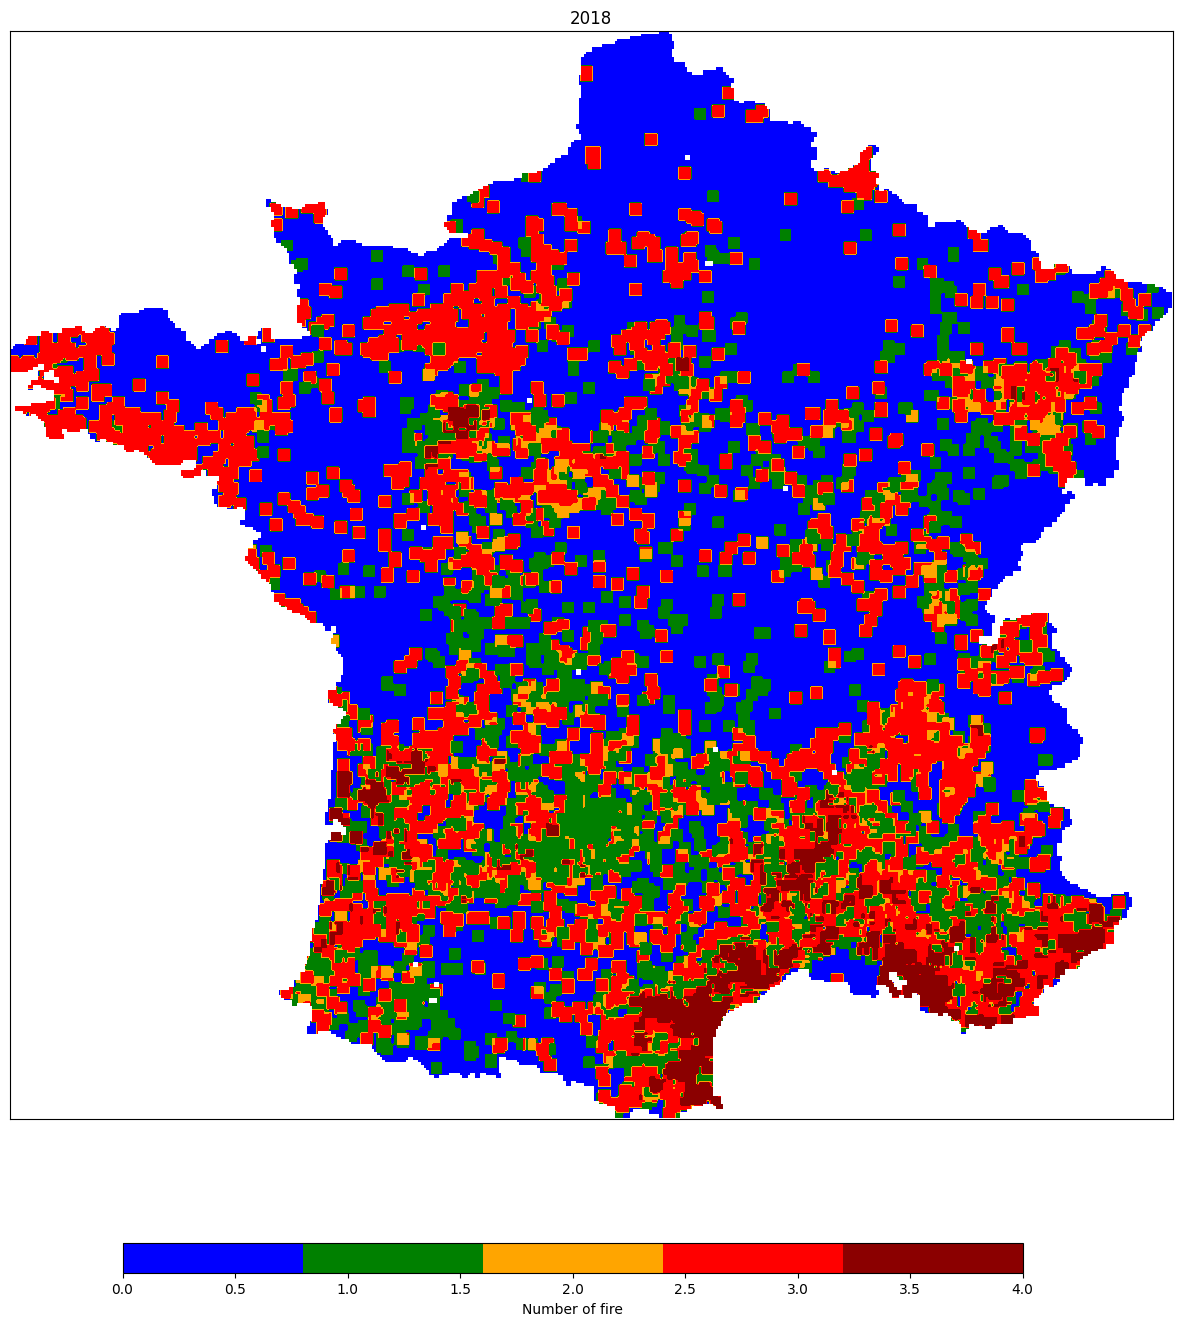

In [47]:
plot_matches_on_images([targets], years, figsize=(15,15), cmap=cmap)

In [48]:
import numpy as np
from scipy.interpolate import griddata

def interpolate_image_3d(image, exclude_mask=None, method='linear'):
    """
    Interpole les NaN d'une image 3D (C, H, W), canal par canal,
    en excluant les pixels masqués (True = exclus).

    Parameters:
        image (np.ndarray): Image 3D de forme (C, H, W) avec des NaN.
        exclude_mask (np.ndarray): Masque booléen 2D (H, W), True = ne pas interpoler.
        method (str): Méthode d'interpolation ('linear', 'nearest', 'cubic').

    Returns:
        np.ndarray: Image 3D interpolée.
    """
    assert image.ndim == 3, "L'image doit être 3D (C, H, W)"
    C, H, W = image.shape
    if exclude_mask is None:
        exclude_mask = np.zeros((H, W), dtype=bool)
    assert exclude_mask.shape == (H, W), "Le masque doit avoir la forme (H, W)"

    X, Y = np.meshgrid(np.arange(W), np.arange(H))
    result = np.copy(image)

    for c in range(C):
        channel = image[c]
        valid_mask = ~np.isnan(channel) & ~exclude_mask
        nan_mask = np.isnan(channel) & ~exclude_mask

        if np.any(nan_mask):
            points = np.stack((X[valid_mask], Y[valid_mask]), axis=-1)
            values_known = channel[valid_mask]
            points_interp = np.stack((X[nan_mask], Y[nan_mask]), axis=-1)

            interpolated = griddata(points, values_known, points_interp, method=method)

            channel_interp = channel.copy()
            channel_interp[nan_mask] = interpolated
            result[c] = channel_interp
            
    return result

features_array_interpolated = interpolate_image_3d(features_array, np.isnan(targets))
features_array = features_array_interpolated

In [49]:
final_dict

{'elevation': 0,
 'population': 1,
 'PasDeForet': 2,
 'Châtaignier': 3,
 'Décidus': 4,
 'Sempervirents': 5,
 'Conifères': 6,
 'Douglas': 7,
 'Feuillus': 8,
 'Hêtre': 9,
 'Mélèze': 10,
 'Mixte': 11,
 'NC': 12,
 'NR': 13,
 'Crochets, Cembro': 14,
 'Pin autre': 15,
 "Pin d'Alep": 16,
 'Pin laricio, pin noir': 17,
 'Pin maritime': 18,
 'Pin sylvestre': 19,
 'Pins mélangés': 20,
 'Peuplier': 21,
 'Robinier': 22,
 'Sapin, épicéa': 23,
 'PasDeRoute': 24,
 'motorway': 25,
 'primary': 26,
 'secondary': 27,
 'tertiary': 28,
 'path': 29,
 'Other': 30,
 'Building': 31,
 'Bare soil': 32,
 'Water surface': 33,
 'Conifer': 34,
 'Deciduous': 35,
 'Shrubland': 36,
 'Lawn': 37,
 'Crop': 38}

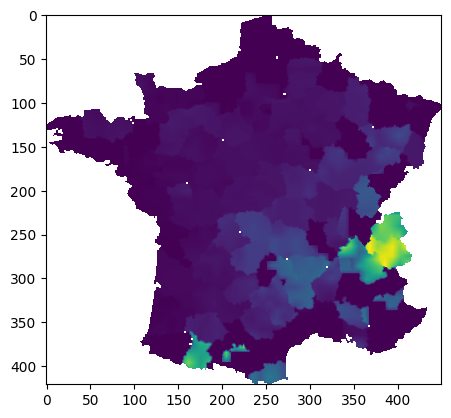

In [50]:
plt.imshow(features_array_interpolated[0])

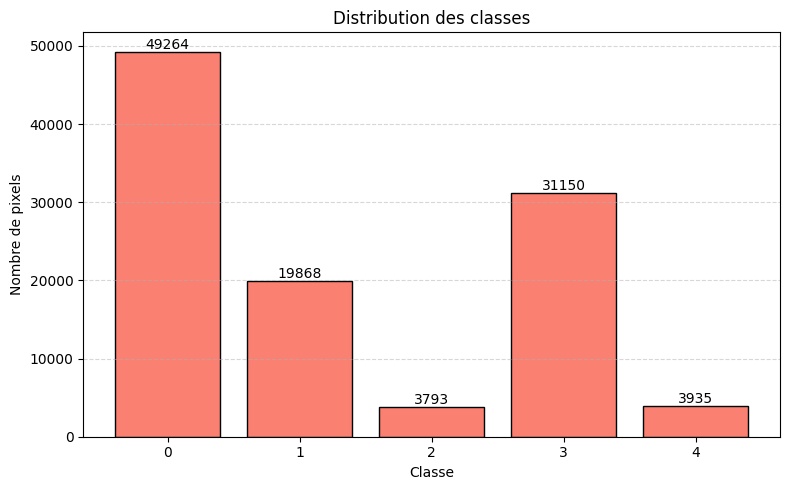

In [51]:
def plot_class_distribution(target, classes=[0,1,2,3,4], title="Distribution des classes", figsize=(8, 5)):
    """
    Affiche un barplot de la distribution des classes dans une image cible.

    Paramètres :
        target (np.ndarray): image 2D avec des labels de classe
        classes (list): liste des classes à afficher
        title (str): titre du graphique
        figsize (tuple): taille de la figure
    """
    counts = []
    for c in classes:
        counts.append(np.sum(target == c))

    plt.figure(figsize=figsize)
    bars = plt.bar([str(c) for c in classes], counts, color='salmon', edgecolor='black')
    plt.xlabel("Classe")
    plt.ylabel("Nombre de pixels")
    plt.title(title)
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    for bar, count in zip(bars, counts):
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(count),
                 ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.show()

plot_class_distribution(targets)

📊 Répartition avant SMOTE : {0.0: 35403, 3.0: 22401, 4.0: 2821, 1.0: 14300, 2.0: 2731}
✅ Répartition après SMOTE : {0.0: 35403, 3.0: 35403, 4.0: 35403, 1.0: 35403, 2.0: 35403}


/home/caron/Bureau/.conda/lib/python3.9/site-packages/xgboost/sklearn.py:889: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(


📊 Classification Report (test):
              precision    recall  f1-score   support

         0.0       0.93      0.62      0.75      9834
         1.0       0.78      0.64      0.71      3972
         2.0       0.56      0.58      0.57       759
         3.0       0.84      0.62      0.71      6223
         4.0       0.11      0.90      0.20       784

    accuracy                           0.63     21572
   macro avg       0.64      0.67      0.59     21572
weighted avg       0.83      0.63      0.70     21572

🧩 Confusion Matrix (test):
 [[6141  379   46  390 2878]
 [ 194 2553  153  218  854]
 [  13   64  444  110  128]
 [ 281  225  146 3828 1743]
 [   2   44    4   29  705]]
🎯 Balanced Accuracy Score (test): 0.673

📈 Évaluation complète (image entière):
              precision    recall  f1-score   support

         0.0       0.98      0.68      0.80     49171
         1.0       0.93      0.76      0.83     19861
         2.0       0.84      0.76      0.80      3793
         3.0 

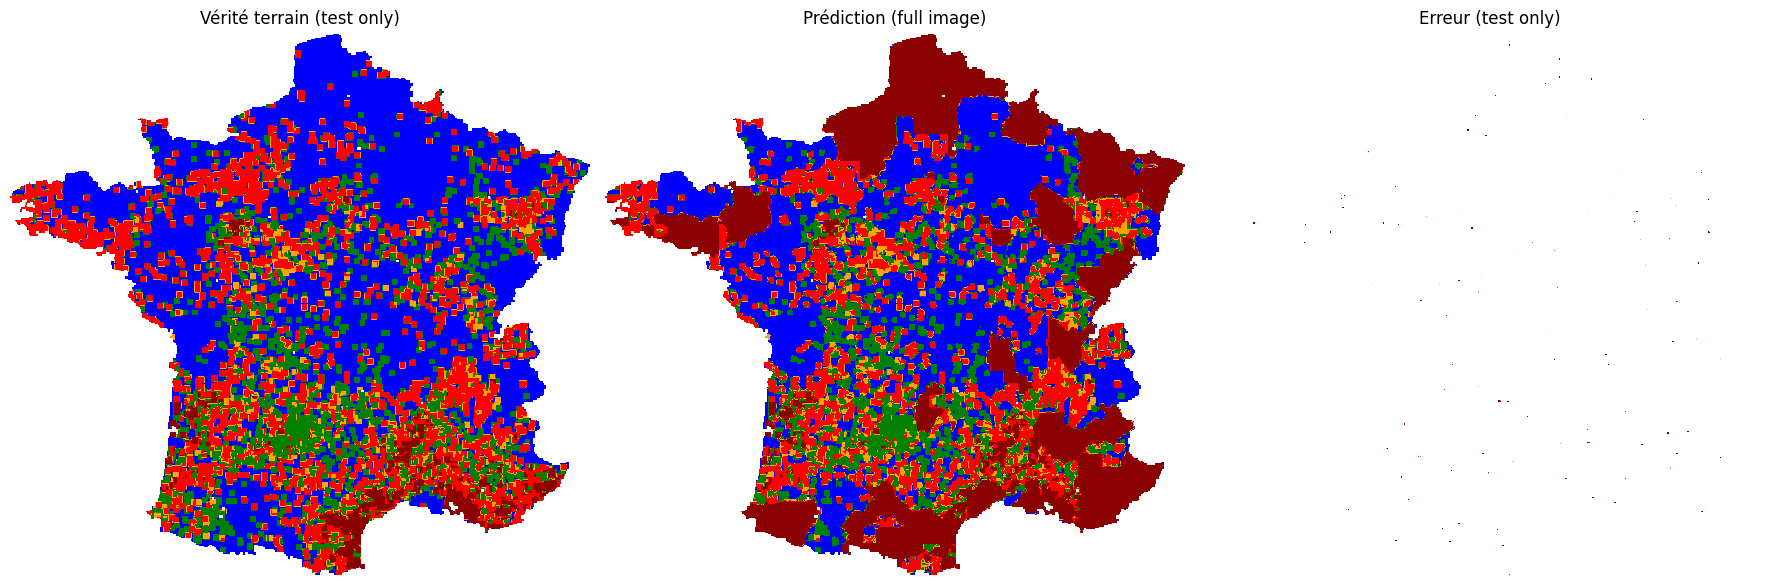

In [52]:
model_classic, X_train_classic, y_train_classic, X_test_classic, y_test_classic, y_pred_classic, features = train_evaluate_xgboost_from_images(
    features_array,
    np.copy(targets),
    class_colors=['blue', 'green', 'orange', 'red', 'darkred'],
    under_sampling=0.5
)

(56,) (9,) (29,)
[False  True]


/tmp/ipykernel_8009/1136021091.py:184: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plt.imshow(mask_img, cmap=plt.cm.get_cmap('tab10', 4), vmin=0, vmax=3)


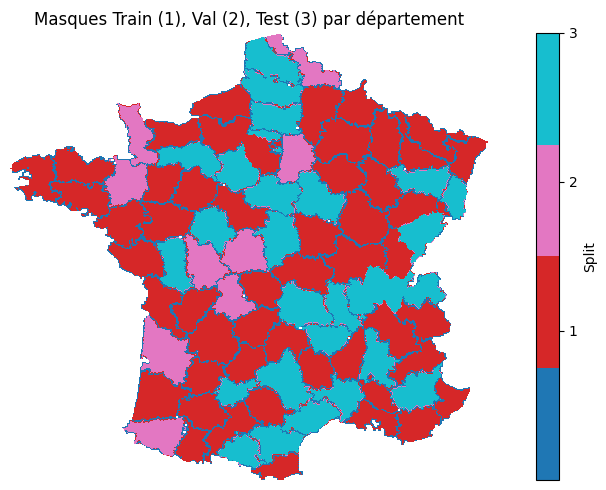

📊 Répartition avant SMOTE : {3.0: 16252, 0.0: 26061, 1.0: 9760, 2.0: 1973, 4.0: 1956}
✅ Répartition après SMOTE : {3.0: 26061, 0.0: 26061, 1.0: 26061, 2.0: 26061, 4.0: 26061}


/home/caron/Bureau/.conda/lib/python3.9/site-packages/xgboost/sklearn.py:889: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(


📊 Classification Report (test):
              precision    recall  f1-score   support

         0.0       0.45      0.30      0.36     12885
         1.0       0.22      0.19      0.20      5286
         2.0       0.05      0.22      0.09       904
         3.0       0.24      0.34      0.28      8608
         4.0       0.02      0.00      0.01      1231

    accuracy                           0.27     28914
   macro avg       0.20      0.21      0.19     28914
weighted avg       0.32      0.27      0.28     28914

🧩 Confusion Matrix (test):
 [[3804 1671 1255 6108   47]
 [1420  983 1001 1811   71]
 [ 177  236  201  277   13]
 [2780 1620 1225 2899   84]
 [ 253    9  107  858    4]]
🎯 Balanced Accuracy Score (test): 0.209

📈 Évaluation complète (image entière):
              precision    recall  f1-score   support

         0.0       0.70      0.47      0.56     49171
         1.0       0.42      0.36      0.39     19861
         2.0       0.16      0.50      0.25      3793
         3.0 

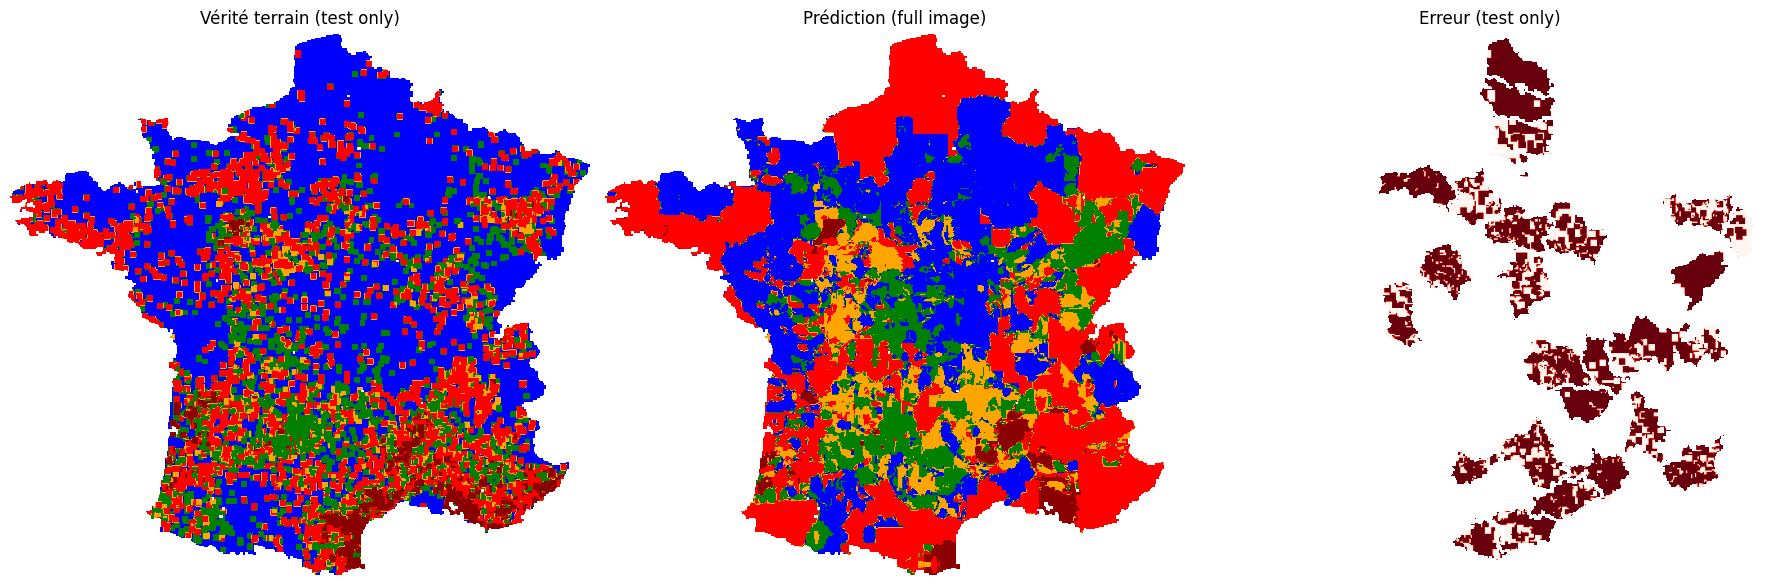

In [53]:
model_departement, X_train_departement, y_train_departement, X_test_departement, y_test_departement, y_pred_departement, features = train_evaluate_xgboost_from_images(
    features_array,
    np.copy(targets),
    class_colors=['blue', 'green', 'orange', 'red', 'darkred'],
    departement_mask=departement_mask, mode_train='departement',
    test_size=0.3,
    under_sampling=0.5
)

In [54]:
scale = 7

nb_attempt = 3
min_cluster_size = 1 + scale * 3 * (scale + 1)
max_cluster_size = 2.5 * min_cluster_size
exclude_label = [0]
background = -1
apply_kmeans = False

def image_process(image, mask, apply_kmeans, **args):
    valid_mask = ~np.isnan(image)
    res_watershed = my_watershed(image, valid_mask, apply_kmeans)

    merge_region = merge_adjacent_clusters(res_watershed, **args)

    valid_cluster = find_clusters(merge_region, min_cluster_size, 0, -1)

    valid_cluster = [val + 1 for val in valid_cluster]
    merge_region[valid_mask] += 1
    merge_region = split_large_clusters(merge_region, max_cluster_size, min_cluster_size, valid_cluster)
    valid_cluster = [val - 1 for val in valid_cluster]
    merge_region[valid_mask] -= 1
    
    valid_mask = ~mask
    merge_region = merge_region.astype(np.float32)
    merge_region[mask] = np.nan
    return merge_region

merge_region = image_process(np.copy(targets), np.isnan(targets), nb_attempt=nb_attempt, mode='size', min_cluster_size=min_cluster_size, max_cluster_size=max_cluster_size, exclude_label=exclude_label, background=background, apply_kmeans=apply_kmeans)

Use biggest neighbord label 147 -> 141
Use biggest neighbord label 224 -> 235
Use biggest neighbord label 248 -> 235
Use biggest neighbord label 267 -> 213
Use biggest neighbord label 274 -> 213
Use biggest neighbord label 311 -> 170
Use biggest neighbord label 320 -> 170
Use biggest neighbord label 361 -> 439
Use biggest neighbord label 426 -> 456
Use neighbord label 506 -> 602
Use neighbord label 507 -> 602
Use biggest neighbord label 524 -> 592
Use neighbord label 527 -> 672
Use neighbord label 553 -> 602
Use neighbord label 585 -> 642
Use biggest neighbord label 591 -> 592
Use biggest neighbord label 632 -> 592
Use neighbord label 641 -> 817
Use neighbord label 664 -> 672
Use biggest neighbord label 728 -> 745
Use neighbord label 734 -> 817
Use neighbord label 750 -> 653
Use biggest neighbord label 756 -> 770
Remove label 779
Use neighbord label 804 -> 653
Use neighbord label 811 -> 826
Use biggest neighbord label 813 -> 744
Use biggest neighbord label 831 -> 845
Use neighbord labe

KeyboardInterrupt: 

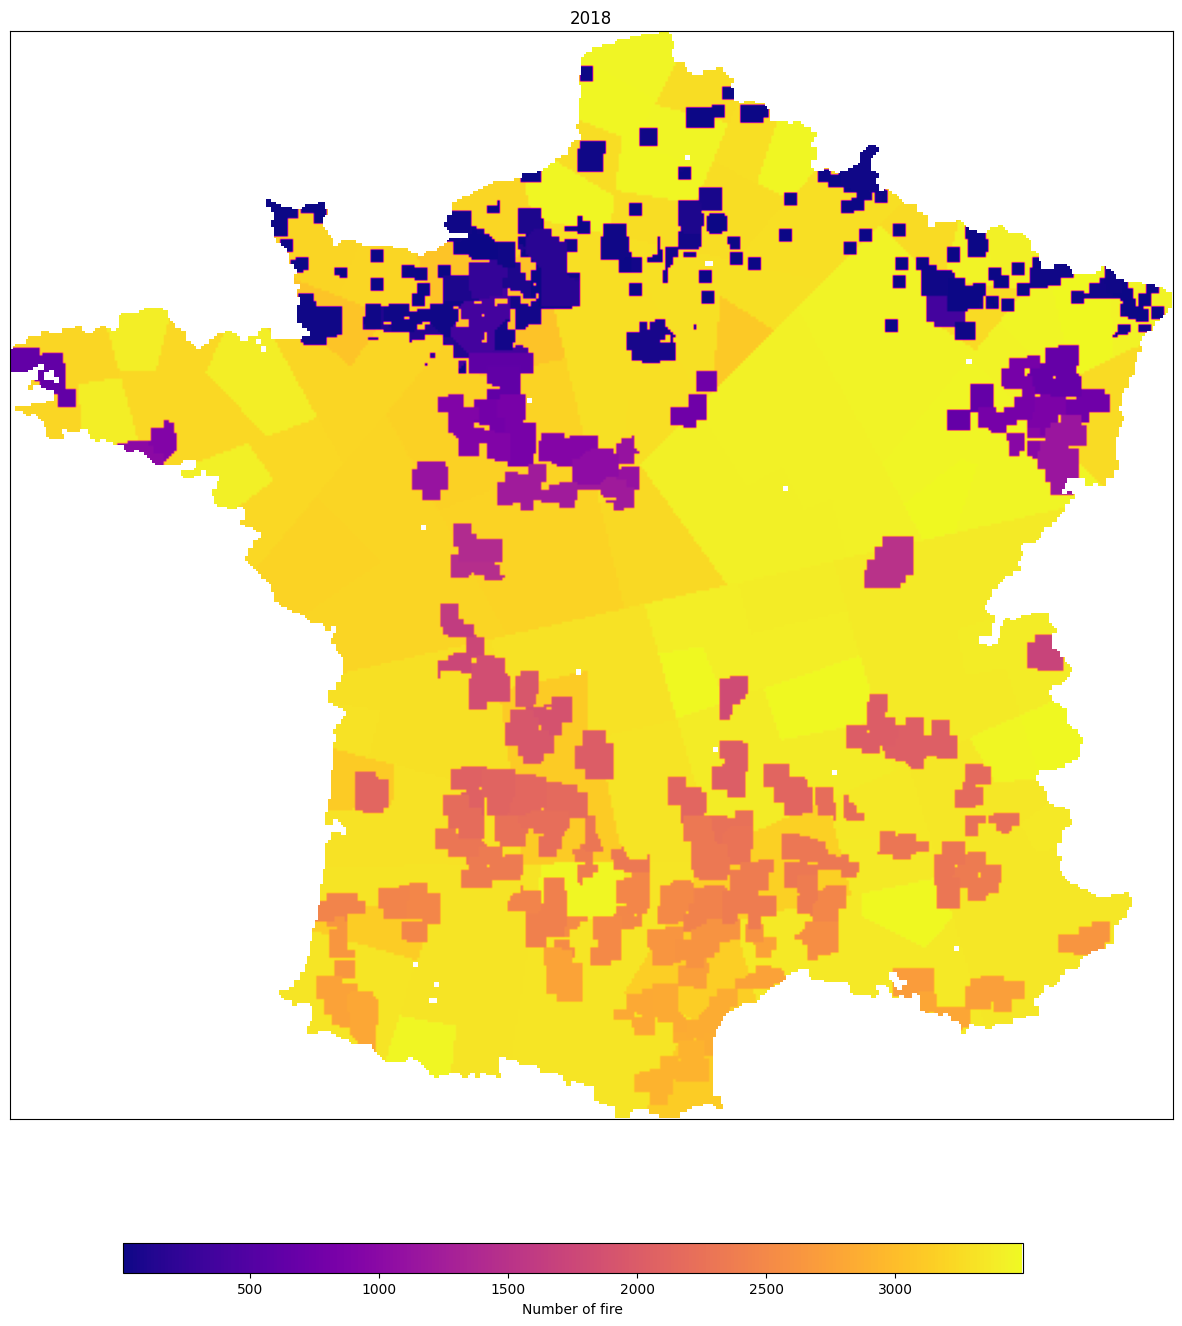

In [574]:
plot_matches_on_images([merge_region], years, figsize=(15,15), cmap='plasma')

(227,) (41,) (146,)
[False  True]


/tmp/ipykernel_13028/2824350389.py:182: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plt.imshow(mask_img, cmap=plt.cm.get_cmap('tab10', 4), vmin=0, vmax=3)


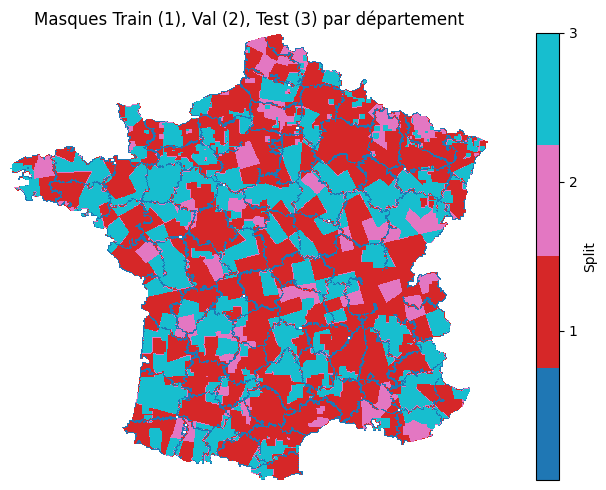

📊 Répartition avant SMOTE : {0.0: 23827, 3.0: 14480, 1.0: 9400, 2.0: 1695, 4.0: 2154}
✅ Répartition après SMOTE : {0.0: 23827, 3.0: 23827, 1.0: 23827, 2.0: 23827, 4.0: 23827}


/home/caron/Bureau/.conda/lib/python3.9/site-packages/xgboost/sklearn.py:889: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(


📊 Classification Report (test):
              precision    recall  f1-score   support

         0.0       0.62      0.49      0.55     14861
         1.0       0.33      0.29      0.31      6659
         2.0       0.14      0.23      0.17      1421
         3.0       0.46      0.23      0.31     10542
         4.0       0.07      0.70      0.12       887

    accuracy                           0.37     34370
   macro avg       0.32      0.39      0.29     34370
weighted avg       0.48      0.37      0.40     34370

🧩 Confusion Matrix (test):
 [[7282 1783  337 1723 3736]
 [1671 1926  658  829 1575]
 [ 238  331  323  267  262]
 [2570 1628  936 2455 2953]
 [  18   97   78   76  618]]

📈 Évaluation complète (image entière):
              precision    recall  f1-score   support

         0.0       0.74      0.49      0.59     49171
         1.0       0.49      0.42      0.45     19861
         2.0       0.22      0.46      0.30      3793
         3.0       0.60      0.35      0.44     31113

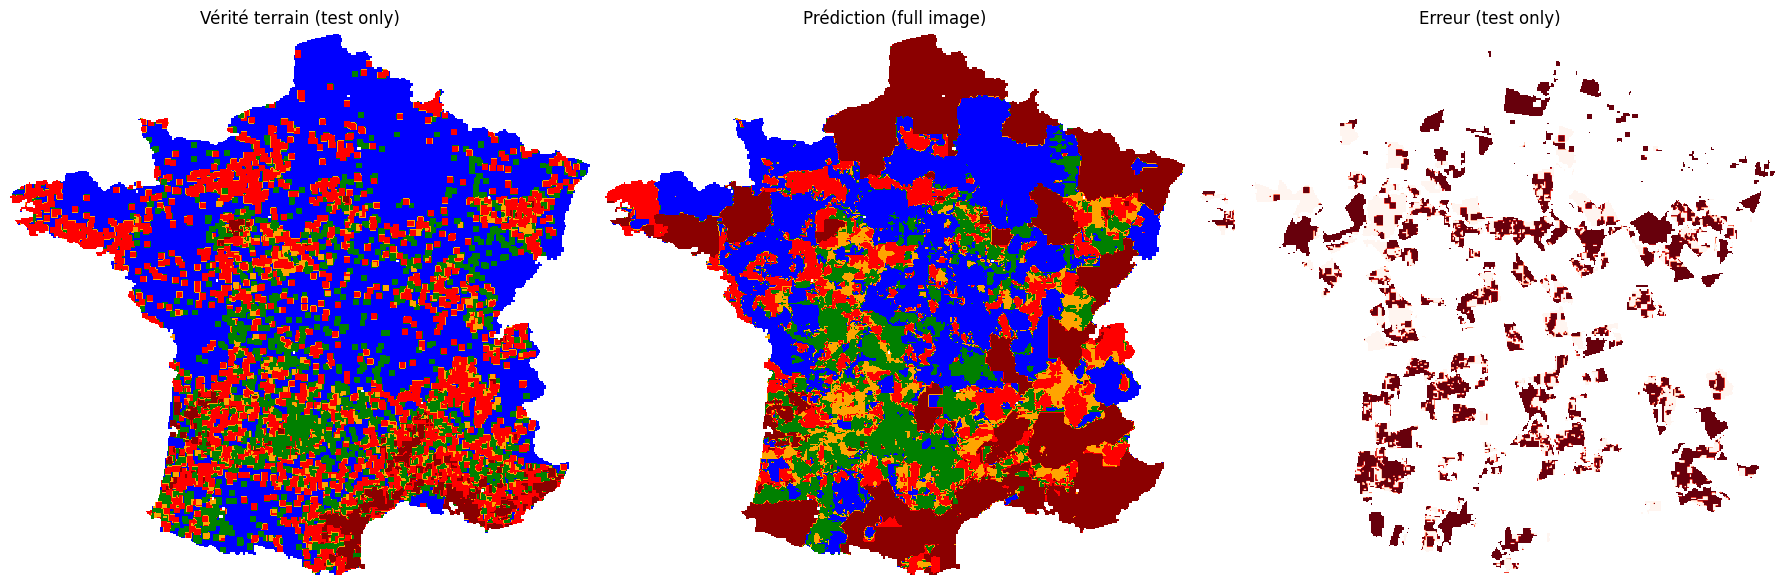

In [575]:
image_cluster_mask = merge_region.astype(np.float32)
image_cluster_mask[np.isnan(departement_mask)] = np.nan

model_cluster, X_train_cluster, y_train_cluster, X_test_cluster, y_test_cluster, y_pred_cluster, features = train_evaluate_xgboost_from_images(
    features_array,
    np.copy(targets),
    class_colors=['blue', 'green', 'orange', 'red', 'darkred'],
    departement_mask=image_cluster_mask, mode_train='departement',
    test_size=0.35,
    do_apply_smote=True,
    under_sampling=0.5
    )

In [576]:
features_name = list(final_dict.keys())

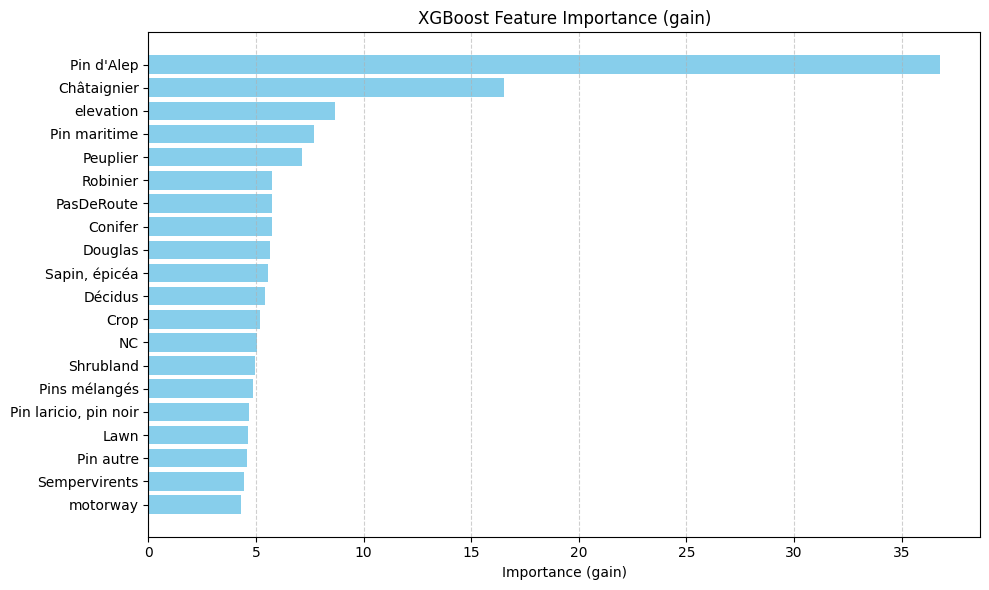

In [577]:
plot_xgboost_feature_importance(model_classic, features_name)

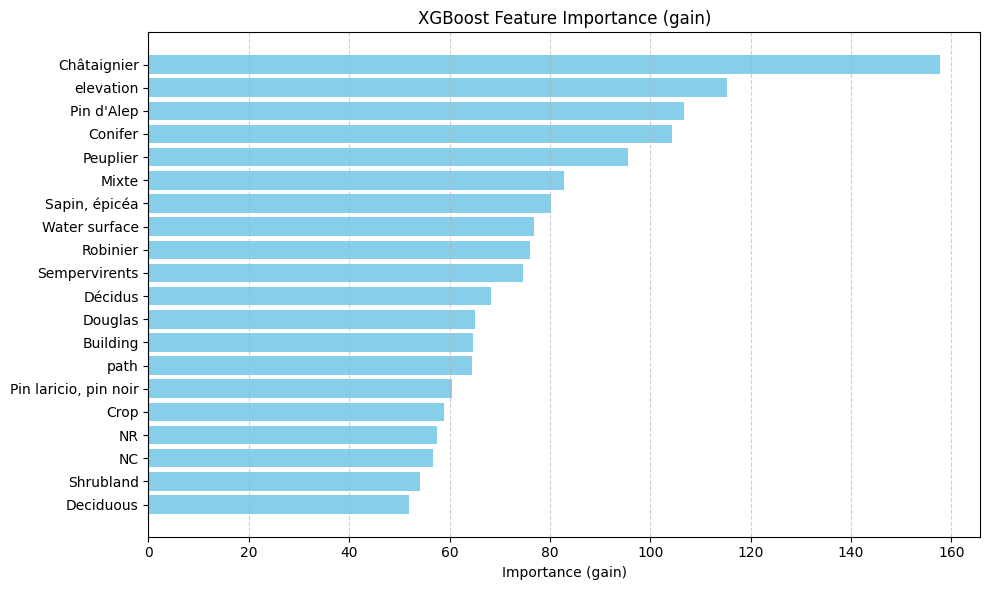

In [578]:
plot_xgboost_feature_importance(model_departement, features_name)

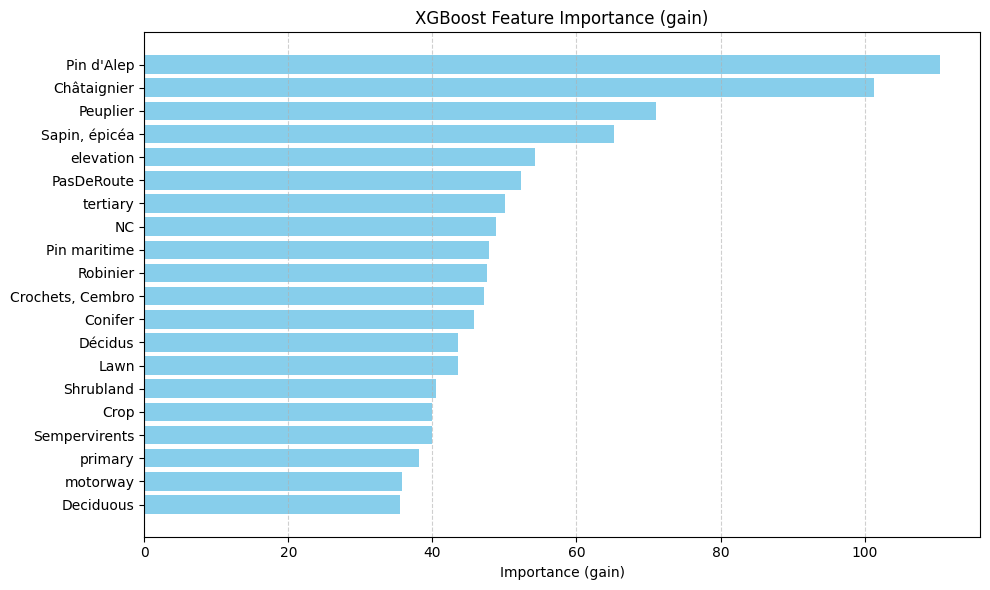

In [579]:
plot_xgboost_feature_importance(model_cluster, features_name)

✅ SHAP plot sauvegardé pour classe 0 : sucspetiblity_xgboost_vanilla/shap_values_train_class0_beeswarm.png


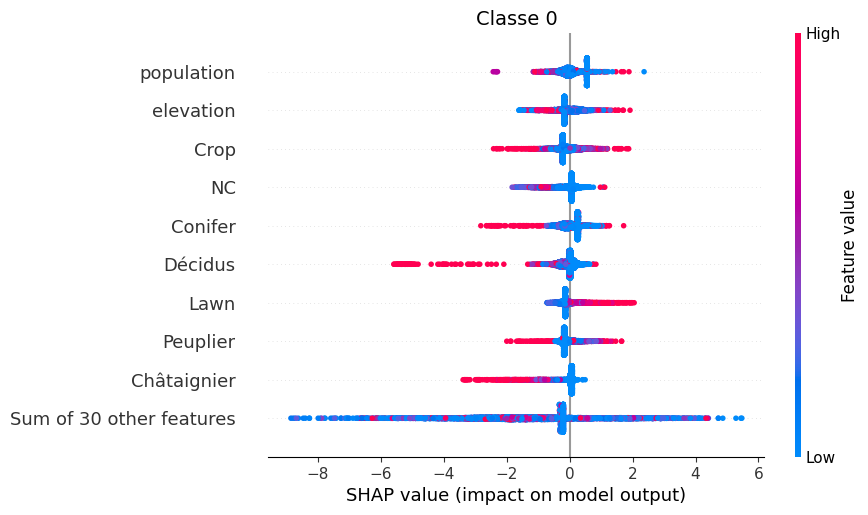

✅ SHAP plot sauvegardé pour classe 1 : sucspetiblity_xgboost_vanilla/shap_values_train_class1_beeswarm.png


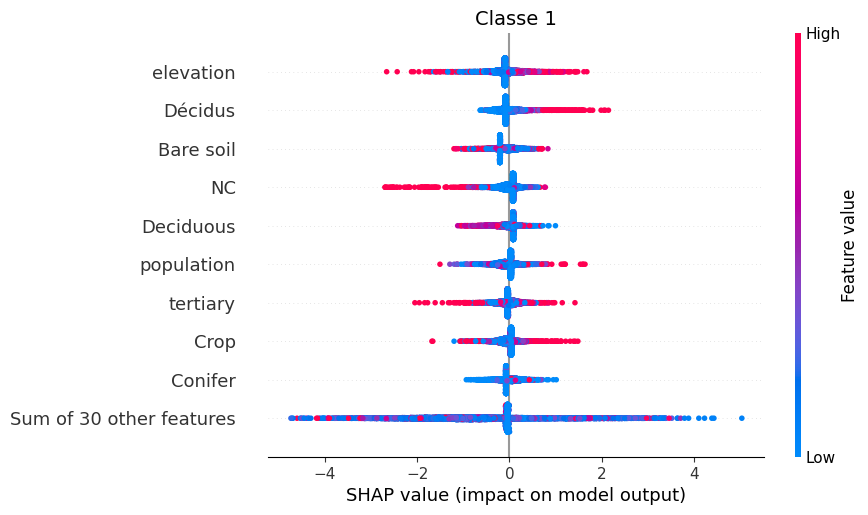

✅ SHAP plot sauvegardé pour classe 2 : sucspetiblity_xgboost_vanilla/shap_values_train_class2_beeswarm.png


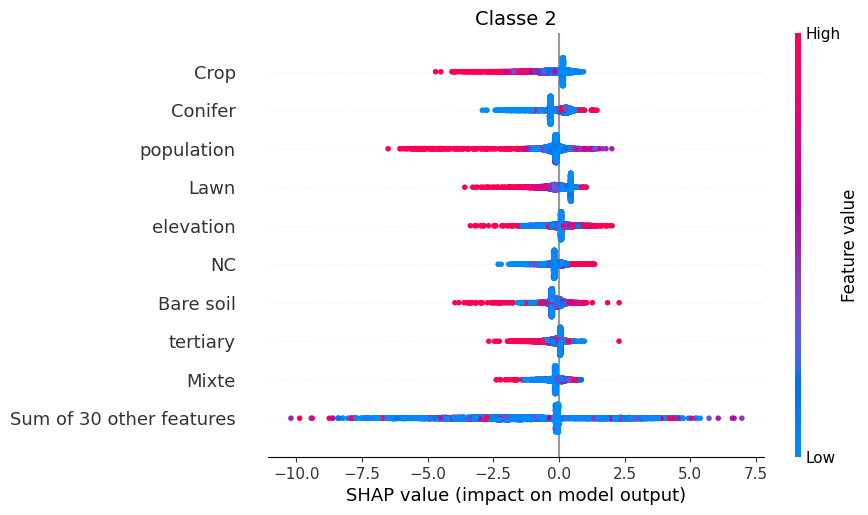

✅ SHAP plot sauvegardé pour classe 3 : sucspetiblity_xgboost_vanilla/shap_values_train_class3_beeswarm.png


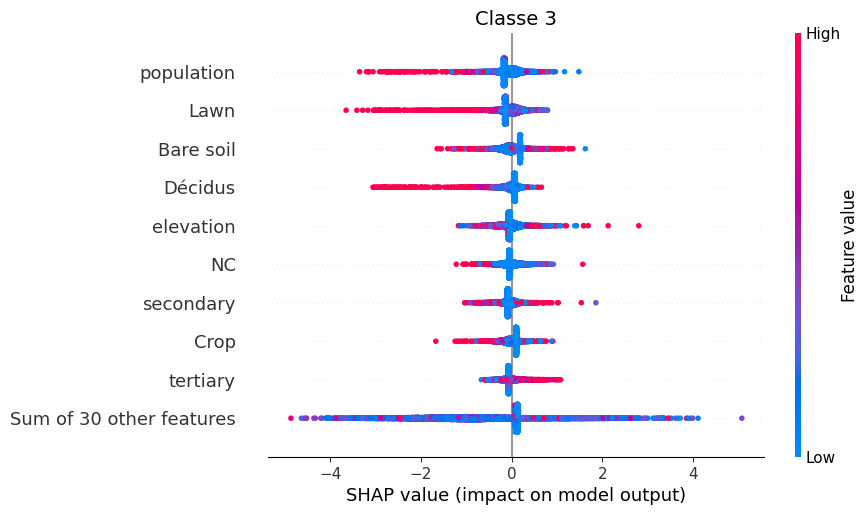

✅ SHAP plot sauvegardé pour classe 4 : sucspetiblity_xgboost_vanilla/shap_values_train_class4_beeswarm.png


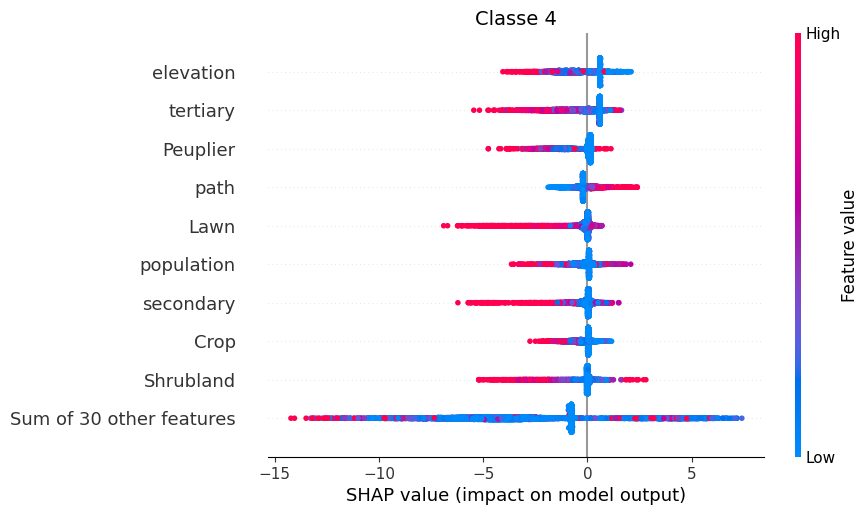

In [580]:
def compute_shap(model, X_train):
    np.random.seed(42)

    indices = np.arange(X_train.shape[0])

    X_train_sample = X_train[np.random.choice(indices, size=5000, replace=False)]

    df = pd.DataFrame(index=np.arange(X_train_sample.shape[0]))

    df[features_name] = X_train_sample

    shap_values = shapley_additive_explanation(df, model)

    dir_output = Path('sucspetiblity_xgboost_vanilla')

    plot_shap_grid(shap_values, [0,1,2,3,4], dir_output, 'shap_values_train', list(final_dict.keys()), (15,15), mode='beeswarm')

compute_shap(model_classic, X_train_classic)

✅ SHAP plot sauvegardé pour classe 0 : sucspetiblity_xgboost_vanilla/shap_values_train_class0_beeswarm.png


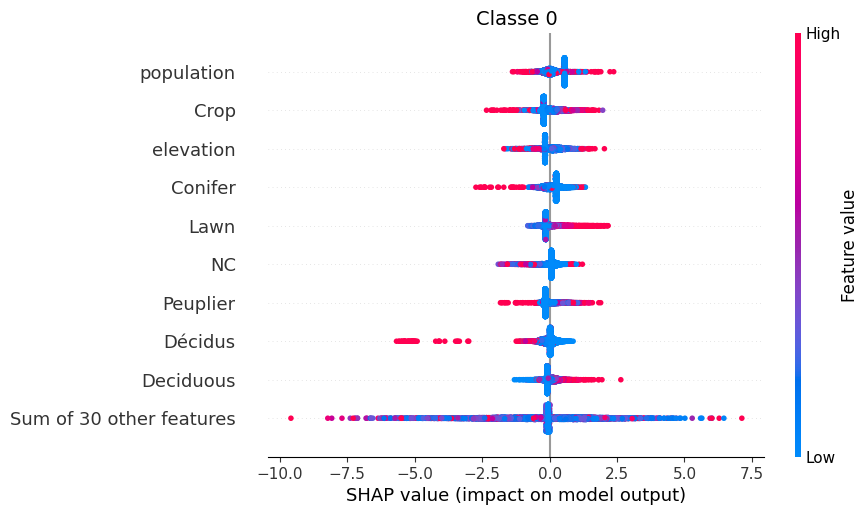

✅ SHAP plot sauvegardé pour classe 1 : sucspetiblity_xgboost_vanilla/shap_values_train_class1_beeswarm.png


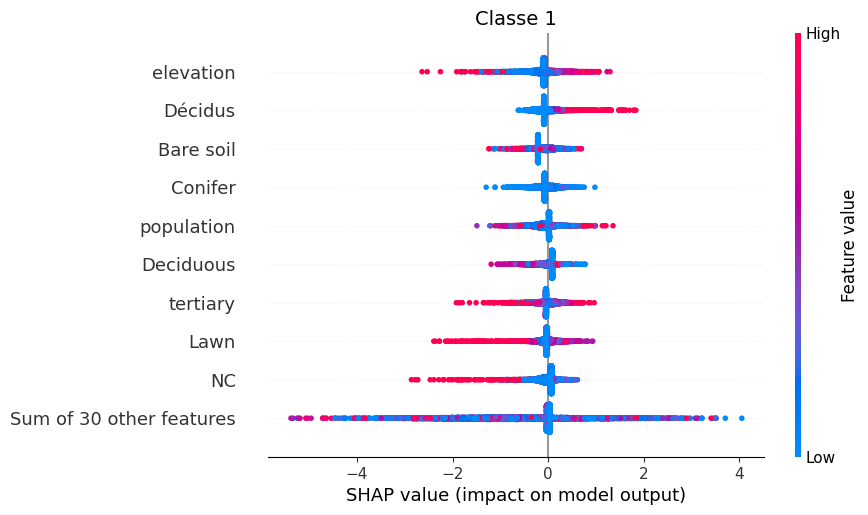

✅ SHAP plot sauvegardé pour classe 2 : sucspetiblity_xgboost_vanilla/shap_values_train_class2_beeswarm.png


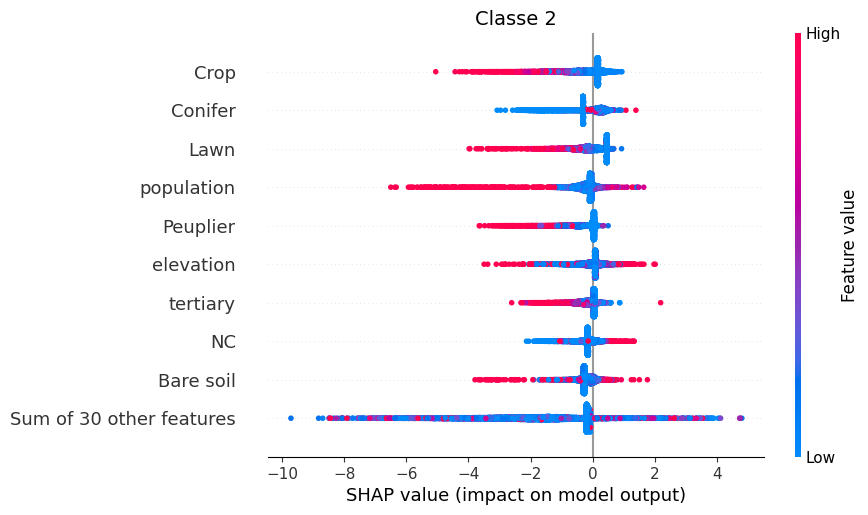

✅ SHAP plot sauvegardé pour classe 3 : sucspetiblity_xgboost_vanilla/shap_values_train_class3_beeswarm.png


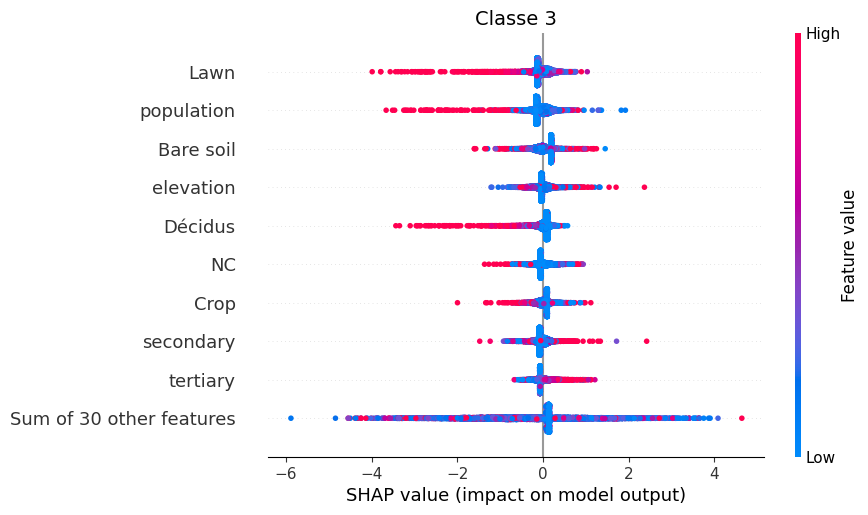

✅ SHAP plot sauvegardé pour classe 4 : sucspetiblity_xgboost_vanilla/shap_values_train_class4_beeswarm.png


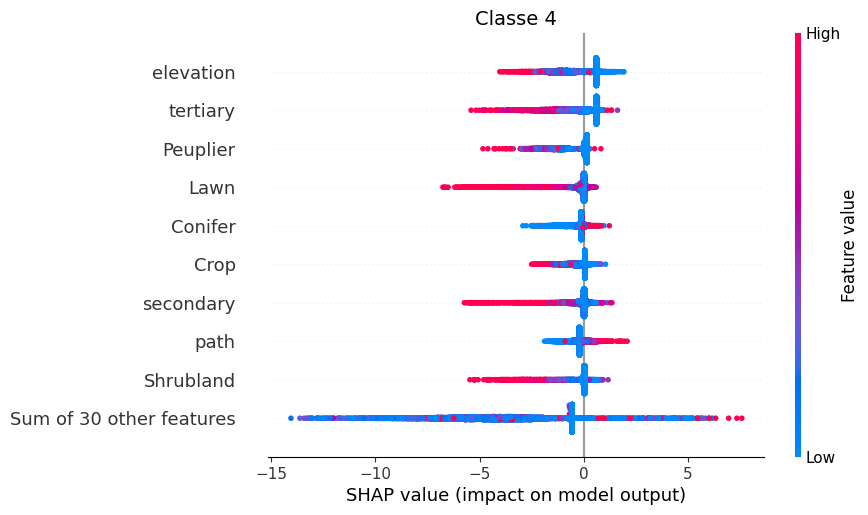

In [581]:
compute_shap(model_classic, X_test_classic)

## CNN

In [582]:
import torch
import torch.nn as nn
from torch.nn import ReLU, Identity

class Bottleneck(nn.Module):
    def __init__(self,in_places, places, stride=1,downsampling=False, expansion = 4, device=None):
        super(Bottleneck,self).__init__()
        self.expansion = expansion
        self.downsampling = downsampling

        self.bottleneck = nn.Sequential(
            nn.Conv2d(in_channels=in_places,out_channels=places,kernel_size=1,stride=1, bias=False).to(device),
            nn.BatchNorm2d(places).to(device),
            nn.ReLU(inplace=True).to(device),
            nn.Conv2d(in_channels=places, out_channels=places, kernel_size=3, stride=stride, padding=1, bias=False).to(device),
            nn.BatchNorm2d(places).to(device),
            nn.ReLU(inplace=True).to(device),
            nn.Conv2d(in_channels=places, out_channels=places*self.expansion, kernel_size=1, stride=1, bias=False).to(device),
            nn.BatchNorm2d(places*self.expansion).to(device),
        )

        if self.downsampling:
            self.downsample = nn.Sequential(
                nn.Conv2d(in_channels=in_places, out_channels=places*self.expansion, kernel_size=1, stride=stride, bias=False).to(device),
                nn.BatchNorm2d(places*self.expansion).to(device)
            )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        residual = x
        out = self.bottleneck(x)
        if self.downsampling:
            residual = self.downsample(x)
        out += residual
        out = self.relu(out)
        return out

class ResNet(torch.nn.Module):
    def __init__(self, in_channels, conv_channels, fc_channels, dropout, device,
                 n_sequences, avgpooling=1, return_hidden=False, out_channels=None, task_type='classification'):
        super(ResNet, self).__init__()
        torch.manual_seed(42)

        self.input_batch_norm = torch.nn.BatchNorm2d(in_channels).to(device)

        self.return_hidden = return_hidden

        self.input = torch.nn.Conv2d(in_channels=in_channels, out_channels=conv_channels[0], kernel_size=(1,1)).to(device)

        self.bottleneck = []
        self.batch_norm_list = []
        self.fc_list = []

        for i in range(len(conv_channels) - 1):
            self.bottleneck.append(Bottleneck(conv_channels[i], conv_channels[i + 1], stride=1, downsampling=True, expansion=1, device=device))

        self.activation = ReLU().to(device)
        self.pooling = torch.nn.AdaptiveAvgPool2d(avgpooling)

        for i in range(len(fc_channels) - 1):
            self.fc_list.append(torch.nn.Linear(in_features=fc_channels[i], out_features=fc_channels[i+1]).to(device))

        self.last_linear = torch.nn.Linear(in_features=fc_channels[-1], out_features=out_channels).to(device) if out_channels is not None else torch.nn.Linear(in_features=fc_channels[-1], out_features=1).to(device)
        self.softmax = torch.nn.Softmax(dim=1)
        self.drop = torch.nn.Dropout(dropout) if dropout > 0.0 else Identity().to(device)

        self.bottleneck = torch.nn.ModuleList(self.bottleneck)
        self.batch_norm_list = torch.nn.ModuleList(self.batch_norm_list)
        self.fc_list = torch.nn.ModuleList(self.fc_list)

        self.num_conv = len(self.bottleneck)
        self.num_fc = len(self.fc_list)

        self.task_type = task_type
        self.out_channels = out_channels
        self.is_graph_or_node = False

    def forward(self, X, edge_index=None, graphs=None):
        # egde index not used, API configuration
        
        # Bottleneck
        x = self.input_batch_norm(X)
        x = self.input(x)
        for i, layer in enumerate(self.bottleneck):
            x = layer(x)
        
        x = self.pooling(x)
        x = x.reshape(x.shape[0], -1)

        for i, layer in enumerate(self.fc_list):
            x = layer(x)
            x = self.drop(x)
            x = self.activation(x)

        x_linear = self.last_linear(x)

        if self.task_type == 'classification':
            output = self.softmax(x_linear)
        else:
            output = x_linear

        if self.return_hidden:
            return output, x
        else:
            return output

In [583]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import random

def extract_patches(features, target, dist):
    C, H, W = features.shape
    pad = dist
    padded = np.pad(features, ((0, 0), (pad, pad), (pad, pad)), mode='constant', constant_values=np.nan)

    X = []
    y = []
    valid_mask = []

    for i in range(H):
        for j in range(W):
            patch = padded[:, i:i + 2 * pad + 1, j:j + 2 * pad + 1]
            target_val = target[i, j]

            if not np.isnan(target_val):
                # Remplacer les NaN dans le patch par 0
                patch = np.nan_to_num(patch, nan=0.0)
                X.append(patch)
                y.append(target_val)
                valid_mask.append((i, j))

    X = np.stack(X)
    y = np.array(y).astype(int)
    valid_mask = np.array(valid_mask)

    return X, y, valid_mask

class SimpleCNN(nn.Module):
    def __init__(self, in_channels, num_classes):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(64, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))  # Bx32xHxW
        x = F.relu(self.conv2(x))  # Bx64xHxW
        x = F.adaptive_avg_pool2d(x, (1, 1)).squeeze(-1).squeeze(-1)  # Bx64
        x = F.relu(self.fc1(x))  # Bx128
        return self.fc2(x)

def train_evaluate_cnn_from_images(
    features,
    target,
    device,
    dist=2,
    test_size=0.2,
    val_size=0.1,
    random_state=42,
    class_colors=['blue', 'green', 'orange', 'red', 'darkred'],
    departement_mask=None,
    mode_train='classic',
    num_epochs=20,
    batch_size=64,
    undersample_ratio=1.0
):
    torch.manual_seed(random_state)
    np.random.seed(random_state)
    random.seed(random_state)

    C, H, W = features.shape

    # Extraction des patches valides
    X_patches, y, valid_indices = extract_patches(features, target, dist)
    full_indices = np.arange(len(y))

    if mode_train == 'classic':
        from sklearn.model_selection import train_test_split

        X_train_val, X_test, y_train_val, y_test, idx_train_val, idx_test = train_test_split(
            X_patches, y, full_indices, test_size=test_size, stratify=y, random_state=random_state
        )
        X_train, X_val, y_train, y_val = train_test_split(
            X_train_val, y_train_val, test_size=val_size, stratify=y_train_val, random_state=random_state
        )

    elif mode_train == 'departement':
        assert departement_mask is not None, "departement_mask est requis en mode 'departement'"
        dep_flat = departement_mask.flatten()
        dep_vals = [dep_flat[i * W + j] for i, j in valid_indices]
        dep_vals = np.array(dep_vals)

        unique_deps = np.unique(dep_vals[~np.isnan(dep_vals)])
        np.random.shuffle(unique_deps)

        n_total = len(unique_deps)
        n_train = int(n_total * (1 - test_size - val_size))
        n_val = int(n_total * val_size)

        deps_train = unique_deps[:n_train]
        deps_val = unique_deps[n_train:n_train + n_val]
        deps_test = unique_deps[n_train + n_val:]

        mask_train = np.isin(dep_vals, deps_train)
        mask_val = np.isin(dep_vals, deps_val)
        mask_test = np.isin(dep_vals, deps_test)

        X_train, y_train = X_patches[mask_train], y[mask_train]
        X_val, y_val = X_patches[mask_val], y[mask_val]
        X_test, y_test = X_patches[mask_test], y[mask_test]
        idx_test = valid_indices[mask_test]

    else:
        raise ValueError(f"mode_train '{mode_train}' non reconnu")
    
    if undersample_ratio > 1.0:
        X_train, y_train = undersample_majority(X_train, y_train, ratio=undersample_ratio)

    # Torch datasets
    def to_loader(X, y):
        tensor_x = torch.tensor(X, dtype=torch.float32).to(device)
        tensor_y = torch.tensor(y, dtype=torch.long).to(device)
        return DataLoader(TensorDataset(tensor_x, tensor_y), batch_size=batch_size, shuffle=True)

    train_loader = to_loader(X_train, y_train)
    val_loader = to_loader(X_val, y_val)
    test_loader = to_loader(X_test, y_test)

    # Modèle
    num_classes = len(np.unique(y))
    model = SimpleCNN(in_channels=C, num_classes=num_classes)
    model = ResNet(in_channels=C, conv_channels=[C * 2, C * 4, C * 4], fc_channels=[C * 4 * 1 * 1, 128], dropout=0.03, n_sequences=0, avgpooling=1, return_hidden=False, out_channels=num_classes, task_type='classification', device=device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    # Entraînement
    for epoch in range(num_epochs):
        model.train()
        for Xb, yb in train_loader:
            optimizer.zero_grad()
            logits = model(Xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            
        # Validation
        model.eval()
        with torch.no_grad():
        y_true_val = []
        y_pred_val = []
        for Xb, yb in val_loader:
            preds = model(Xb).argmax(1)
            y_true_val.extend(yb.cpu().numpy())
            y_pred_val.extend(preds.cpu().numpy())

        balanced_acc = balanced_accuracy_score(y_true_val, y_pred_val)
        print(f"Epoch {epoch+1:02d}: val balanced acc = {balanced_acc:.3f}")

    # Test
    model.eval()
    y_pred = []
    with torch.no_grad():
        for Xb, _ in test_loader:
            y_pred.append(model(Xb).argmax(1).cpu().numpy())
    y_pred = np.concatenate(y_pred)

    print("\n📊 Classification Report (test):")
    print(classification_report(y_test, y_pred))

    bca = balanced_accuracy_score(y_test, y_pred)
    print(f"🎯 Balanced Accuracy Score (test): {bca:.3f}")

    # Reconstruction image
    y_full_pred = np.full((H, W), np.nan)
    for idx, (i, j) in zip(range(len(y)), valid_indices):
        y_full_pred[i, j] = model(torch.tensor(X_patches[idx:idx+1], dtype=torch.float32, device=device)).argmax(1).item()

    y_true_img = np.full((H, W), np.nan)
    for idx, (i, j) in zip(range(len(y)), valid_indices):
        y_true_img[i, j] = y[idx]

    error_img = np.full((H, W), np.nan)
    """ for idx, (i, j) in zip(idx_test, valid_indices[full_indices[idx_test]]):
        pred = model(torch.tensor(X_patches[idx:idx+1], dtype=torch.float32, device=device)).argmax(1).item()
        error_img[i, j] = int(pred != y[idx])"""

    y_full_pred[np.isnan(targets)] = np.nan
    y_true_img[np.isnan(targets)] = np.nan
    error_img[np.isnan(targets)] = np.nan

    # Affichage
    cmap = plt.cm.colors.ListedColormap(class_colors[:num_classes])
    fig, axs = plt.subplots(1, 3, figsize=(18, 6))
    axs[0].imshow(y_true_img, cmap=cmap, vmin=0, vmax=num_classes - 1)
    axs[0].set_title("Vérité terrain")
    axs[1].imshow(y_full_pred, cmap=cmap, vmin=0, vmax=num_classes - 1)
    axs[1].set_title("Prédiction CNN")
    axs[2].imshow(error_img, cmap='Reds')
    axs[2].set_title("Erreur")
    for ax in axs:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

    return model, X_train, y_train, X_test, y_test, y_pred, C

IndentationError: expected an indented block (721973013.py, line 149)

/home/caron/Bureau/.conda/lib/python3.9/site-packages/IPython/core/events.py:89: UserWarning: Casting input data from float128 to float64 for imshow.
  func(*args, **kwargs)
/home/caron/Bureau/.conda/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Casting input data from float128 to float64 for imshow.
  fig.canvas.print_figure(bytes_io, **kw)


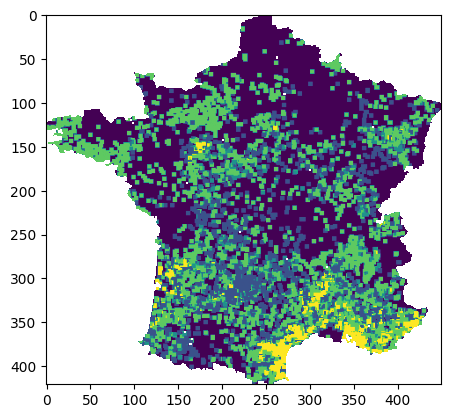

In [549]:
plt.imshow(targets)

Epoch 01: val acc = 0.535
Epoch 02: val acc = 0.545
Epoch 03: val acc = 0.549
Epoch 04: val acc = 0.567
Epoch 05: val acc = 0.570
Epoch 06: val acc = 0.578
Epoch 07: val acc = 0.576
Epoch 08: val acc = 0.584
Epoch 09: val acc = 0.571
Epoch 10: val acc = 0.591
Epoch 11: val acc = 0.593
Epoch 12: val acc = 0.602
Epoch 13: val acc = 0.598
Epoch 14: val acc = 0.598
Epoch 15: val acc = 0.606
Epoch 16: val acc = 0.602
Epoch 17: val acc = 0.601
Epoch 18: val acc = 0.607
Epoch 19: val acc = 0.610
Epoch 20: val acc = 0.613

📊 Classification Report (test):
              precision    recall  f1-score   support

           0       0.46      0.62      0.53      9853
           1       0.18      0.14      0.16      3973
           2       0.00      0.00      0.00       759
           3       0.30      0.25      0.27      6230
           4       0.00      0.00      0.00       787

    accuracy                           0.38     21602
   macro avg       0.19      0.20      0.19     21602
weighted avg 

/home/caron/Bureau/.conda/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/caron/Bureau/.conda/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/caron/Bureau/.conda/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


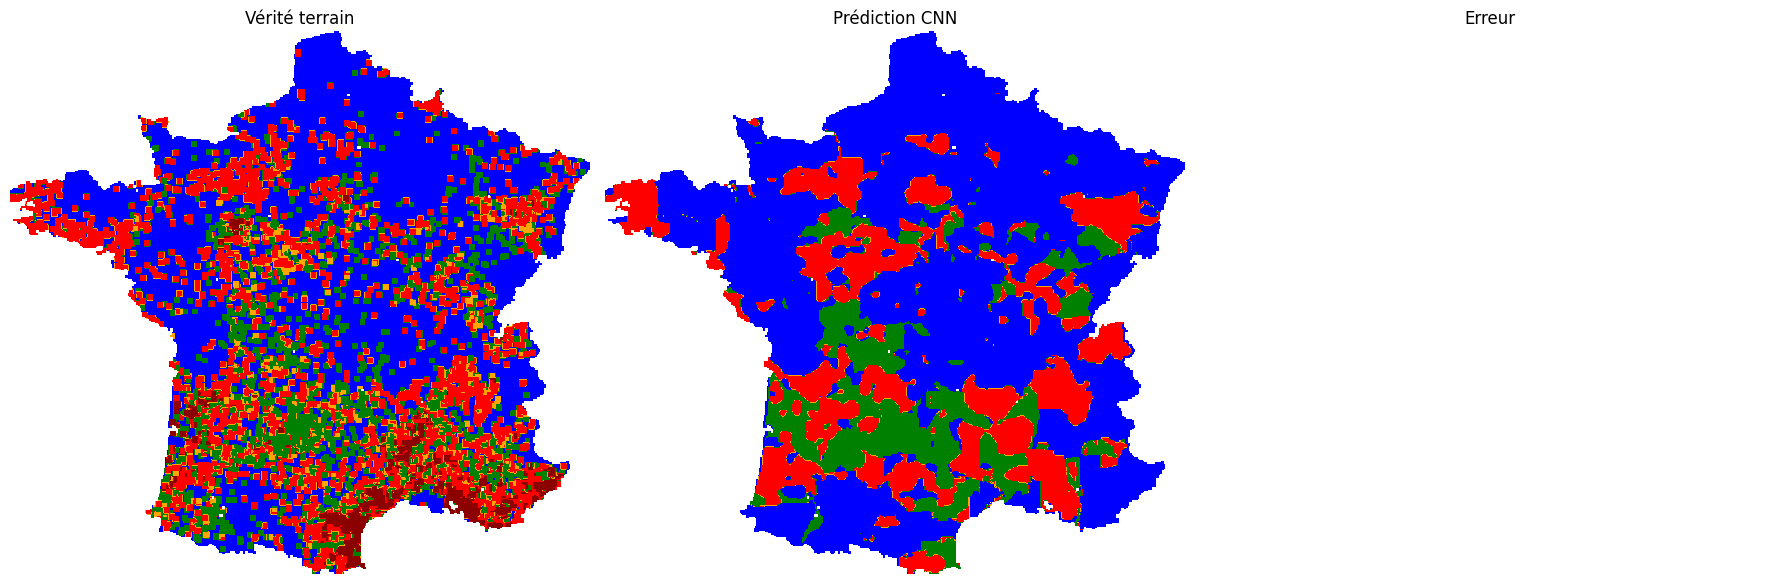

In [568]:
model_classic, X_train_classic, y_train_classic, X_test_classic, y_test_classic, y_pred_classic, features = train_evaluate_cnn_from_images(
    features_array,
    np.copy(targets),
    device=torch.device('cuda'),
    class_colors=['blue', 'green', 'orange', 'red', 'darkred'],
    undersample_ratio=0.5
)

Epoch 01: val acc = 0.415
Epoch 02: val acc = 0.415
Epoch 03: val acc = 0.428
Epoch 04: val acc = 0.422
Epoch 05: val acc = 0.399
Epoch 06: val acc = 0.394
Epoch 07: val acc = 0.404
Epoch 08: val acc = 0.384
Epoch 09: val acc = 0.402
Epoch 10: val acc = 0.384
Epoch 11: val acc = 0.396
Epoch 12: val acc = 0.401
Epoch 13: val acc = 0.385
Epoch 14: val acc = 0.385
Epoch 15: val acc = 0.403
Epoch 16: val acc = 0.413
Epoch 17: val acc = 0.389
Epoch 18: val acc = 0.382
Epoch 19: val acc = 0.383
Epoch 20: val acc = 0.369

📊 Classification Report (test):
              precision    recall  f1-score   support

           0       0.57      0.74      0.64     11299
           1       0.15      0.02      0.04      3307
           2       0.00      0.00      0.00       766
           3       0.22      0.22      0.22      4445
           4       0.00      0.00      0.00       124

    accuracy                           0.47     19941
   macro avg       0.19      0.20      0.18     19941
weighted avg 

/home/caron/Bureau/.conda/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/caron/Bureau/.conda/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/caron/Bureau/.conda/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


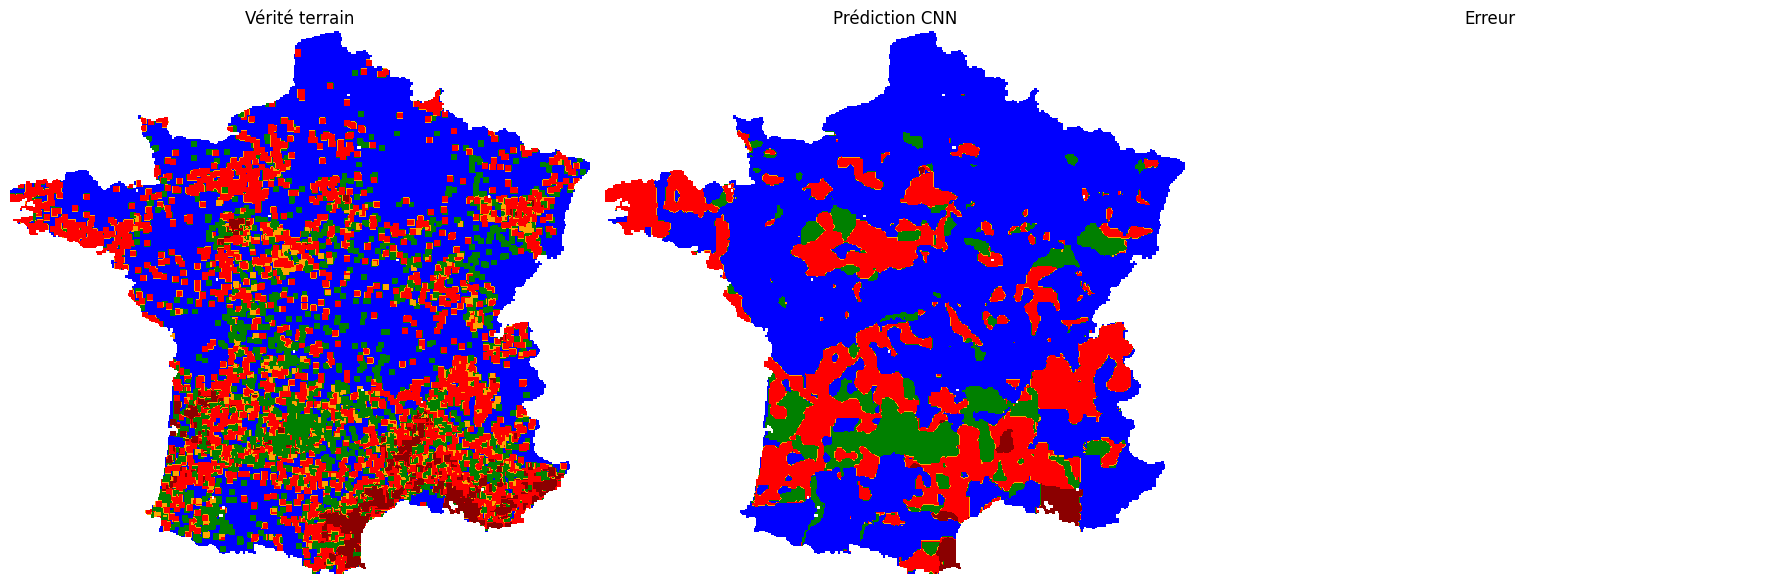

In [569]:
model_classic, X_train_classic, y_train_classic, X_test_classic, y_test_classic, y_pred_classic, features = train_evaluate_cnn_from_images(
    features_array,
    np.copy(targets),
    device=torch.device('cuda'),
    class_colors=['blue', 'green', 'orange', 'red', 'darkred'],
    mode_train='departement',
    departement_mask=departement_mask,
    undersample_ratio=0.5
)

Epoch 01: val acc = 0.474
Epoch 02: val acc = 0.471
Epoch 03: val acc = 0.475
Epoch 04: val acc = 0.475
Epoch 05: val acc = 0.466
Epoch 06: val acc = 0.493
Epoch 07: val acc = 0.486
Epoch 08: val acc = 0.482
Epoch 09: val acc = 0.467
Epoch 10: val acc = 0.458
Epoch 11: val acc = 0.474
Epoch 12: val acc = 0.486
Epoch 13: val acc = 0.458
Epoch 14: val acc = 0.456
Epoch 15: val acc = 0.477
Epoch 16: val acc = 0.459
Epoch 17: val acc = 0.455
Epoch 18: val acc = 0.463
Epoch 19: val acc = 0.436
Epoch 20: val acc = 0.446

📊 Classification Report (test):
              precision    recall  f1-score   support

           0       0.50      0.72      0.59      9198
           1       0.18      0.09      0.12      3252
           2       0.00      0.00      0.00       541
           3       0.27      0.19      0.22      4966
           4       0.05      0.02      0.03       684

    accuracy                           0.42     18641
   macro avg       0.20      0.20      0.19     18641
weighted avg 

/home/caron/Bureau/.conda/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/caron/Bureau/.conda/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/caron/Bureau/.conda/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


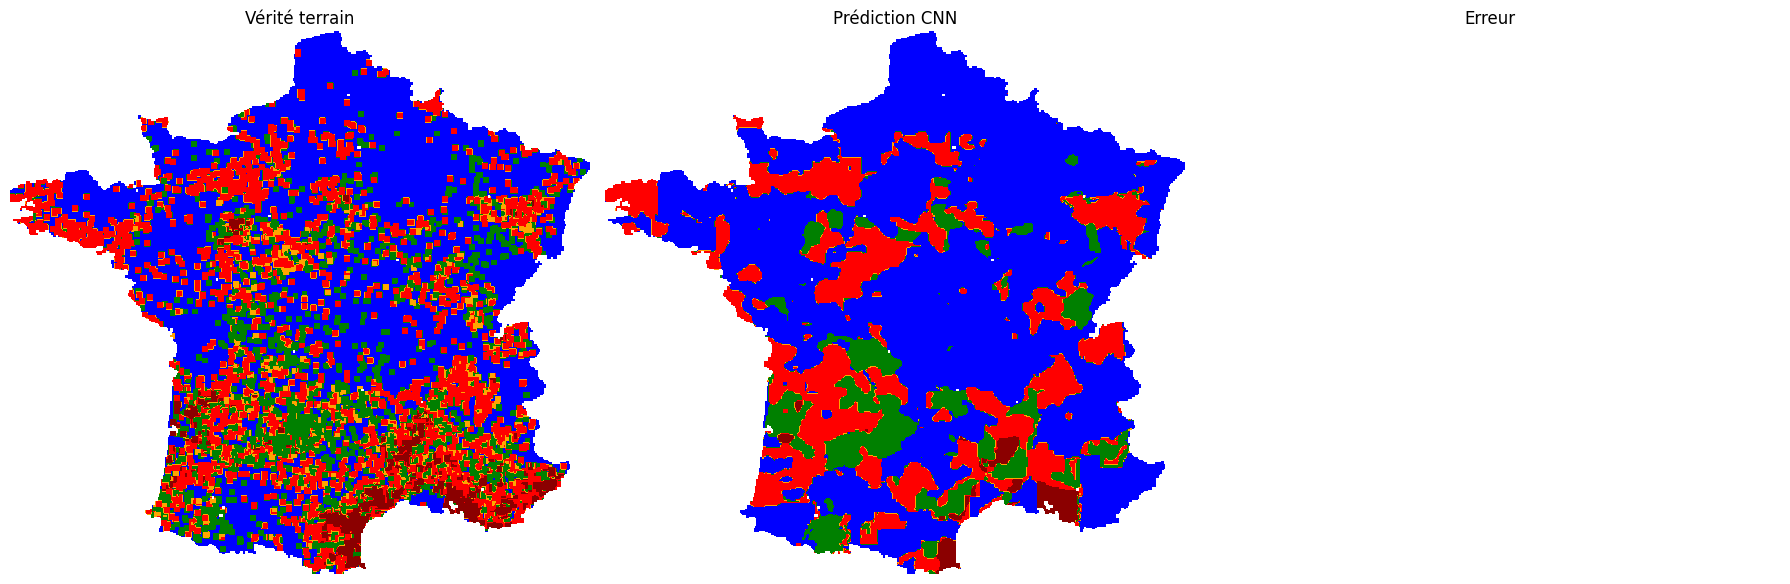

In [570]:
model_classic, X_train_classic, y_train_classic, X_test_classic, y_test_classic, y_pred_classic, features = train_evaluate_cnn_from_images(
    features_array,
    np.copy(targets),
    device=torch.device('cuda'),
    class_colors=['blue', 'green', 'orange', 'red', 'darkred'],
    mode_train='departement',
    departement_mask=image_cluster_mask,
    undersample_ratio=0.5
)